In [2]:
import os
import json
import re
import pandas as pd
from dataclasses import dataclass
from typing import Optional

# ============================================================
# Paths / config
# ============================================================
RESULTS_ROOT = "/mnt/hdd/ttoxopeus/basic_UNet/results"
MODEL_NAME = "UNet_ACDC"  # change if needed
EVAL_MODES = ("pruned", "retrained")

# ============================================================
# Helpers
# ============================================================
def _get_pruned_eval_relpath(eval_mode: str) -> str:
    """Choose which evaluation folder to read for pruned runs."""
    eval_mode = eval_mode.lower().strip()
    if eval_mode in {"retrained", "retrain", "ft", "finetuned"}:
        return os.path.join("retrained_pruned_evaluation", "run_summary.json")
    if eval_mode in {"pruned", "direct", "no_retrain", "noretrain"}:
        return os.path.join("pruned_evaluation", "run_summary.json")
    raise ValueError(f"Unknown eval_mode={eval_mode!r}. Use 'retrained' or 'pruned'.")


def _read_json(path: str) -> dict | None:
    if not os.path.isfile(path):
        return None
    with open(path, "r") as f:
        return json.load(f)


def _extract_threshold(run_name: str) -> float:
    """
    Extract threshold from names like: corr_t92_...
    Returns 0.92 for 't92'. If not found, returns 1.0.
    """
    m = re.search(r"_t(\d+)", run_name)
    if not m:
        return 1.0
    return float(m.group(1)) / 100.0


def _flatten_run_summary(d: dict, run_name: str, run_path: str) -> dict:
    """
    Turns your run_summary.json (new schema) into a single flat row.
    Expands eval.per_class into columns.
    """
    exp = d.get("experiment", {}) or {}
    ev = d.get("eval", {}) or {}
    fg = ev.get("foreground", {}) or {}
    prof = d.get("profile", {}) or {}

    row = {
        "run_name": run_name,
        "run_path": run_path,
        "threshold": _extract_threshold(run_name),
        "stage": d.get("stage"),
        "phase": ev.get("phase"),

        # profile
        "params_m": prof.get("params_m"),
        "flops_g": prof.get("flops_g"),
        "inference_ms": prof.get("inference_ms"),

        # eval
        "vram_peak_mb": ev.get("vram_peak_mb"),
        "mean_dice_fg": fg.get("dice_mean"),
        "std_dice_fg": fg.get("dice_std"),
        "mean_iou_fg": fg.get("iou_mean"),
        "std_iou_fg": fg.get("iou_std"),

        # optional metadata
        "seed": exp.get("seed"),
        "device": exp.get("device"),
        "checkpoint": ev.get("checkpoint"),
    }

    per_class = ev.get("per_class", {}) or {}
    for cls_name, cls_metrics in per_class.items():
        cls_slug = cls_name.lower().replace(" ", "_")
        row[f"{cls_slug}_dice_mean"] = cls_metrics.get("dice_mean")
        row[f"{cls_slug}_dice_std"] = cls_metrics.get("dice_std")
        row[f"{cls_slug}_iou_mean"] = cls_metrics.get("iou_mean")
        row[f"{cls_slug}_iou_std"] = cls_metrics.get("iou_std")

    return row


def load_experiment_eval_df(
    exp_name: str,
    required_substring: str | list[str] | None = None,
    exclude_substrings: str | list[str] | None = None,
    *,
    eval_mode: str,
    baseline_eval_relpath: str = os.path.join("baseline", "evaluation", "run_summary.json"),
    model_name: str = MODEL_NAME,
    results_root: str = RESULTS_ROOT,
) -> pd.DataFrame:
    """
    Returns a DataFrame for one experiment:
    - Row 0 = baseline evaluation
    - Following rows = each pruned run under /pruned/*
    Reads new-schema run_summary.json.

    Filters:
    required_substring: str | list[str] | None
    exclude_substrings: str | list[str] | None
    """

    pruned_eval_relpath = _get_pruned_eval_relpath(eval_mode)
    exp_root = os.path.join(results_root, model_name, exp_name)

    # normalize required
    required_list: list[str] = []
    if isinstance(required_substring, str):
        required_list = [s.strip() for s in required_substring.split(",") if s.strip()]
    elif required_substring:
        required_list = list(required_substring)

    # normalize excludes
    exclude_list: list[str] = []
    if isinstance(exclude_substrings, str):
        exclude_list = [s.strip() for s in exclude_substrings.split(",") if s.strip()]
    elif exclude_substrings:
        exclude_list = list(exclude_substrings)

    # -------- baseline first --------
    baseline_path = os.path.join(exp_root, baseline_eval_relpath)
    baseline_json = _read_json(baseline_path)
    if baseline_json is None:
        raise FileNotFoundError(f"Baseline run_summary.json not found at: {baseline_path}")

    rows = [
        _flatten_run_summary(
            baseline_json,
            run_name="baseline",
            run_path=os.path.dirname(baseline_path),
        )
    ]

    # -------- pruned runs --------
    pruned_dir = os.path.join(exp_root, "pruned")
    if not os.path.isdir(pruned_dir):
        df = pd.DataFrame(rows)
        df["model_size_pct"] = 100.0
        return df

    for run_name in sorted(os.listdir(pruned_dir)):
        run_path = os.path.join(pruned_dir, run_name)
        if not os.path.isdir(run_path):
            continue

        if required_list and not all(req in run_name for req in required_list):
            continue
        if exclude_list and any(excl in run_name for excl in exclude_list):
            continue

        metrics_path = os.path.join(run_path, pruned_eval_relpath)
        d = _read_json(metrics_path)
        if d is None:
            continue

        rows.append(_flatten_run_summary(d, run_name=run_name, run_path=run_path))

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    baseline_params = df.loc[df["run_name"] == "baseline", "params_m"].iloc[0]
    df["model_size_pct"] = 100.0 * df["params_m"] / baseline_params

    is_baseline = df["run_name"].eq("baseline")
    df_pruned = df.loc[~is_baseline].sort_values(
        ["params_m", "mean_dice_fg"], ascending=[False, False]
    )
    df = pd.concat([df.loc[is_baseline], df_pruned], ignore_index=True)

    front = [
        "run_name",
        "threshold",
        "phase",
        "model_size_pct",
        "params_m",
        "flops_g",
        "inference_ms",
        "vram_peak_mb",
        "mean_dice_fg",
        "std_dice_fg",
        "mean_iou_fg",
        "std_iou_fg",
        "seed",
        "device",
        "checkpoint",
        "run_path",
    ]
    df = df[front + [c for c in df.columns if c not in front]]

    return df


def make_encoder_df(df_total, df_deep, df_decoder):
    baseline_run = df_total.iloc[0]["run_name"]
    remove_runs = set(df_deep["run_name"]) | set(df_decoder["run_name"])
    remove_runs.discard(baseline_run)
    return df_total[~df_total["run_name"].isin(remove_runs)].copy()


@dataclass
class PruningGroup:
    uniform: pd.DataFrame
    encoder: pd.DataFrame
    deep: pd.DataFrame
    decoder: pd.DataFrame
    total: Optional[pd.DataFrame] = None


def load_all_dfs_for_mode(eval_mode: str):
    # L1
    df_uniform_l1_acdc = load_experiment_eval_df("exp67_uniform_l1_acdc", eval_mode=eval_mode)
    df_partial_l1_acdc_encoder = load_experiment_eval_df("exp68_partial_l1_acdc", exclude_substrings="l1_norm_0_0_0", eval_mode=eval_mode)
    df_partial_l1_acdc_deep = load_experiment_eval_df("exp68_partial_l1_acdc", exclude_substrings="0_0_0_0_0_0", eval_mode=eval_mode)
    df_partial_l1_acdc_decoder = load_experiment_eval_df("exp68_partial_l1_acdc", required_substring="l1_norm_0_0_0_0_0_0", eval_mode=eval_mode)

    df_uniform_l1_mm = load_experiment_eval_df("exp74_uniform_l1_MM", eval_mode=eval_mode)
    df_partial_l1_mm_encoder = load_experiment_eval_df("exp75_partial_l1_MM", exclude_substrings="l1_norm_0_0_0", eval_mode=eval_mode)
    df_partial_l1_mm_deep = load_experiment_eval_df("exp75_partial_l1_MM", exclude_substrings="0_0_0_0_0_0", eval_mode=eval_mode)
    df_partial_l1_mm_decoder = load_experiment_eval_df("exp75_partial_l1_MM", required_substring="l1_norm_0_0_0_0_0_0", eval_mode=eval_mode)

    # STONE (uniform L1 only)
    df_uniform_l1_stone = load_experiment_eval_df("exp85_stone_l1", eval_mode=eval_mode)

    # Correlation
    df_uniform_corr_acdc = load_experiment_eval_df("exp70_uniform_corr_acdc", eval_mode=eval_mode)
    df_partial_corr_acdc_total = load_experiment_eval_df("exp73_partial_corr_acdc", eval_mode=eval_mode)
    df_partial_corr_acdc_deep = load_experiment_eval_df("exp73_partial_corr_acdc", exclude_substrings="0_0_0_0_0_0", eval_mode=eval_mode)
    df_partial_corr_acdc_decoder = load_experiment_eval_df("exp73_partial_corr_acdc", required_substring="0_0_0_0_0_0_", eval_mode=eval_mode)
    df_partial_corr_acdc_encoder = make_encoder_df(
        df_partial_corr_acdc_total,
        df_partial_corr_acdc_deep,
        df_partial_corr_acdc_decoder,
    )

    df_uniform_corr_mm = load_experiment_eval_df("exp76_uniform_corr_MM", eval_mode=eval_mode)
    df_partial_corr_mm_total = load_experiment_eval_df("exp77_partial_corr_MM", eval_mode=eval_mode)
    df_partial_corr_mm_deep = load_experiment_eval_df("exp77_partial_corr_MM", exclude_substrings="0_0_0_0_0_0", eval_mode=eval_mode)
    df_partial_corr_mm_decoder = load_experiment_eval_df("exp77_partial_corr_MM", required_substring="0_0_0_0_0_0_", eval_mode=eval_mode)
    df_partial_corr_mm_encoder = make_encoder_df(
        df_partial_corr_mm_total,
        df_partial_corr_mm_deep,
        df_partial_corr_mm_decoder,
    )

    # Criteria comparisons
    df_l1_norm = load_experiment_eval_df("exp81_compare_importance", required_substring="l1_norm", eval_mode=eval_mode)
    df_l2_norm = load_experiment_eval_df("exp81_compare_importance", required_substring="l2_norm", eval_mode=eval_mode)
    df_pearson = load_experiment_eval_df("exp82_compare_redundancy", required_substring="corr", eval_mode=eval_mode)
    df_cosine = load_experiment_eval_df("exp82_compare_redundancy", required_substring="cos", eval_mode=eval_mode)

    dfs = {
        "acdc": {
            "l1": PruningGroup(
                uniform=df_uniform_l1_acdc,
                encoder=df_partial_l1_acdc_encoder,
                deep=df_partial_l1_acdc_deep,
                decoder=df_partial_l1_acdc_decoder,
            ),
            "corr": PruningGroup(
                uniform=df_uniform_corr_acdc,
                encoder=df_partial_corr_acdc_encoder,
                deep=df_partial_corr_acdc_deep,
                decoder=df_partial_corr_acdc_decoder,
                total=df_partial_corr_acdc_total,
            ),
        },
        "mm": {
            "l1": PruningGroup(
                uniform=df_uniform_l1_mm,
                encoder=df_partial_l1_mm_encoder,
                deep=df_partial_l1_mm_deep,
                decoder=df_partial_l1_mm_decoder,
            ),
            "corr": PruningGroup(
                uniform=df_uniform_corr_mm,
                encoder=df_partial_corr_mm_encoder,
                deep=df_partial_corr_mm_deep,
                decoder=df_partial_corr_mm_decoder,
                total=df_partial_corr_mm_total,
            ),
        },
        "stone": {
            "l1": PruningGroup(
                uniform=df_uniform_l1_stone,
                encoder=pd.DataFrame(),
                deep=pd.DataFrame(),
                decoder=pd.DataFrame(),
            ),
            "corr": PruningGroup(
                uniform=pd.DataFrame(),
                encoder=pd.DataFrame(),
                deep=pd.DataFrame(),
                decoder=pd.DataFrame(),
            ),
        },
    }

    criteria_dfs = {
        "l1_norm": df_l1_norm,
        "l2_norm": df_l2_norm,
        "pearson": df_pearson,
        "cosine": df_cosine,
    }

    return dfs, criteria_dfs


# ============================================================
# Load both modes once
# ============================================================
dfs_by_eval_mode = {}
criteria_dfs_by_eval_mode = {}

for _mode in EVAL_MODES:
    _dfs, _criteria = load_all_dfs_for_mode(_mode)
    dfs_by_eval_mode[_mode] = _dfs
    criteria_dfs_by_eval_mode[_mode] = _criteria

# Backward-compatible aliases used by existing plot cells.
dfs_untrained = dfs_by_eval_mode["pruned"]
dfs_trained = dfs_by_eval_mode["retrained"]
criteria_dfs_untrained = criteria_dfs_by_eval_mode["pruned"]
criteria_dfs_trained = criteria_dfs_by_eval_mode["retrained"]

pd.set_option("display.max_rows", None)

print("[OK] Loaded both eval modes:", ", ".join(dfs_by_eval_mode.keys()))

display(dfs_trained["stone"]["l1"].uniform)



[OK] Loaded both eval modes: pruned, retrained


,run_name,threshold,phase,model_size_pct,params_m,flops_g,inference_ms,vram_peak_mb,mean_dice_fg,std_dice_fg,...,rv_iou_mean,rv_iou_std,myocardium_dice_mean,myocardium_dice_std,myocardium_iou_mean,myocardium_iou_std,lv_dice_mean,lv_dice_std,lv_iou_mean,lv_iou_std
0,baseline,1.0,baseline_evaluation,100.000000,43.886340,54.440493,2.461300,793.915527,0.857889,0.166494,...,0.790897,0.273912,0.836082,0.213687,0.755866,0.207474,0.894652,0.215042,0.851211,0.217615
1,l1_norm_0_0_0_0_0_0_0_0_0_0_0,1.0,retrained_pruned_evaluation,100.000000,43.886340,54.440493,2.514038,281.270996,0.731204,0.282309,...,0.648455,0.343788,0.716657,0.255016,0.607185,0.248689,0.763387,0.328091,0.703046,0.326211
2,l1_norm_5_5_5_5_5_5_5_5_5_5_5,1.0,retrained_pruned_evaluation,90.458345,39.698857,49.399789,3.592820,278.512207,0.721187,0.301983,...,0.620989,0.366586,0.729505,0.274964,0.631662,0.268788,0.752783,0.347701,0.699164,0.345831
3,l1_norm_10_10_10_10_10_10_10_10_10_10_10,1.0,retrained_pruned_evaluation,81.127036,35.603687,44.456122,3.426518,254.225586,0.693634,0.279807,...,0.545060,0.359789,0.705260,0.252024,0.591649,0.244768,0.757006,0.322454,0.690776,0.318476
4,l1_norm_15_15_15_15_15_15_15_15_15_15_15,1.0,retrained_pruned_evaluation,72.478569,31.808191,39.651868,3.193951,235.223633,0.703228,0.292460,...,0.550155,0.343022,0.726425,0.260681,0.623083,0.260516,0.752210,0.347419,0.698245,0.345592
5,l1_norm_20_20_20_20_20_20_20_20_20_20_20,1.0,retrained_pruned_evaluation,64.152584,28.154221,35.236682,3.014774,202.862793,0.666056,0.314641,...,0.547106,0.360227,0.672286,0.298895,0.568879,0.281267,0.706055,0.369794,0.646945,0.357164
6,l1_norm_25_25_25_25_25_25_25_25_25_25_25,1.0,retrained_pruned_evaluation,56.257770,24.689476,30.657085,1.963310,181.378906,0.692165,0.297269,...,0.584782,0.372329,0.689766,0.267974,0.577884,0.255052,0.738461,0.342020,0.675416,0.335138
7,l1_norm_30_30_30_30_30_30_30_30_30_30_30,1.0,retrained_pruned_evaluation,49.160830,21.574889,26.905023,2.673140,177.595215,0.712928,0.289647,...,0.619669,0.335444,0.694509,0.275246,0.586559,0.261996,0.749923,0.337070,0.689126,0.333992
8,l1_norm_35_35_35_35_35_35_35_35_35_35_35,1.0,retrained_pruned_evaluation,42.348537,18.585223,23.290910,2.519641,158.668457,0.717450,0.275600,...,0.603453,0.365602,0.722648,0.232450,0.607942,0.235297,0.762804,0.309345,0.693939,0.313162
9,l1_norm_40_40_40_40_40_40_40_40_40_40_40,1.0,retrained_pruned_evaluation,36.167644,15.872655,19.851583,2.051916,121.418945,0.706371,0.293307,...,0.598414,0.356158,0.702676,0.272430,0.596560,0.264964,0.748959,0.339381,0.688971,0.335936


In [3]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt

_cwd = Path.cwd().resolve()
_project_root = next((p for p in (_cwd, *_cwd.parents) if (p / "src").exists()), None)
if _project_root is not None and str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

from src.analysis.plot_style import PUB_COLORS, apply_publication_style, despine

apply_publication_style()

def plot_pruning_locations(
    dfs,
    *,
    dataset: str,
    method: str,
    title: str | None = None,
    save_path: str | None = None,
):
    group = dfs[dataset][method]

    df_uniform = group.uniform
    df_encoder = group.encoder
    df_deep = group.deep
    df_decoder = group.decoder

    fig, ax = plt.subplots(figsize=(10, 6))

    # -------------------------------
    # Baseline (first row in uniform)
    # -------------------------------
    baseline_dice = df_uniform.iloc[0]["mean_dice_fg"]

    ax.axhline(
        baseline_dice,
        linestyle="--",
        linewidth=1.2,
        color="black",
        alpha=0.6,
        label="Baseline (unpruned)",
    )

    lines = [
        (df_uniform, "Uniform", "o", "-", PUB_COLORS["l1"]),
        (df_encoder, "Encoder only", "s", "--", PUB_COLORS["neutral"]),
        (df_deep, "Deep layers only", "^", "-.", PUB_COLORS["good"]),
        (df_decoder, "Decoder only", "D", ":", PUB_COLORS["warn"]),
    ]

    for df, label, marker, linestyle, color in lines:
        df_plot = df.iloc[1:]  # skip baseline point; keep only pruned runs
        ax.plot(
            df_plot["model_size_pct"],
            df_plot["mean_dice_fg"],
            label=label,
            marker=marker,
            linestyle=linestyle,
            linewidth=1.6,
            markersize=10,
            markeredgecolor="white",
            markeredgewidth=0.6,
            color=color,
        )

    ax.set_xlabel("Remaining model size (%)")
    ax.set_ylabel("Mean Dice (foreground)")

    if title is None:
        title = f"{dataset.upper()} — {method.upper()} pruning by region"
    ax.set_title(title, fontsize=10, pad=6)

    # Flip x-axis: 100 -> 0
    ax.set_xlim(max(df_uniform["model_size_pct"]), 0)
    ax.set_ylim(0.0, 1.0)

    despine(ax)
    ax.legend(frameon=False, fontsize=8, loc="lower left")

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    else:
        plt.show()

    plt.close(fig)

# plot_pruning_locations(
#     dfs_trained,
#     dataset="mm",
#     method="corr",
#     title="M&M: Similar-Feature Map Pruning by Region (No Retraining)",
#     # save_path="figures/results/mm_corr_pruning_locations.pdf",
# )


In [4]:
# import matplotlib.pyplot as plt
# import pandas as pd
# from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# from src.analysis.plot_style import PUB_COLORS, apply_publication_style, despine

# apply_publication_style()

# def plot_experiment_dfs(
#     dfs_by_label,
#     *,
#     include_baseline_point: bool = True,
#     gap_labels: tuple[str, str] | None = None,
#     gap_label: str = "Difference (A - B)",
#     zoom_region: tuple[float, float, float, float] | None = None,  # (x_min, x_max, y_min, y_max)
#     title=None,
#     save_path=None,
# ):
#     """
#     Plot multiple experiment dataframes in one figure.

#     Pass: {"label": df, ...}

#     Optional:
#     - gap_labels=("A","B") to plot Dice_A - Dice_B
#     - zoom_region=(x_min, x_max, y_min, y_max) to add inset zoom
#     """

#     fig, ax = plt.subplots(figsize=(10, 6))
#     x_max = 0.0
#     y_min, y_max = 0.0, 1.0

#     palette = [
#         PUB_COLORS["l1"],
#         PUB_COLORS["corr"],
#         PUB_COLORS["neutral"],
#         PUB_COLORS["good"],
#         PUB_COLORS["warn"],
#     ]
#     markers = ["o", "s", "^", "D", "P", "X", "v", "*"]
#     linestyles = ["-", "--", "-.", ":"]

#     plotted_lines = []

#     # --------------------------------------------------
#     # Plot main curves
#     # --------------------------------------------------
#     for i, (label, df) in enumerate(dfs_by_label.items()):
#         if df is None or df.empty:
#             continue

#         baseline_dice = df.iloc[0]["mean_dice_fg"]

#         if include_baseline_point:
#             df_plot = df[["model_size_pct", "mean_dice_fg"]].copy()
#         else:
#             df_plot = df.iloc[1:][["model_size_pct", "mean_dice_fg"]].copy()

#         df_plot = df_plot.sort_values("model_size_pct", ascending=False)

#         color = palette[i % len(palette)]
#         marker = markers[i % len(markers)]
#         linestyle = linestyles[i % len(linestyles)]

#         line = ax.plot(
#             df_plot["model_size_pct"],
#             df_plot["mean_dice_fg"],
#             marker=marker,
#             linestyle=linestyle,
#             linewidth=1.6,
#             markersize=6,
#             color=color,
#             label=label,
#         )

#         plotted_lines.append((df_plot, color, marker, linestyle))

#         ax.axhline(
#             baseline_dice,
#             linestyle="--",
#             linewidth=1.0,
#             color=color,
#             alpha=0.4,
#         )

#         x_max = max(x_max, float(df["model_size_pct"].max()))

#     # --------------------------------------------------
#     # Optional gap plotting
#     # --------------------------------------------------
#     if gap_labels is not None:
#         a_label, b_label = gap_labels
#         df_a = dfs_by_label.get(a_label)
#         df_b = dfs_by_label.get(b_label)

#         if df_a is None or df_b is None:
#             raise ValueError("gap_labels refer to missing dfs.")

#         a = df_a.iloc[1:][["model_size_pct", "mean_dice_fg"]].copy()
#         b = df_b.iloc[1:][["model_size_pct", "mean_dice_fg"]].copy()

#         merged = a.merge(
#             b,
#             on="model_size_pct",
#             how="inner",
#             suffixes=("_a", "_b"),
#         )

#         if not merged.empty:
#             merged["gap"] = (
#                 merged["mean_dice_fg_a"] -
#                 merged["mean_dice_fg_b"]
#             )

#             ax.plot(
#                 merged["model_size_pct"],
#                 merged["gap"],
#                 marker="x",
#                 linestyle="--",
#                 linewidth=1.6,
#                 markersize=6,
#                 label=gap_label,
#             )

#             y_min = min(y_min, merged["gap"].min())
#             y_max = max(y_max, merged["gap"].max())

#     # --------------------------------------------------
#     # Axes styling
#     # --------------------------------------------------
#     x_pad = 0.02 * x_max if x_max > 0 else 1.0
#     ax.set_xlim(x_max + x_pad, 0 - x_pad)

#     y_pad = 0.05 * (y_max - y_min if y_max > y_min else 1.0)
#     ax.set_ylim(y_min - y_pad, y_max + y_pad)

#     ax.set_xlabel("Remaining model size (%)")
#     ax.set_ylabel("Mean Dice (foreground)")

#     if title is not None:
#         ax.set_title(title, fontsize=10, pad=6)

#     despine(ax)
#     ax.legend(frameon=False, fontsize=8, loc="lower left")

#     # --------------------------------------------------
#     # Optional inset zoom
#     # --------------------------------------------------
#     if zoom_region is not None:
#         x_min_z, x_max_z, y_min_z, y_max_z = zoom_region

#         axins = inset_axes(
#             ax,
#             width="38%",
#             height="38%",
#             loc="lower right",
#             bbox_to_anchor=(-0.08, 0.08, 1, 1),  # shift left & up
#             bbox_transform=ax.transAxes,
#             borderpad=1.2,
#         )
#         for df_plot, color, marker, linestyle in plotted_lines:
#             axins.plot(
#                 df_plot["model_size_pct"],
#                 df_plot["mean_dice_fg"],
#                 marker=marker,
#                 linestyle=linestyle,
#                 linewidth=1.4,
#                 markersize=4,
#                 color=color,
#             )

#         axins.set_xlim(x_max_z, x_min_z)
#         axins.set_ylim(y_min_z, y_max_z)
#         axins.set_title("Zoomed critical regime", fontsize=7, pad=2)

#         axins.grid(True, alpha=0.25, linewidth=0.4)

#     fig.tight_layout()

#     if save_path is not None:
#         fig.savefig(save_path, dpi=300, bbox_inches="tight")
#     else:
#         plt.show()

#     plt.close(fig)


# # --------------------------------------------------
# # Example call with zoom
# # --------------------------------------------------
# plot_experiment_dfs(
#     {
#         "ACDC — L1": dfs_trained["acdc"]["l1"].uniform,
#         "ACDC — Correlation": dfs_trained["acdc"]["corr"].uniform,
#         "M&M — L1": dfs_trained["mm"]["l1"].uniform,
#         "M&M — Correlation": dfs_trained["mm"]["corr"].uniform,
#     },
#     include_baseline_point=True,
#     zoom_region=(-0.5, 10, 0.6, 0.9),  # <- zoom into critical region
#     title="Uniform Pruning (With Retraining): Method and Domain Comparison",
# )


In [5]:
# Dice plot for criteria_dfs (same style as cell 2)

# if "criteria_dfs" not in globals():
#     raise NameError("criteria_dfs is not defined. Create it first, then run this cell.")


def _flatten_criteria_dfs(obj):
    """
    Accepts either:
      - {label: DataFrame}
      - {group: {label: DataFrame}}
    and returns {flat_label: DataFrame}.
    """
    flat = {}

    if not isinstance(obj, dict):
        raise TypeError("criteria_dfs must be a dict.")

    for k, v in obj.items():
        print(k, type(v))
        if isinstance(v, pd.DataFrame):
            flat[str(k)] = v
        elif isinstance(v, dict):
            for k2, v2 in v.items():
                if isinstance(v2, pd.DataFrame):
                    flat[f"{k} — {k2}"] = v2

    if not flat:
        raise ValueError("No DataFrames found inside criteria_dfs.")

    return flat


criteria_plot_dfs_trained = _flatten_criteria_dfs(criteria_dfs_trained)
criteria_plot_dfs_untrained = _flatten_criteria_dfs(criteria_dfs_untrained)

combined_criteria_plot_dfs = {
    **{f"{k} (trained)": v for k, v in criteria_plot_dfs_trained.items()},
    **{f"{k} (untrained)": v for k, v in criteria_plot_dfs_untrained.items()},
}

# plot_experiment_dfs(
#     combined_criteria_plot_dfs,
#     include_baseline_point=True,
#     title="Criteria Comparison: Dice vs Remaining Model Size",
# )



l1_norm <class 'pandas.core.frame.DataFrame'>
l2_norm <class 'pandas.core.frame.DataFrame'>
pearson <class 'pandas.core.frame.DataFrame'>
cosine <class 'pandas.core.frame.DataFrame'>
l1_norm <class 'pandas.core.frame.DataFrame'>
l2_norm <class 'pandas.core.frame.DataFrame'>
pearson <class 'pandas.core.frame.DataFrame'>
cosine <class 'pandas.core.frame.DataFrame'>


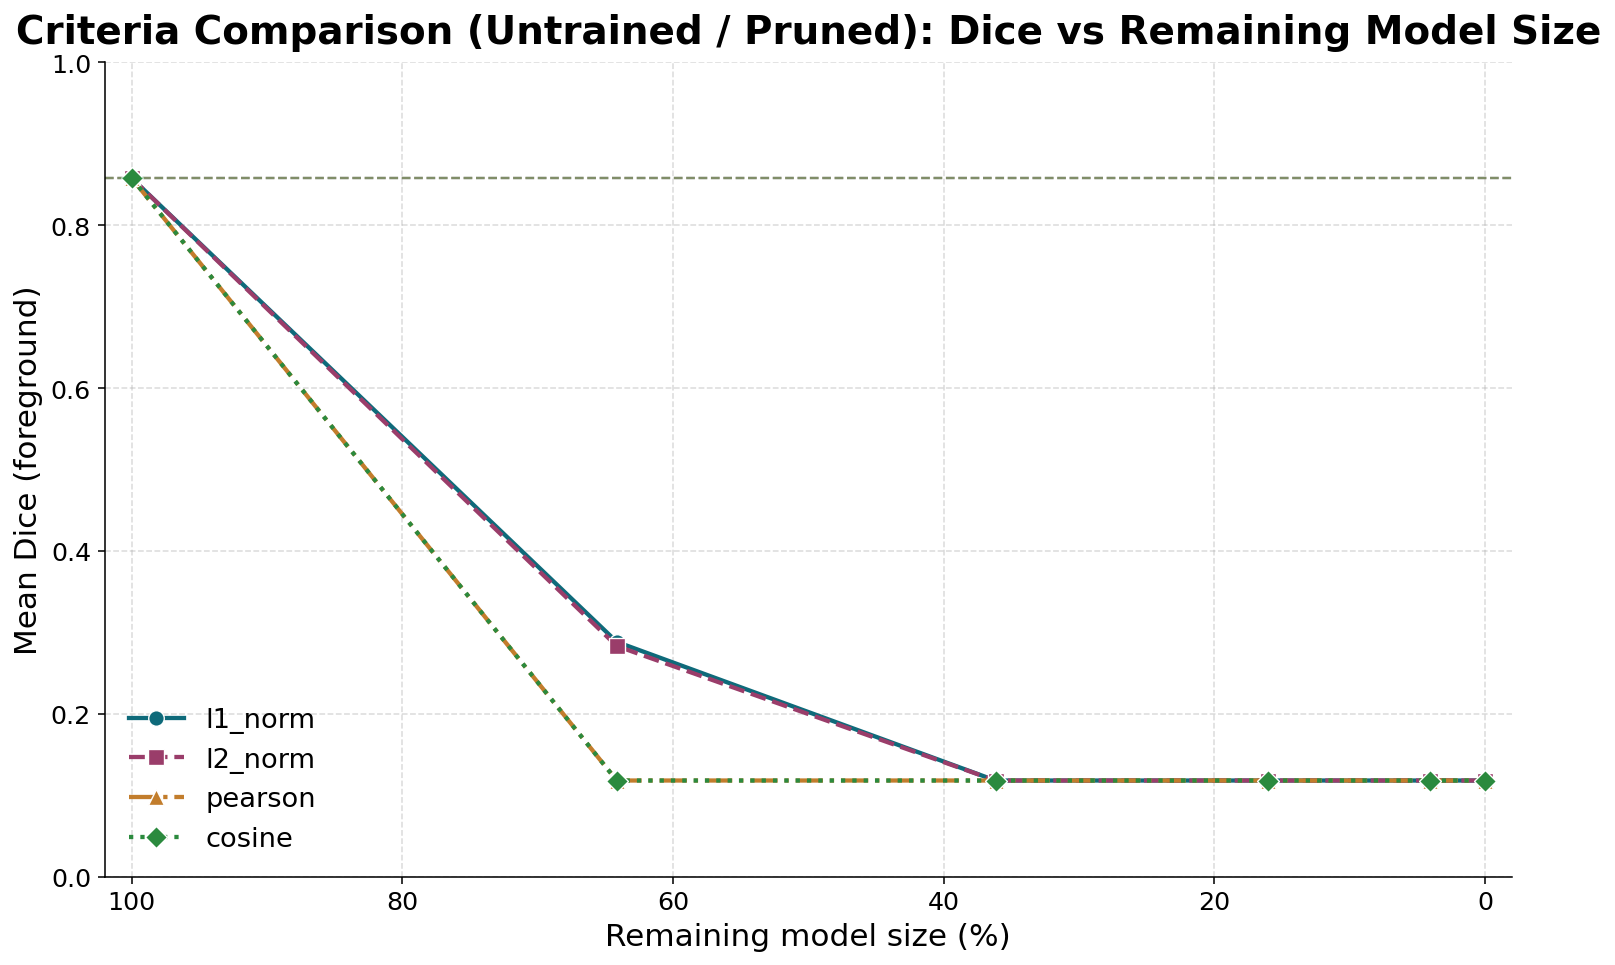

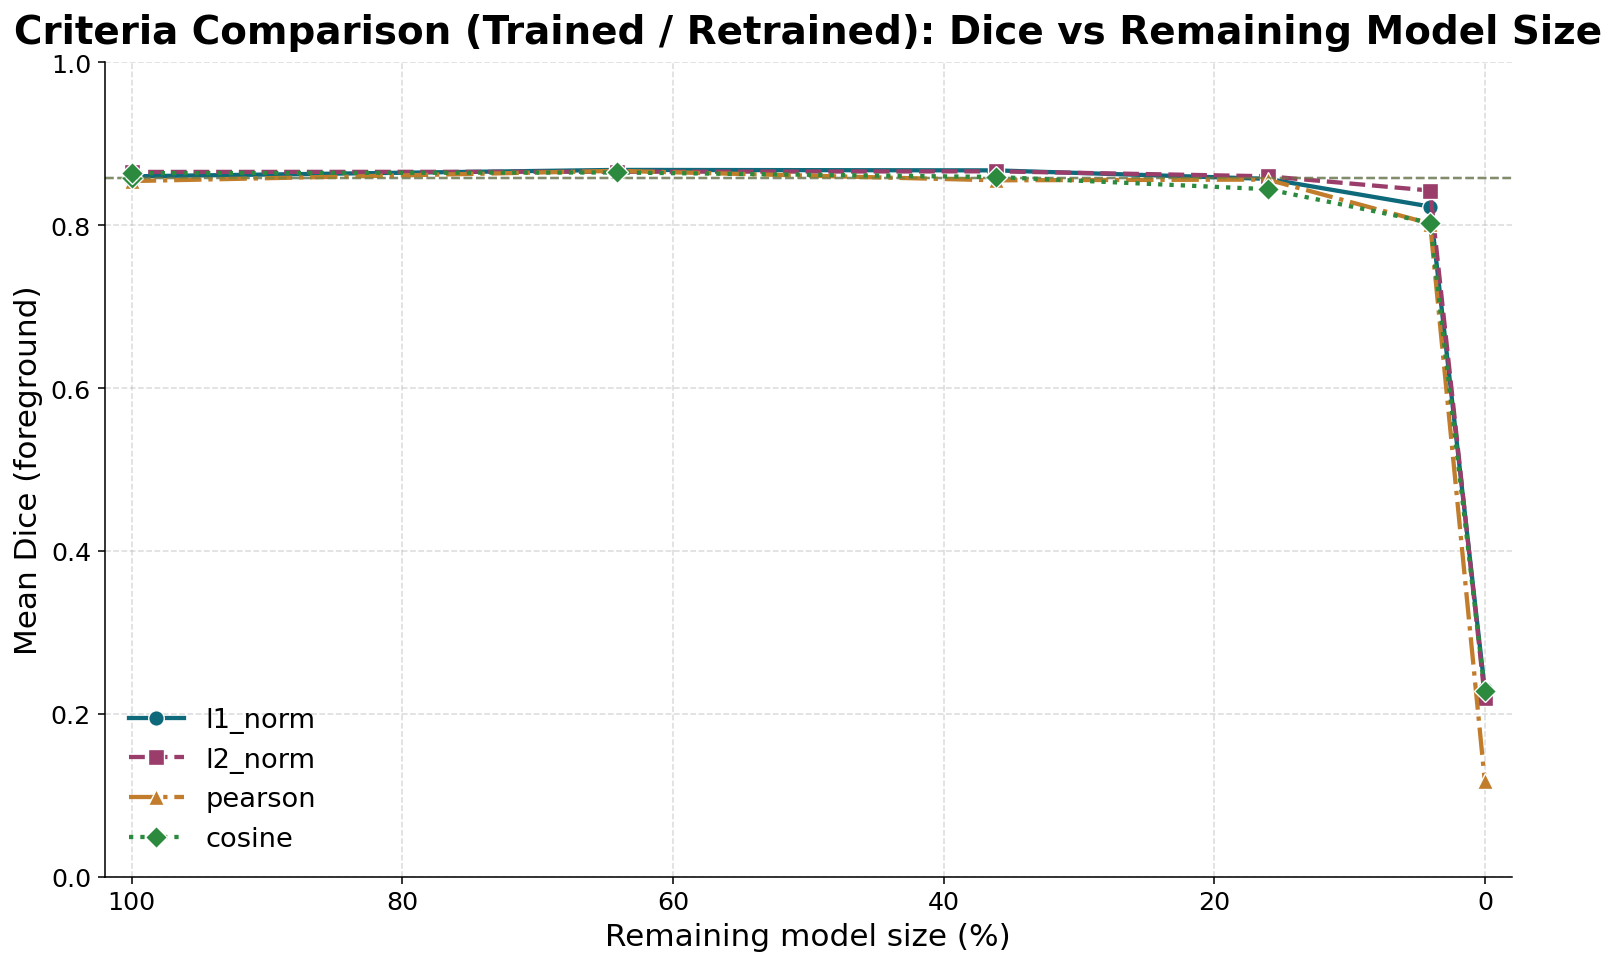

In [6]:
# Criteria plots: separate figures for untrained (pruned) and trained (retrained)
import matplotlib.pyplot as plt
import pandas as pd

apply_publication_style()




def _flatten_criteria_dfs(obj):
    flat = {}
    if not isinstance(obj, dict):
        raise TypeError("criteria_dfs must be a dict.")
    for k, v in obj.items():
        if isinstance(v, pd.DataFrame):
            flat[str(k)] = v
        elif isinstance(v, dict):
            for k2, v2 in v.items():
                if isinstance(v2, pd.DataFrame):
                    flat[f"{k} — {k2}"] = v2
    if not flat:
        raise ValueError("No DataFrames found inside criteria_dfs.")
    return flat


def plot_experiment_dfs(
    dfs_by_label,
    *,
    include_baseline_point: bool = True,
    title: str | None = None,
    save_path: str | None = None,
    title_fontsize: int = 20,
    axis_fontsize: int = 16,
    tick_fontsize: int = 13,
    legend_fontsize: int = 14,
):
    fig, ax = plt.subplots(figsize=(11, 7))

    palette = [
        PUB_COLORS["l1"],
        PUB_COLORS["corr"],
        PUB_COLORS["neutral"],
        PUB_COLORS["good"],
        PUB_COLORS["warn"],
    ]
    markers = ["o", "s", "^", "D", "P", "X", "v", "*"]
    linestyles = ["-", "--", "-.", ":"]

    x_max = 0.0

    for i, (label, df) in enumerate(dfs_by_label.items()):
        if df is None or df.empty:
            continue

        if include_baseline_point:
            df_plot = df[["model_size_pct", "mean_dice_fg"]].copy()
        else:
            df_plot = df.iloc[1:][["model_size_pct", "mean_dice_fg"]].copy()

        df_plot = df_plot.sort_values("model_size_pct", ascending=False)
        if df_plot.empty:
            continue

        color = palette[i % len(palette)]
        marker = markers[i % len(markers)]
        linestyle = linestyles[i % len(linestyles)]

        ax.plot(
            df_plot["model_size_pct"],
            df_plot["mean_dice_fg"],
            marker=marker,
            linestyle=linestyle,
            linewidth=2.2,
            markersize=8,
            markeredgecolor="white",
            markeredgewidth=0.7,
            color=color,
            label=label,
        )

        baseline_dice = float(df.iloc[0]["mean_dice_fg"])
        ax.axhline(
            baseline_dice,
            linestyle="--",
            linewidth=1.2,
            color=color,
            alpha=0.35,
        )

        x_max = max(x_max, float(df["model_size_pct"].max()))

    x_pad = 0.02 * x_max if x_max > 0 else 1.0
    ax.set_xlim(x_max + x_pad, 0 - x_pad)
    ax.set_ylim(0.0, 1.0)

    ax.set_xlabel("Remaining model size (%)", fontsize=axis_fontsize)
    ax.set_ylabel("Mean Dice (foreground)", fontsize=axis_fontsize)
    if title is not None:
        ax.set_title(title, fontsize=title_fontsize, pad=10)

    ax.tick_params(axis="both", labelsize=tick_fontsize)
    despine(ax)
    ax.legend(frameon=False, fontsize=legend_fontsize, loc="lower left")

    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    else:
        plt.show()
    plt.close(fig)


criteria_plot_dfs_untrained = _flatten_criteria_dfs(criteria_dfs_untrained)
criteria_plot_dfs_trained = _flatten_criteria_dfs(criteria_dfs_trained)

plot_experiment_dfs(
    criteria_plot_dfs_untrained,
    include_baseline_point=True,
    title="Criteria Comparison (Untrained / Pruned): Dice vs Remaining Model Size",
)

plot_experiment_dfs(
    criteria_plot_dfs_trained,
    include_baseline_point=True,
    title="Criteria Comparison (Trained / Retrained): Dice vs Remaining Model Size",
)




In [7]:
# ACDC only: 8-line Dice plot (methods x pruning areas)
import matplotlib.pyplot as plt

apply_publication_style()


def plot_acdc_methods_by_area(
    dfs,
    *,
    include_baseline_point: bool = False,
    title: str = "ACDC: L1 vs Correlation Across Pruning Areas",
    save_path: str | None = None,
):
    fig, ax = plt.subplots(figsize=(10, 6))

    method_groups = {
        "L1": dfs["acdc"]["l1"],
        "Pearson": dfs["acdc"]["corr"],
    }

    # Different line styles per method
    method_linestyle = {
        "L1": "-",
        "Pearson": "--",
    }

    # Different marker styles per pruning area
    area_marker = {
        "uniform": "o",
        "encoder": "s",
        "deep": "^",
        "decoder": "D",
    }

    # Keep area colors consistent across methods
    area_color = {
        "uniform": PUB_COLORS["l1"],
        "encoder": PUB_COLORS["neutral"],
        "deep": PUB_COLORS["good"],
        "decoder": PUB_COLORS["warn"],
    }

    area_label = {
        "uniform": "Uniform",
        "encoder": "Encoder only",
        "deep": "Deep layers only",
        "decoder": "Decoder only",
    }
    area_marker = {
        "uniform": "o",
        "encoder": "s",
        "deep": "^",
        "decoder": "D",
    }

    # One baseline line (from ACDC L1-uniform baseline row)
    baseline_dice = method_groups["L1"].uniform.iloc[0]["mean_dice_fg"]
    ax.axhline(
        baseline_dice,
        linestyle=":",
        linewidth=1.2,
        color="black",
        alpha=0.55,
        label="Baseline (unpruned)",
    )

    x_max = 0.0

    for method_name, group in method_groups.items():
        for area in ["uniform", "encoder", "deep", "decoder"]:
            df = getattr(group, area)
            if df is None or df.empty:
                continue

            if include_baseline_point:
                df_plot = df[["model_size_pct", "mean_dice_fg"]].copy()
            else:
                df_plot = df.iloc[1:][["model_size_pct", "mean_dice_fg"]].copy()

            df_plot = df_plot.sort_values("model_size_pct", ascending=False)
            if df_plot.empty:
                continue

            ax.plot(
                df_plot["model_size_pct"],
                df_plot["mean_dice_fg"],
                linestyle=method_linestyle[method_name],
                # marker=area_marker[area],
                linewidth=1.7,
                # markersize=7,
                # markeredgecolor="white",
                # markeredgewidth=0.6,
                color=area_color[area],
                label=f"{method_name} — {area_label[area]}",
            )

            x_max = max(x_max, float(df["model_size_pct"].max()))

    ax.set_xlabel("Remaining model size (%)")
    ax.set_ylabel("Mean Dice (foreground)")
    ax.set_title(title, fontsize=10, pad=6)

    x_pad = 0.02 * x_max if x_max > 0 else 1.0
    ax.set_xlim(x_max + x_pad, 0 - x_pad)
    ax.set_ylim(0.0, 1.0)

    despine(ax)
    ax.legend(frameon=False, fontsize=8, loc="center right", ncol=2)
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    else:
        plt.show()

    plt.close(fig)


# plot_acdc_methods_by_area(
#     dfs,
#     include_baseline_point=True,
#     title="ACDC (No Retraining): L1-Norm vs Pearson Correlation by Pruning Area",
# )


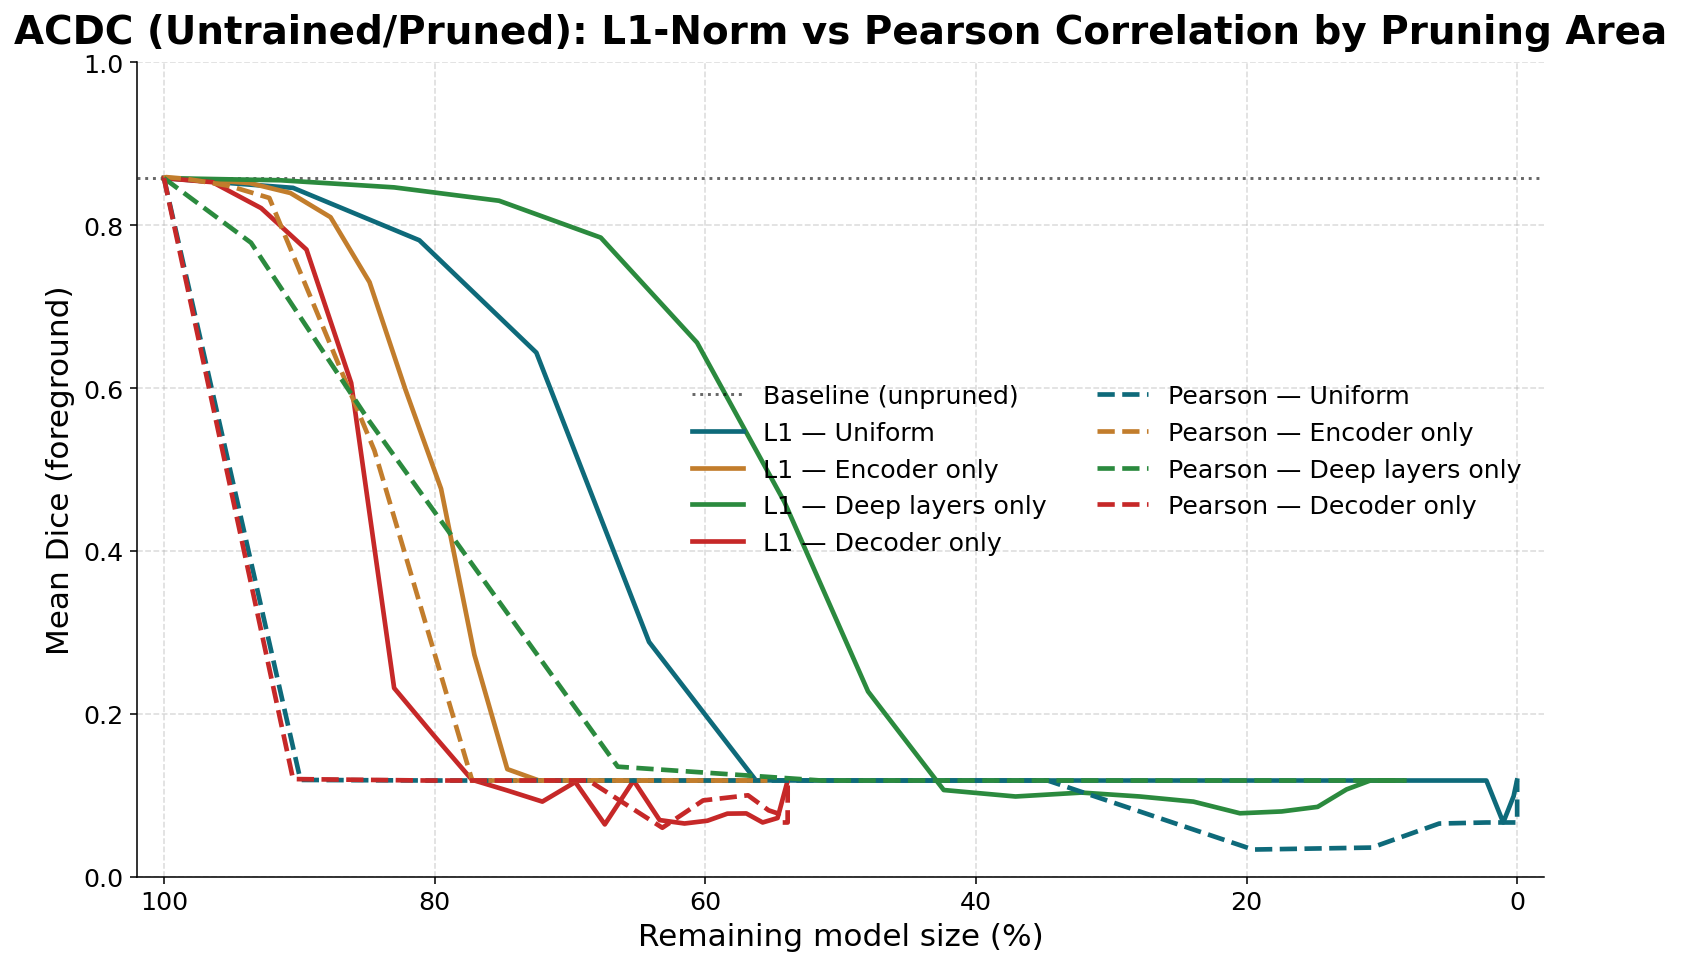

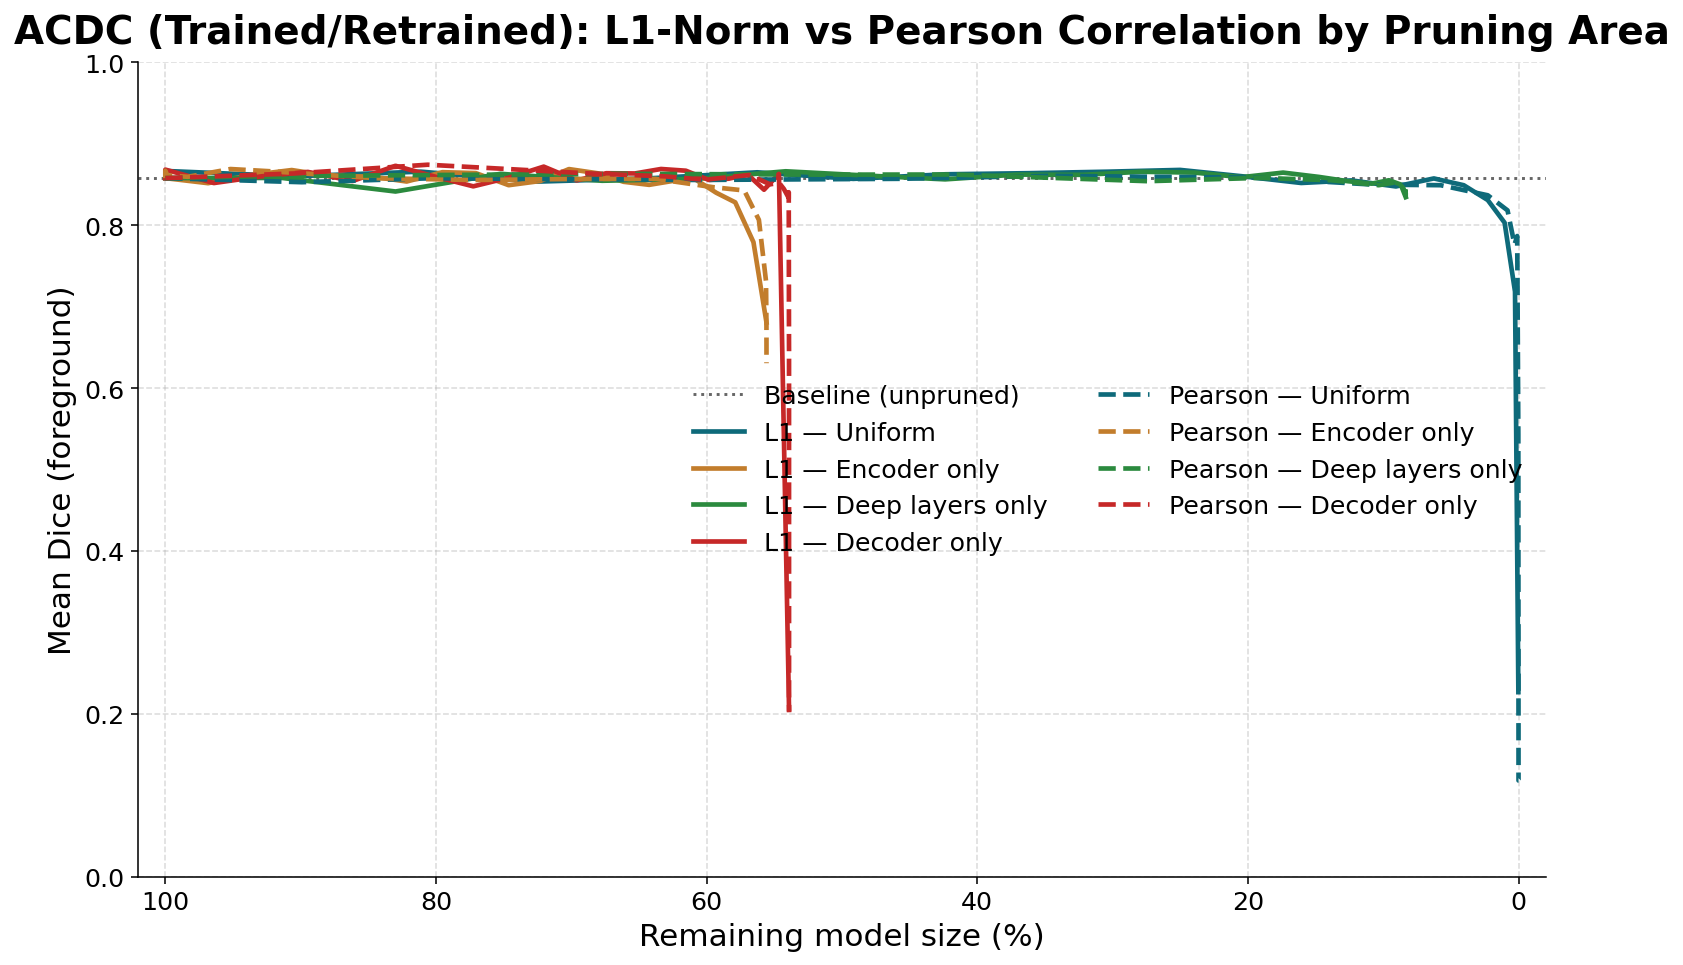

In [8]:
# ACDC only: 8-line Dice plot (methods x pruning areas)
import matplotlib.pyplot as plt

apply_publication_style()


def plot_acdc_methods_by_area(
    dfs,
    *,
    include_baseline_point: bool = False,
    title: str = "ACDC: L1 vs Correlation Across Pruning Areas",
    save_path: str | None = None,
    title_fontsize: int = 20,
    axis_fontsize: int = 16,
    tick_fontsize: int = 13,
    legend_fontsize: int = 13,
):
    fig, ax = plt.subplots(figsize=(11, 7))

    method_groups = {
        "L1": dfs["acdc"]["l1"],
        "Pearson": dfs["acdc"]["corr"],
    }

    method_linestyle = {
        "L1": "-",
        "Pearson": "--",
    }

    area_color = {
        "uniform": PUB_COLORS["l1"],
        "encoder": PUB_COLORS["neutral"],
        "deep": PUB_COLORS["good"],
        "decoder": PUB_COLORS["warn"],
    }

    area_label = {
        "uniform": "Uniform",
        "encoder": "Encoder only",
        "deep": "Deep layers only",
        "decoder": "Decoder only",
    }
    area_marker = {
        "uniform": "o",
        "encoder": "s",
        "deep": "^",
        "decoder": "D",
    }

    baseline_dice = method_groups["L1"].uniform.iloc[0]["mean_dice_fg"]
    ax.axhline(
        baseline_dice,
        linestyle=":",
        linewidth=1.5,
        color="black",
        alpha=0.60,
        label="Baseline (unpruned)",
    )

    x_max = 0.0

    for method_name, group in method_groups.items():
        for area in ["uniform", "encoder", "deep", "decoder"]:
            df = getattr(group, area)
            if df is None or df.empty:
                continue

            if include_baseline_point:
                df_plot = df[["model_size_pct", "mean_dice_fg"]].copy()
            else:
                df_plot = df.iloc[1:][["model_size_pct", "mean_dice_fg"]].copy()

            df_plot = df_plot.sort_values("model_size_pct", ascending=False)
            if df_plot.empty:
                continue

            ax.plot(
                df_plot["model_size_pct"],
                df_plot["mean_dice_fg"],
                linestyle=method_linestyle[method_name],
                linewidth=2.4,
                color=area_color[area],
                label=f"{method_name} — {area_label[area]}",
            )

            x_max = max(x_max, float(df["model_size_pct"].max()))

    ax.set_xlabel("Remaining model size (%)", fontsize=axis_fontsize)
    ax.set_ylabel("Mean Dice (foreground)", fontsize=axis_fontsize)
    ax.set_title(title, fontsize=title_fontsize, pad=10)

    x_pad = 0.02 * x_max if x_max > 0 else 1.0
    ax.set_xlim(x_max + x_pad, 0 - x_pad)
    ax.set_ylim(0.0, 1.0)
    ax.tick_params(axis="both", labelsize=tick_fontsize)

    despine(ax)
    ax.legend(frameon=False, fontsize=legend_fontsize, loc="center right", ncol=2)
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    else:
        plt.show()

    plt.close(fig)


plot_acdc_methods_by_area(
    dfs_untrained,
    include_baseline_point=True,
    title="ACDC (Untrained/Pruned): L1-Norm vs Pearson Correlation by Pruning Area",
)

plot_acdc_methods_by_area(
    dfs_trained,
    include_baseline_point=True,
    title="ACDC (Trained/Retrained): L1-Norm vs Pearson Correlation by Pruning Area",
)



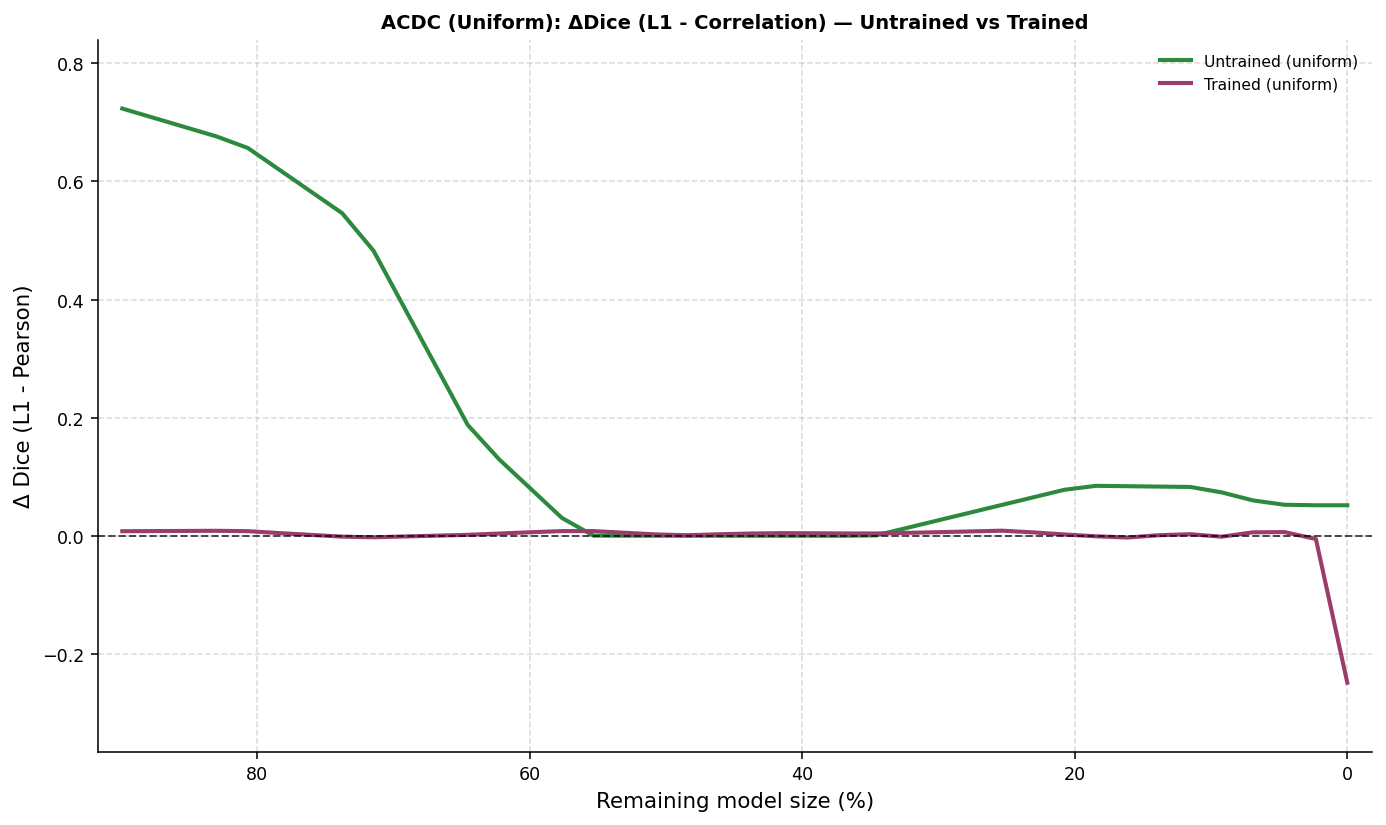

In [9]:
# Aggregated ΔDice comparison: untrained vs trained (two lines)
# Requires: dfs_untrained and dfs_trained to be defined in notebook scope.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

apply_publication_style()


def _aggregate_delta_curve(
    dfs_obj,
    *,
    include_baseline_point=False,
    n_grid=40,
    agg_stat="median",
    min_areas_required=1,
):
    l1_group = dfs_obj["acdc"]["l1"]
    corr_group = dfs_obj["acdc"]["corr"]
    areas = ["uniform"]

    def _prep(df):
        d = df[["model_size_pct", "mean_dice_fg"]].copy() if include_baseline_point else df.iloc[1:][["model_size_pct", "mean_dice_fg"]].copy()
        d = d.dropna().drop_duplicates(subset=["model_size_pct"]).sort_values("model_size_pct")
        if d.empty:
            return None, None
        return d["model_size_pct"].to_numpy(float), d["mean_dice_fg"].to_numpy(float)

    curves = []
    for area in areas:
        x1, y1 = _prep(getattr(l1_group, area))
        x2, y2 = _prep(getattr(corr_group, area))
        if x1 is None or x2 is None or len(x1) < 2 or len(x2) < 2:
            continue
        lo = max(float(np.min(x1)), float(np.min(x2)))
        hi = min(float(np.max(x1)), float(np.max(x2)))
        if hi <= lo:
            continue
        curves.append((area, x1, y1, x2, y2, lo, hi))

    if not curves:
        raise ValueError("No valid overlapping L1/Correlation curves found.")

    gx = np.linspace(min(c[5] for c in curves), max(c[6] for c in curves), int(n_grid))

    cols = []
    for area, x1, y1, x2, y2, lo, hi in curves:
        d = np.interp(gx, x1, y1) - np.interp(gx, x2, y2)
        valid = (gx >= lo) & (gx <= hi)
        d = np.where(valid, d, np.nan)
        cols.append(pd.Series(d, name=area))

    mat = pd.concat(cols, axis=1)
    n_areas = mat.notna().sum(axis=1)
    agg = mat.median(axis=1, skipna=True) if agg_stat == "median" else mat.mean(axis=1, skipna=True)

    out = pd.DataFrame({"model_size_pct": gx, "delta_dice": agg, "n_areas": n_areas})
    out = out[out["n_areas"] >= int(min_areas_required)].copy()
    out = out.sort_values("model_size_pct", ascending=False)
    if out.empty:
        raise ValueError("No points left after min_areas_required filter.")
    return out


def plot_acdc_aggregate_delta_two_runs(
    dfs_untrained,
    dfs_trained,
    *,
    include_baseline_point=False,
    n_grid=40,
    agg_stat="median",
    min_areas_required=1,
    title="ACDC (Uniform): ΔDice (L1 - Correlation) — Untrained vs Trained",
    save_path=None,
):
    d_untrained = _aggregate_delta_curve(
        dfs_untrained,
        include_baseline_point=include_baseline_point,
        n_grid=n_grid,
        agg_stat=agg_stat,
        min_areas_required=min_areas_required,
    )
    d_trained = _aggregate_delta_curve(
        dfs_trained,
        include_baseline_point=include_baseline_point,
        n_grid=n_grid,
        agg_stat=agg_stat,
        min_areas_required=min_areas_required,
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(
        d_untrained["model_size_pct"],
        d_untrained["delta_dice"],
        linewidth=2.1,
        linestyle="-",
        color=PUB_COLORS["good"],
        label="Untrained (uniform)",
    )
    ax.plot(
        d_trained["model_size_pct"],
        d_trained["delta_dice"],
        linewidth=2.1,
        linestyle="-",
        color=PUB_COLORS["corr"],
        label="Trained (uniform)",
    )

    ax.axhline(0.0, color="black", linewidth=1.0, linestyle="--", alpha=0.7)

    x_max = max(float(d_untrained["model_size_pct"].max()), float(d_trained["model_size_pct"].max()))
    x_pad = 0.02 * x_max if x_max > 0 else 1.0
    ax.set_xlim(x_max + x_pad, 0 - x_pad)

    y_min = min(float(d_untrained["delta_dice"].min()), float(d_trained["delta_dice"].min()))
    y_max = max(float(d_untrained["delta_dice"].max()), float(d_trained["delta_dice"].max()))
    y_span = (y_max - y_min) if (y_max > y_min) else 0.05
    y_pad = 0.12 * y_span
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

    ax.set_xlabel("Remaining model size (%)")
    ax.set_ylabel("Δ Dice (L1 - Pearson)")
    ax.set_title(title, fontsize=10, pad=6)

    despine(ax)
    ax.legend(frameon=False, fontsize=8, loc="best")
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    else:
        plt.show()

    plt.close(fig)


if "dfs_untrained" not in globals() or "dfs_trained" not in globals():
    raise NameError("Please define dfs_untrained and dfs_trained first.")

plot_acdc_aggregate_delta_two_runs(
    dfs_untrained,
    dfs_trained,
    include_baseline_point=False,
    n_grid=40,
    agg_stat="median",
    min_areas_required=1,
)




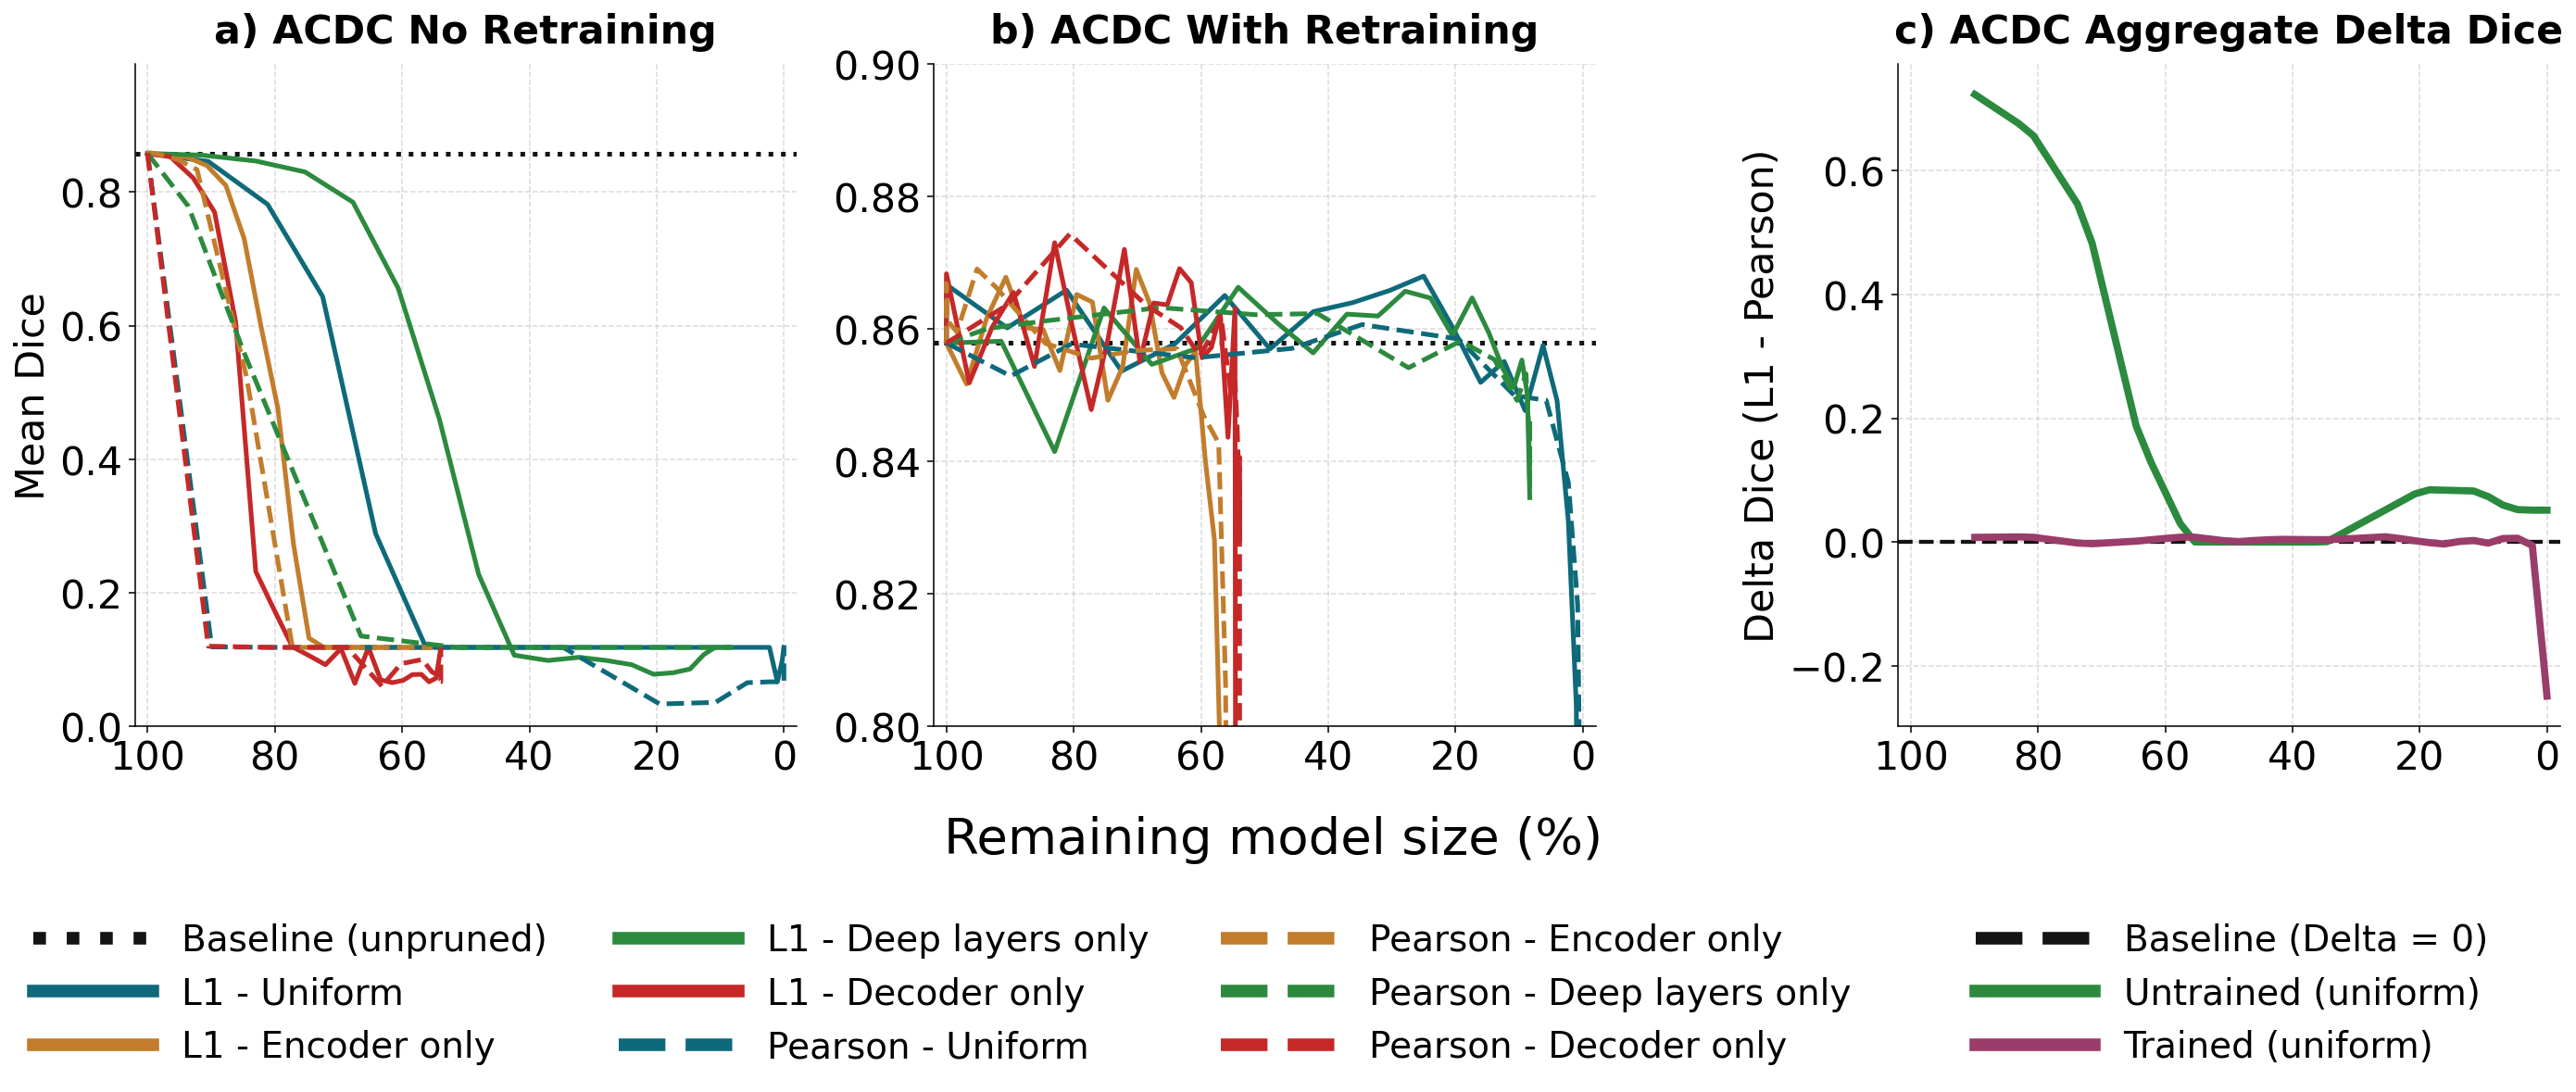

In [10]:
# Combined comparison grid: Untrained, Trained, and Aggregated ΔDice
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator

apply_publication_style()


def _plot_acdc_methods_by_area_on_ax(
    ax,
    dfs,
    *,
    include_baseline_point=False,
    title="ACDC: L1 vs Correlation Across Pruning Areas",
    ylim=None,
    title_fontsize=22,
    axis_fontsize=20,
    tick_fontsize=17,
    legend_fontsize=14,
    show_legend=True,
):
    method_groups = {
        "L1": dfs["acdc"]["l1"],
        "Pearson": dfs["acdc"]["corr"],
    }

    method_linestyle = {
        "L1": "-",
        "Pearson": "--",
    }

    area_color = {
        "uniform": PUB_COLORS["l1"],
        "encoder": PUB_COLORS["neutral"],
        "deep": PUB_COLORS["good"],
        "decoder": PUB_COLORS["warn"],
    }

    area_label = {
        "uniform": "Uniform",
        "encoder": "Encoder only",
        "deep": "Deep layers only",
        "decoder": "Decoder only",
    }

    baseline_dice = float(method_groups["L1"].uniform.iloc[0]["mean_dice_fg"])
    ax.axhline(
        baseline_dice,
        linestyle=":",
        linewidth=2.6,
        color="black",
        alpha=0.92,
        label="Baseline (unpruned)",
    )

    x_max = 0.0
    y_vals = [baseline_dice]

    for method_name, group in method_groups.items():
        for area in ["uniform", "encoder", "deep", "decoder"]:
            df = getattr(group, area)
            if df is None or df.empty:
                continue

            if include_baseline_point:
                df_plot = df[["model_size_pct", "mean_dice_fg"]].copy()
            else:
                df_plot = df.iloc[1:][["model_size_pct", "mean_dice_fg"]].copy()

            df_plot = df_plot.sort_values("model_size_pct", ascending=False)
            if df_plot.empty:
                continue

            ax.plot(
                df_plot["model_size_pct"],
                df_plot["mean_dice_fg"],
                linestyle=method_linestyle[method_name],
                linewidth=2.6,
                color=area_color[area],
                label=f"{method_name} - {area_label[area]}",
            )

            x_max = max(x_max, float(df["model_size_pct"].max()))
            y_vals.extend(df_plot["mean_dice_fg"].astype(float).tolist())

    ax.set_xlim(102, -2)

    if ylim is None:
        y_min = min(y_vals)
        y_max = max(y_vals)
        y_span = (y_max - y_min) if y_max > y_min else 0.03
        y_pad = 0.16 * y_span
        lo = max(0.0, y_min - y_pad)
        hi = min(1.0, y_max + y_pad)
        ax.set_ylim(lo, hi)
    else:
        ax.set_ylim(*ylim)

    ax.set_xlabel("")
    ax.set_ylabel("Mean Dice", fontsize=axis_fontsize)
    ax.set_title(title, fontsize=title_fontsize, pad=12)
    ax.tick_params(axis="both", labelsize=tick_fontsize)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6, integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.set_box_aspect(1)

    despine(ax)
    if show_legend:
        ax.legend(frameon=False, fontsize=legend_fontsize, loc="lower left", ncol=1)


def _aggregate_delta_curve_local(
    dfs_obj,
    *,
    include_baseline_point=False,
    n_grid=40,
    agg_stat="median",
    min_areas_required=1,
):
    l1_group = dfs_obj["acdc"]["l1"]
    corr_group = dfs_obj["acdc"]["corr"]
    areas = ["uniform"]

    def _prep(df):
        d = df[["model_size_pct", "mean_dice_fg"]].copy() if include_baseline_point else df.iloc[1:][["model_size_pct", "mean_dice_fg"]].copy()
        d = d.dropna().drop_duplicates(subset=["model_size_pct"]).sort_values("model_size_pct")
        if d.empty:
            return None, None
        return d["model_size_pct"].to_numpy(float), d["mean_dice_fg"].to_numpy(float)

    curves = []
    for area in areas:
        x1, y1 = _prep(getattr(l1_group, area))
        x2, y2 = _prep(getattr(corr_group, area))
        if x1 is None or x2 is None or len(x1) < 2 or len(x2) < 2:
            continue
        lo = max(float(np.min(x1)), float(np.min(x2)))
        hi = min(float(np.max(x1)), float(np.max(x2)))
        if hi <= lo:
            continue
        curves.append((x1, y1, x2, y2, lo, hi))

    if not curves:
        raise ValueError("No valid overlapping L1/Correlation curves found.")

    gx = np.linspace(min(c[4] for c in curves), max(c[5] for c in curves), int(n_grid))

    cols = []
    for x1, y1, x2, y2, lo, hi in curves:
        d = np.interp(gx, x1, y1) - np.interp(gx, x2, y2)
        valid = (gx >= lo) & (gx <= hi)
        d = np.where(valid, d, np.nan)
        cols.append(pd.Series(d))

    mat = pd.concat(cols, axis=1)
    n_areas = mat.notna().sum(axis=1)
    agg = mat.median(axis=1, skipna=True) if agg_stat == "median" else mat.mean(axis=1, skipna=True)

    out = pd.DataFrame({"model_size_pct": gx, "delta_dice": agg, "n_areas": n_areas})
    out = out[out["n_areas"] >= int(min_areas_required)].copy()
    out = out.sort_values("model_size_pct", ascending=False)
    if out.empty:
        raise ValueError("No points left after min_areas_required filter.")
    return out


def _plot_aggregate_delta_on_ax(
    ax,
    dfs_untrained_obj,
    dfs_trained_obj,
    *,
    include_baseline_point=False,
    n_grid=40,
    agg_stat="median",
    min_areas_required=1,
    title="ACDC (Uniform): Delta Dice (L1 - Pearson)",
    title_fontsize=22,
    axis_fontsize=22,
    tick_fontsize=22,
    legend_fontsize=14,
    show_legend=True,
):
    if "_aggregate_delta_curve" in globals():
        d_untrained = _aggregate_delta_curve(
            dfs_untrained_obj,
            include_baseline_point=include_baseline_point,
            n_grid=n_grid,
            agg_stat=agg_stat,
            min_areas_required=min_areas_required,
        )
        d_trained = _aggregate_delta_curve(
            dfs_trained_obj,
            include_baseline_point=include_baseline_point,
            n_grid=n_grid,
            agg_stat=agg_stat,
            min_areas_required=min_areas_required,
        )
    else:
        d_untrained = _aggregate_delta_curve_local(
            dfs_untrained_obj,
            include_baseline_point=include_baseline_point,
            n_grid=n_grid,
            agg_stat=agg_stat,
            min_areas_required=min_areas_required,
        )
        d_trained = _aggregate_delta_curve_local(
            dfs_trained_obj,
            include_baseline_point=include_baseline_point,
            n_grid=n_grid,
            agg_stat=agg_stat,
            min_areas_required=min_areas_required,
        )

    ax.axhline(0.0, color="black", linewidth=2.2, linestyle="--", alpha=0.92, label="Baseline (Delta = 0)")

    ax.plot(
        d_untrained["model_size_pct"],
        d_untrained["delta_dice"],
        linewidth=4.0,
        linestyle="-",
        color=PUB_COLORS["good"],
        label="Untrained (uniform)",
    )
    ax.plot(
        d_trained["model_size_pct"],
        d_trained["delta_dice"],
        linewidth=4.0,
        linestyle="-",
        color=PUB_COLORS["corr"],
        label="Trained (uniform)",
    )

    # ax.axhline(0.0, color="black", linewidth=2.2, linestyle="--", alpha=0.92, label="Baseline (Delta = 0)")

    x_max = max(float(d_untrained["model_size_pct"].max()), float(d_trained["model_size_pct"].max()))
    ax.set_xlim(102, -2)

    y_min = min(float(d_untrained["delta_dice"].min()), float(d_trained["delta_dice"].min()))
    y_max = max(float(d_untrained["delta_dice"].max()), float(d_trained["delta_dice"].max()))
    y_span = (y_max - y_min) if (y_max > y_min) else 0.05
    y_pad = 0.16 * y_span
    #ax.set_ylim(y_min - y_pad, y_max + y_pad)
    ax.set_ylim=(-0.25, 0.75),

    ax.set_xlabel("")
    ax.set_ylabel("Delta Dice (L1 - Pearson)", fontsize=axis_fontsize)
    ax.set_title(title, fontsize=title_fontsize, pad=12)
    ax.tick_params(axis="both", labelsize=tick_fontsize)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6, integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.set_box_aspect(1)

    despine(ax)
    if show_legend:
        ax.legend(frameon=False, fontsize=legend_fontsize, loc="best")


fig, axes = plt.subplots(1, 3, figsize=(25.5, 8.8), constrained_layout=False)

_plot_acdc_methods_by_area_on_ax(
    axes[0],
    dfs_untrained,
    include_baseline_point=True,
    title="a) ACDC No Retraining",
    axis_fontsize=22,
    tick_fontsize=22,
    show_legend=False,
)

_plot_acdc_methods_by_area_on_ax(
    axes[1],
    dfs_trained,
    include_baseline_point=True,
    title="b) ACDC With Retraining",
    ylim=(0.8, 0.9),
    axis_fontsize=22,
    tick_fontsize=22,
    show_legend=False,
)
axes[1].set_ylabel("")

_plot_aggregate_delta_on_ax(
    axes[2],
    dfs_untrained,
    dfs_trained,
    include_baseline_point=False,
    n_grid=40,
    agg_stat="median",
    min_areas_required=1,
    title="c) ACDC Aggregate Delta Dice",
    show_legend=False,
)

# Shared legend for the first two ACDC panels
handles12, labels12 = axes[0].get_legend_handles_labels()
seen = set()
uniq12 = []
for h, l in zip(handles12, labels12):
    if l not in seen:
        uniq12.append((h, l))
        seen.add(l)
if uniq12:
    leg12 = fig.legend(
        [u[0] for u in uniq12],
        [u[1] for u in uniq12],
        loc="lower center",
        bbox_to_anchor=(0.37, -0.025),
        ncol=3,
        frameon=False,
        fontsize=20,
        handlelength=3.3
    )
    for h in leg12.get_lines():
        h.set_linewidth(7.0)

# Separate legend under third panel
handles3, labels3 = axes[2].get_legend_handles_labels()
if handles3:
    leg3 = fig.legend(
        handles3,
        labels3,
        loc="lower center",
        bbox_to_anchor=(0.76, -0.025),
        ncol=1,
        frameon=False,
        fontsize=20,
        handlelength=3.3
    )
    for h in leg3.get_lines():
        h.set_linewidth(7.0)

fig.subplots_adjust(wspace=0.42, bottom=0.30)
pos1 = axes[1].get_position()
axes[1].set_position([pos1.x0 - 0.045, pos1.y0, pos1.width, pos1.height])
pos2 = axes[2].get_position()
axes[2].set_position([pos2.x0 - 0.04, pos2.y0, pos2.width, pos2.height])
fig.supxlabel("Remaining model size (%)", fontsize=28, x=0.47, y=0.18)
plt.show()





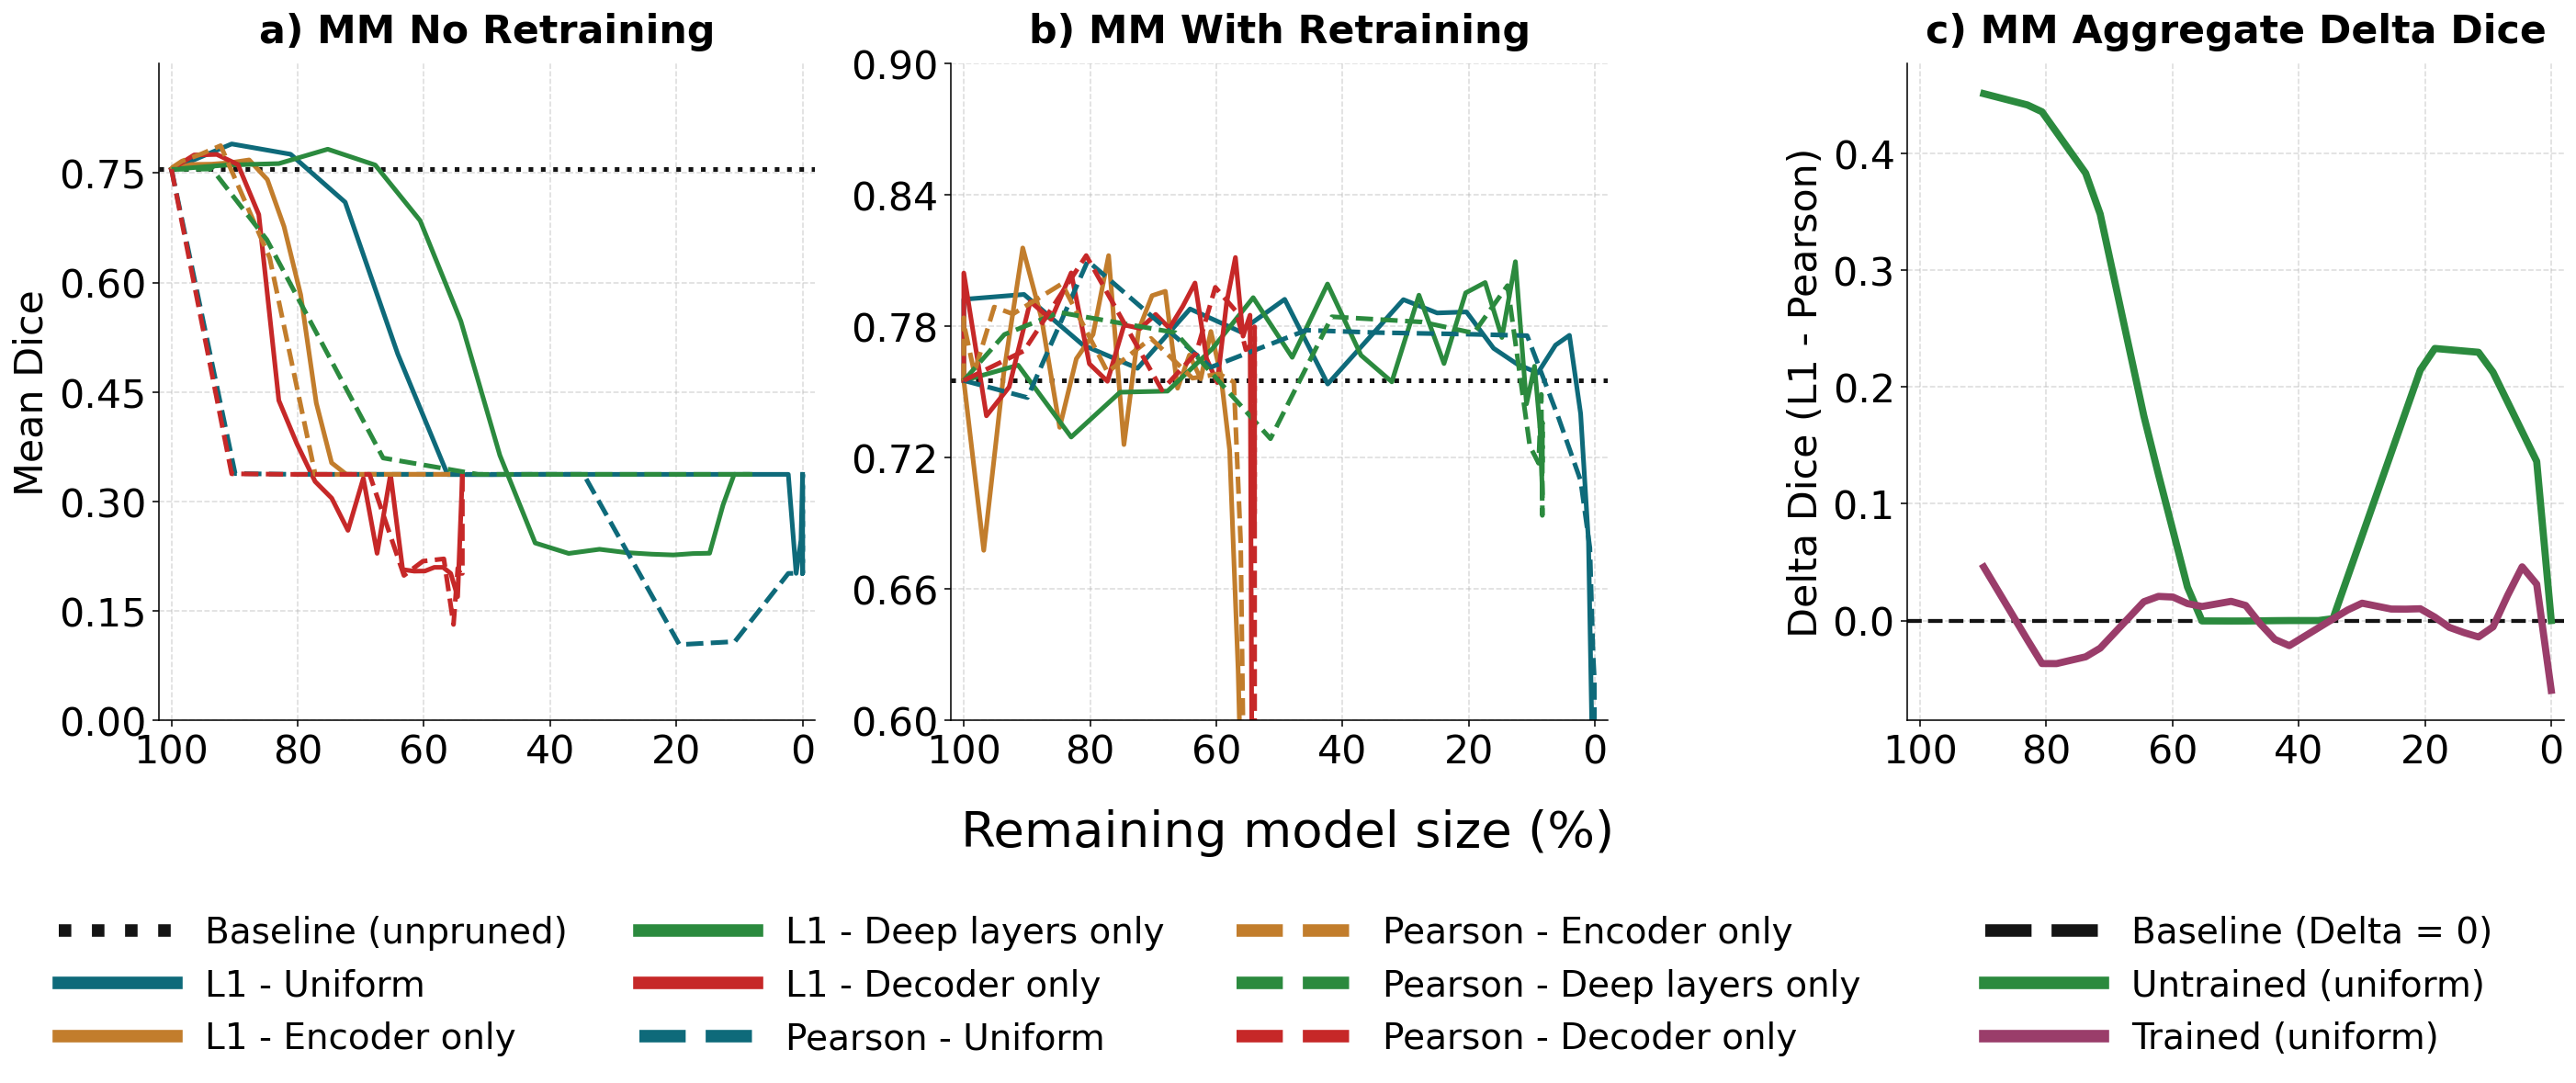

In [11]:
# Combined comparison grid: Untrained, Trained, and Aggregated ΔDice (MM)
# Reuse the plotting helpers from the cell above by remapping MM -> acdc key.
dfs_untrained_mm = {"acdc": dfs_untrained["mm"]}
dfs_trained_mm = {"acdc": dfs_trained["mm"]}

fig, axes = plt.subplots(1, 3, figsize=(25.5, 8.8), constrained_layout=False)

_plot_acdc_methods_by_area_on_ax(
    axes[0],
    dfs_untrained_mm,
    include_baseline_point=True,
    title="a) MM No Retraining",
    axis_fontsize=22,
    tick_fontsize=22,
    show_legend=False,
)

_plot_acdc_methods_by_area_on_ax(
    axes[1],
    dfs_trained_mm,
    include_baseline_point=True,
    title="b) MM With Retraining",
    ylim=(0.6, 0.9),
    axis_fontsize=22,
    tick_fontsize=22,
    show_legend=False,
)
axes[1].set_ylabel("")

_plot_aggregate_delta_on_ax(
    axes[2],
    dfs_untrained_mm,
    dfs_trained_mm,
    include_baseline_point=False,
    n_grid=40,
    agg_stat="median",
    min_areas_required=1,
    title="c) MM Aggregate Delta Dice",
    show_legend=False,
)

# Shared legend for the first two MM panels
handles12, labels12 = axes[0].get_legend_handles_labels()
seen = set()
uniq12 = []
for h, l in zip(handles12, labels12):
    if l not in seen:
        uniq12.append((h, l))
        seen.add(l)
if uniq12:
    leg12 = fig.legend(
        [u[0] for u in uniq12],
        [u[1] for u in uniq12],
        loc="lower center",
        bbox_to_anchor=(0.37, -0.025),
        ncol=3,
        frameon=False,
        fontsize=20,
        handlelength=3.3,
    )
    for h in leg12.get_lines():
        h.set_linewidth(7.0)

# Separate legend under third panel
handles3, labels3 = axes[2].get_legend_handles_labels()
if handles3:
    leg3 = fig.legend(
        handles3,
        labels3,
        loc="lower center",
        bbox_to_anchor=(0.76, -0.025),
        ncol=1,
        frameon=False,
        fontsize=20,
        handlelength=3.3,
    )
    for h in leg3.get_lines():
        h.set_linewidth(7.0)

fig.subplots_adjust(wspace=0.42, bottom=0.30)
pos1 = axes[1].get_position()
axes[1].set_position([pos1.x0 - 0.045, pos1.y0, pos1.width, pos1.height])
pos2 = axes[2].get_position()
axes[2].set_position([pos2.x0 - 0.04, pos2.y0, pos2.width, pos2.height])
fig.supxlabel("Remaining model size (%)", fontsize=28, x=0.47, y=0.18)
plt.show()



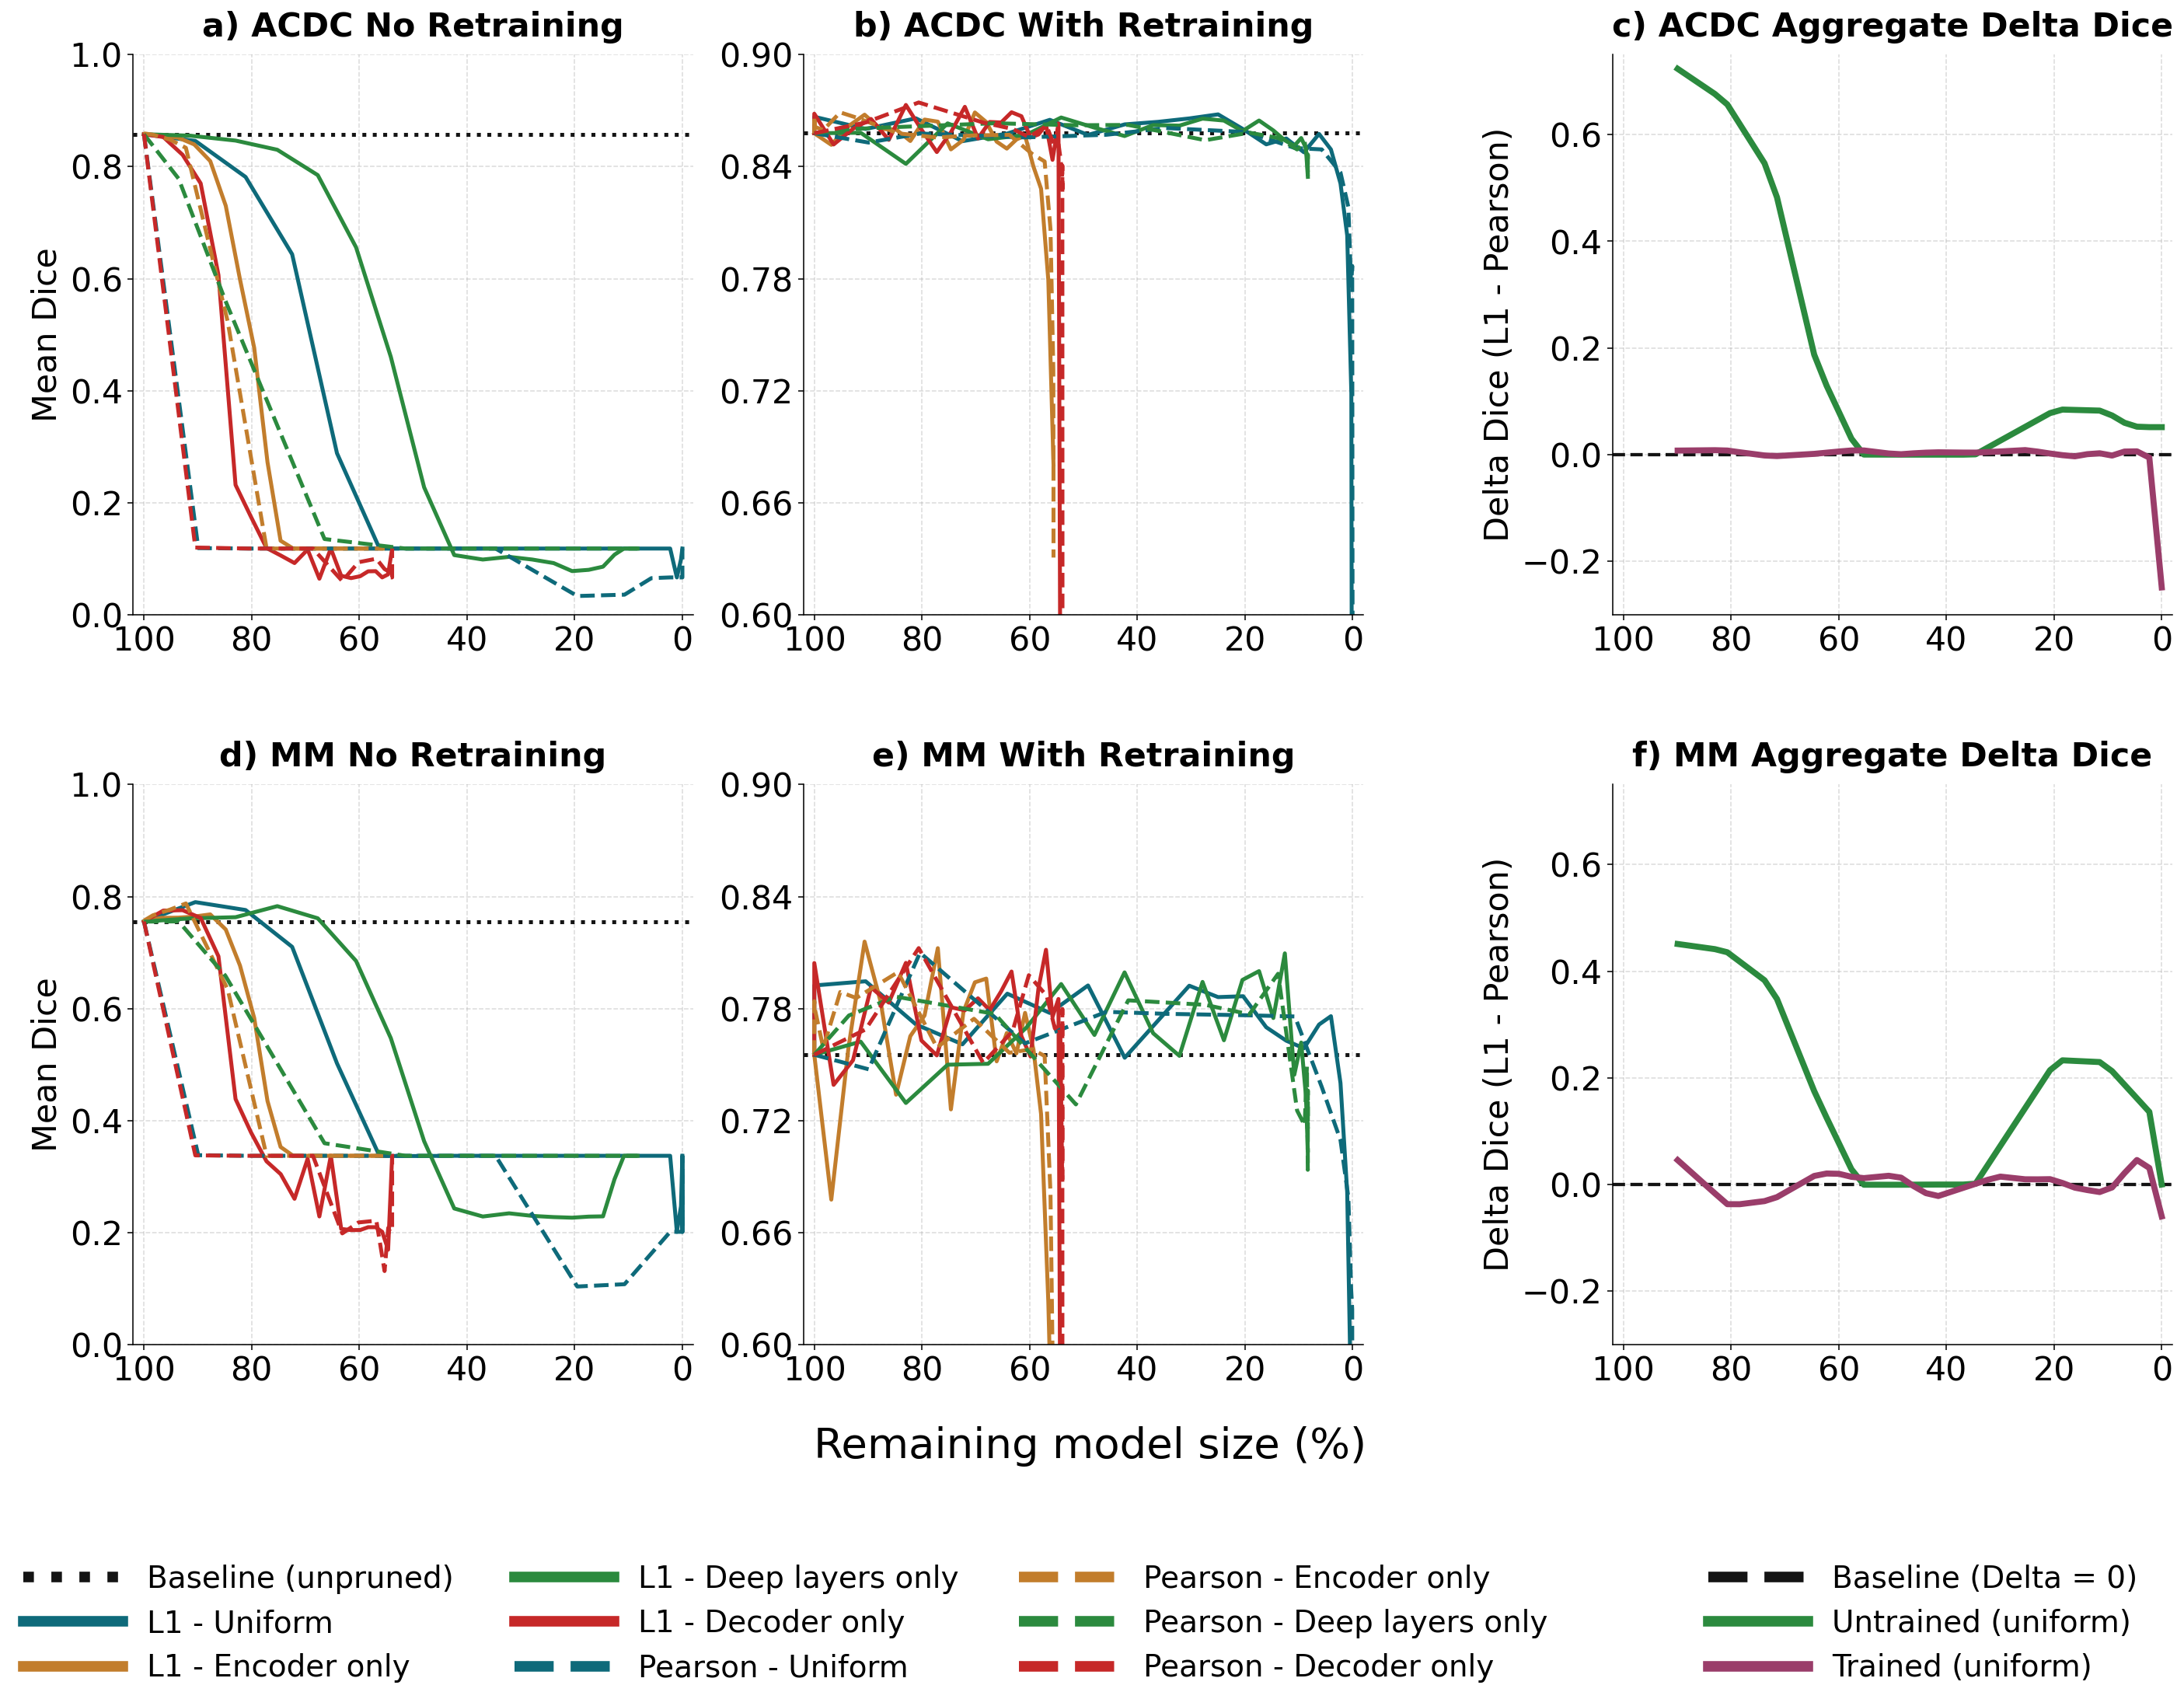

In [12]:
# Combined 2x3 grid: ACDC (top) and MM (bottom)
# Reuse helper functions defined above.
dfs_untrained_acdc = {"acdc": dfs_untrained["acdc"]}
dfs_trained_acdc = {"acdc": dfs_trained["acdc"]}
dfs_untrained_mm = {"acdc": dfs_untrained["mm"]}
dfs_trained_mm = {"acdc": dfs_trained["mm"]}

fig, axes = plt.subplots(2, 3, figsize=(25.5, 17.2), constrained_layout=False)

# Row 1: ACDC
_plot_acdc_methods_by_area_on_ax(
    axes[0, 0],
    dfs_untrained_acdc,
    include_baseline_point=True,
    title="a) ACDC No Retraining",
    ylim=(0.0, 1.0),
    axis_fontsize=22,
    tick_fontsize=22,
    show_legend=False,
)

_plot_acdc_methods_by_area_on_ax(
    axes[0, 1],
    dfs_trained_acdc,
    include_baseline_point=True,
    title="b) ACDC With Retraining",
    ylim=(0.6, 0.9),
    axis_fontsize=22,
    tick_fontsize=22,
    show_legend=False,
)
axes[0, 1].set_ylabel("")

_plot_aggregate_delta_on_ax(
    axes[0, 2],
    dfs_untrained_acdc,
    dfs_trained_acdc,
    include_baseline_point=False,
    n_grid=40,
    agg_stat="median",
    min_areas_required=1,
    title="c) ACDC Aggregate Delta Dice",
    show_legend=False,
)

# Row 2: MM
_plot_acdc_methods_by_area_on_ax(
    axes[1, 0],
    dfs_untrained_mm,
    include_baseline_point=True,
    title="d) MM No Retraining",
    ylim=(0.0, 1.0),
    axis_fontsize=22,
    tick_fontsize=22,
    show_legend=False,
)

_plot_acdc_methods_by_area_on_ax(
    axes[1, 1],
    dfs_trained_mm,
    include_baseline_point=True,
    title="e) MM With Retraining",
    ylim=(0.6, 0.9),
    axis_fontsize=22,
    tick_fontsize=22,
    show_legend=False,
)
axes[1, 1].set_ylabel("")

_plot_aggregate_delta_on_ax(
    axes[1, 2],
    dfs_untrained_mm,
    dfs_trained_mm,
    include_baseline_point=False,
    n_grid=40,
    agg_stat="median",
    min_areas_required=1,
    title="f) MM Aggregate Delta Dice",
    show_legend=False,
)


# Force identical y-range for both aggregate panels (robust against ax.set_ylim shadowing)
common_ylim = (-0.30, 0.75)
type(axes[0, 2]).set_ylim(axes[0, 2], *common_ylim)
type(axes[1, 2]).set_ylim(axes[1, 2], *common_ylim)

# Shared legend for method/area curves (first two columns)
handles12, labels12 = axes[0, 0].get_legend_handles_labels()
seen = set()
uniq12 = []
for h, l in zip(handles12, labels12):
    if l not in seen:
        uniq12.append((h, l))
        seen.add(l)
if uniq12:
    leg12 = fig.legend(
        [u[0] for u in uniq12],
        [u[1] for u in uniq12],
        loc="lower center",
        bbox_to_anchor=(0.36, -0.05),
        ncol=3,
        frameon=False,
        fontsize=20,
        handlelength=3.3,
    )
    for h in leg12.get_lines():
        h.set_linewidth(7.0)

# Shared legend for aggregate-delta curves (third column)
handles3, labels3 = axes[0, 2].get_legend_handles_labels()
if handles3:
    leg3 = fig.legend(
        handles3,
        labels3,
        loc="lower center",
        bbox_to_anchor=(0.77, -0.05),
        ncol=1,
        frameon=False,
        fontsize=20,
        handlelength=3.3,
    )
    for h in leg3.get_lines():
        h.set_linewidth(7.0)

fig.subplots_adjust(wspace=0.42, hspace=0.0, bottom=0.10)

for row in [0, 1]:
    pos1 = axes[row, 1].get_position()
    axes[row, 1].set_position([pos1.x0 - 0.045, pos1.y0, pos1.width, pos1.height])
    pos2 = axes[row, 2].get_position()
    axes[row, 2].set_position([pos2.x0 - 0.04, pos2.y0, pos2.width, pos2.height])

fig.supxlabel("Remaining model size (%)", fontsize=28, x=0.47, y=0.08)
plt.show()




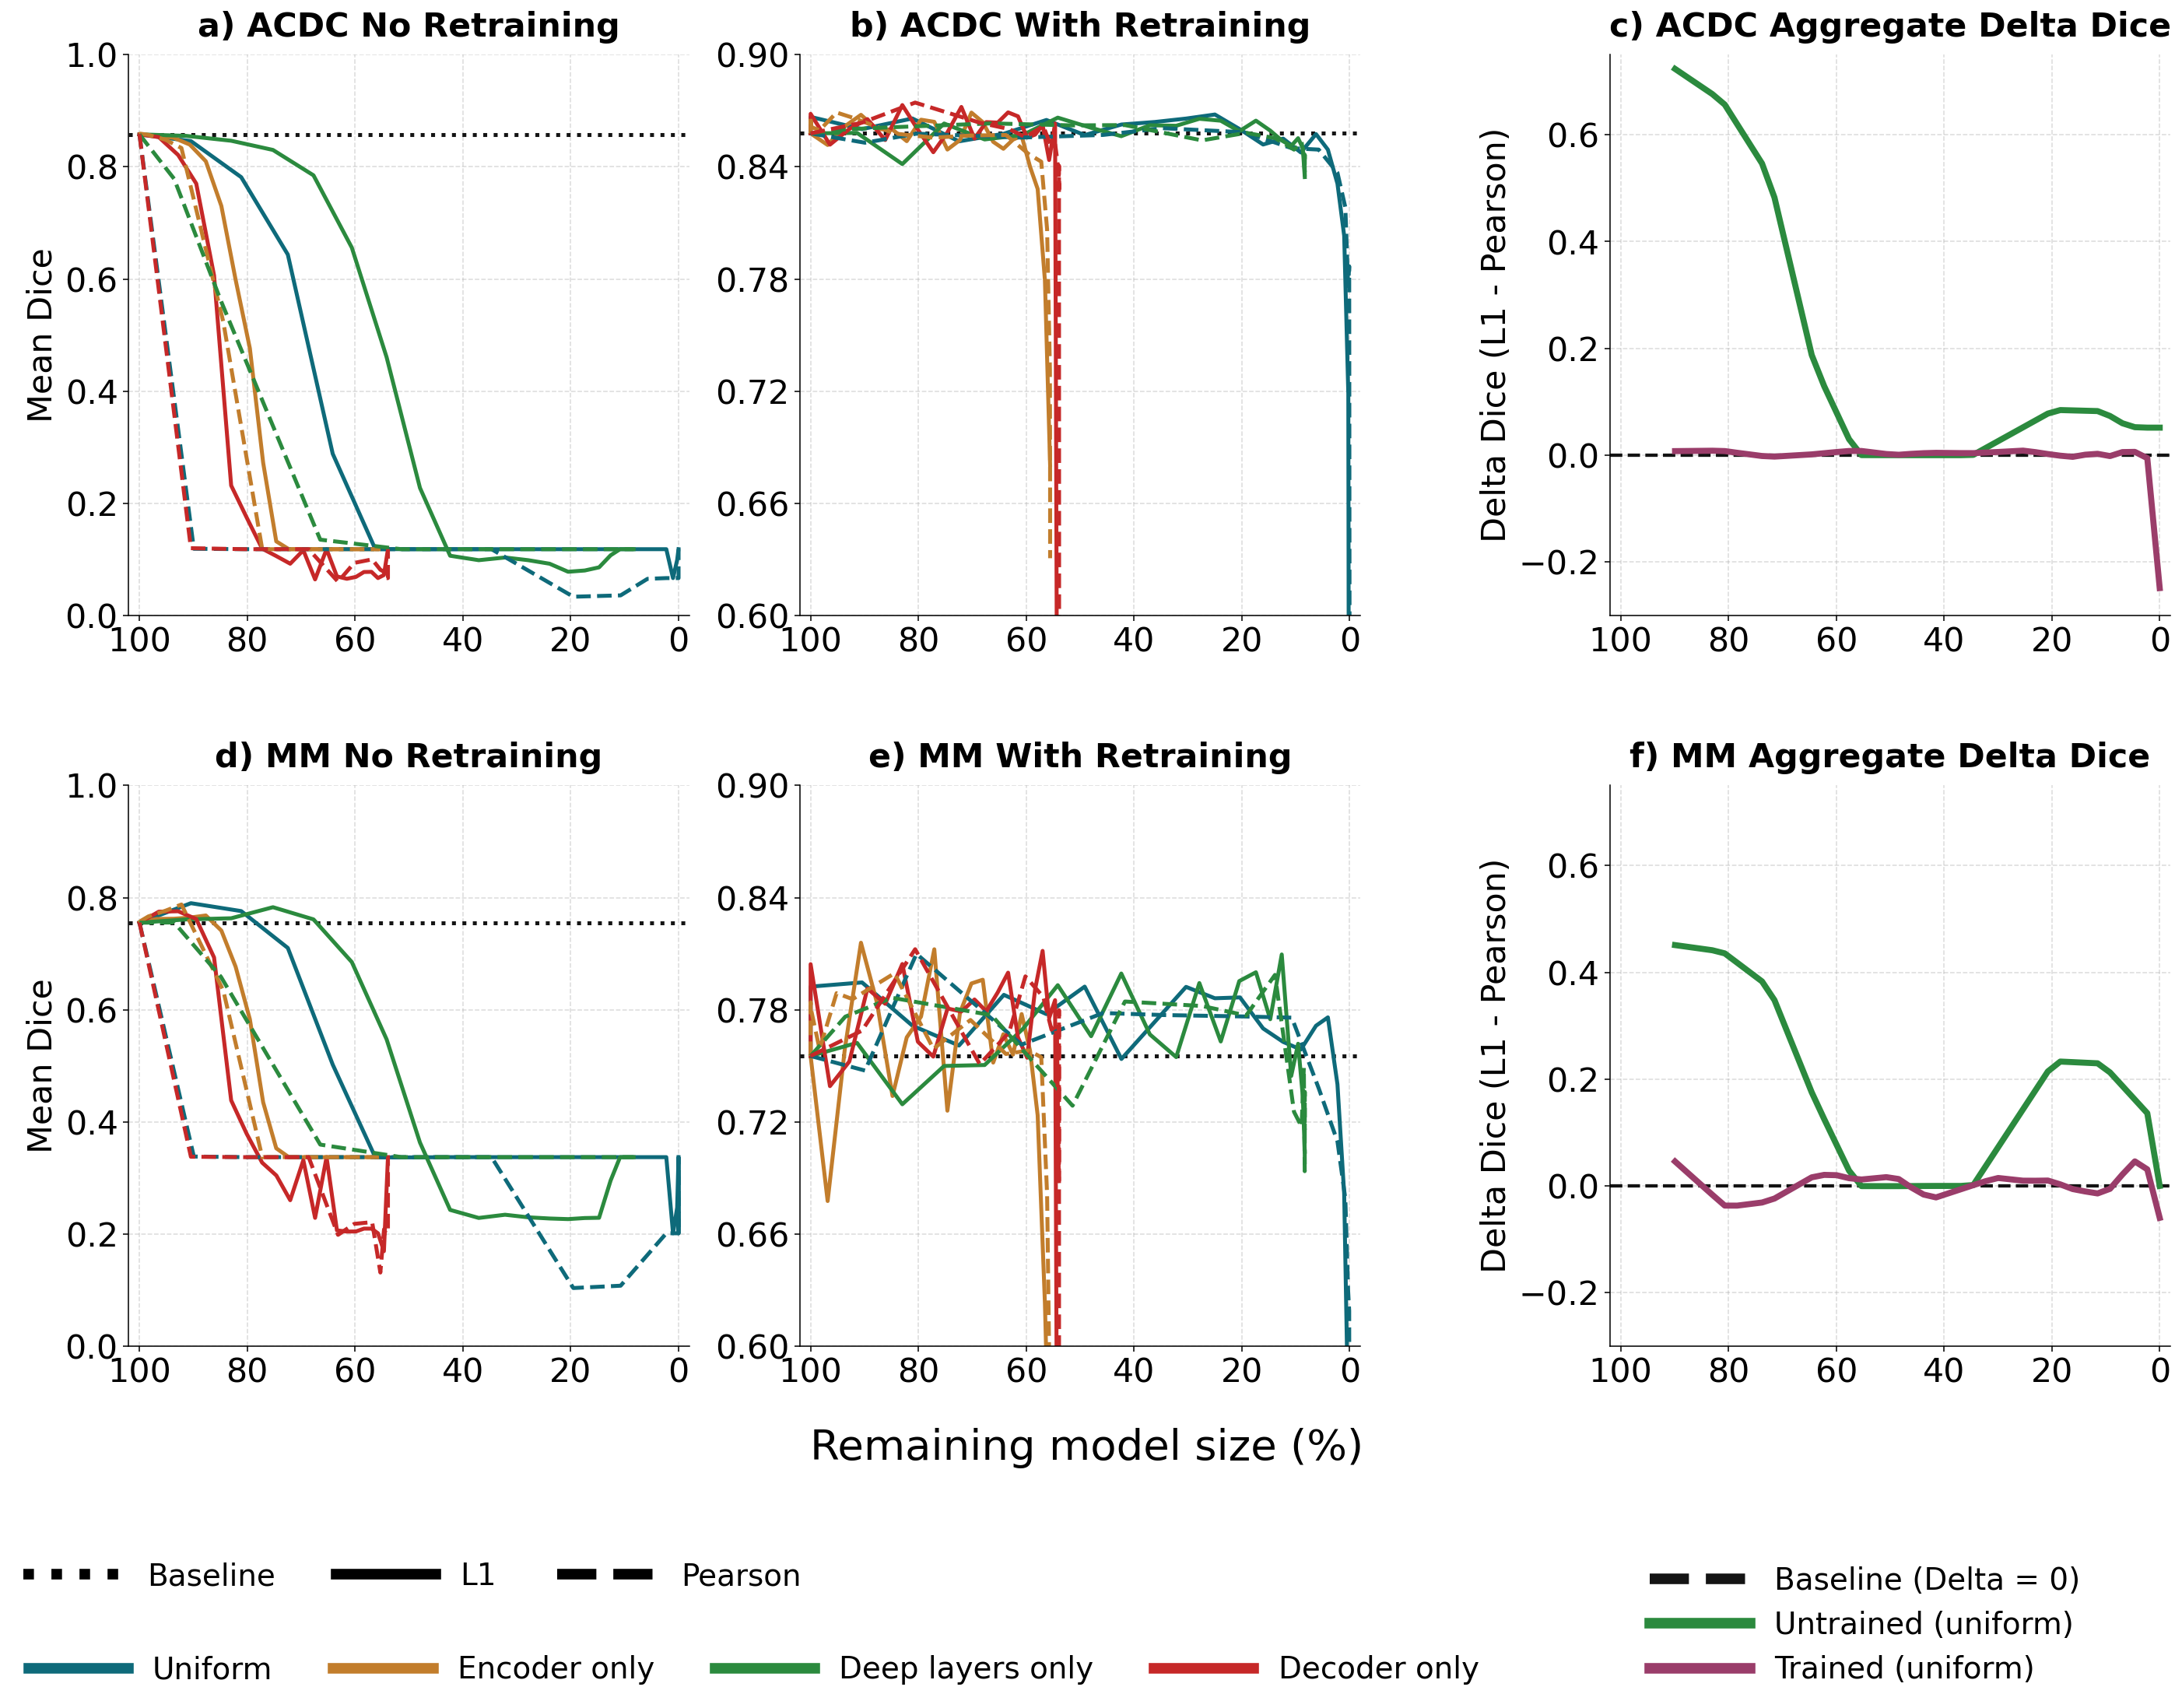

In [13]:
# Combined 2x3 grid with simplified left legends:
# (1) linestyle semantics, (2) color semantics.
from matplotlib.lines import Line2D

# Reuse helper functions defined above.
dfs_untrained_acdc = {"acdc": dfs_untrained["acdc"]}
dfs_trained_acdc = {"acdc": dfs_trained["acdc"]}
dfs_untrained_mm = {"acdc": dfs_untrained["mm"]}
dfs_trained_mm = {"acdc": dfs_trained["mm"]}

fig, axes = plt.subplots(2, 3, figsize=(25.5, 17.2), constrained_layout=False)

# Row 1: ACDC
_plot_acdc_methods_by_area_on_ax(
    axes[0, 0],
    dfs_untrained_acdc,
    include_baseline_point=True,
    title="a) ACDC No Retraining",
    ylim=(0.0, 1.0),
    axis_fontsize=22,
    tick_fontsize=22,
    show_legend=False,
)

_plot_acdc_methods_by_area_on_ax(
    axes[0, 1],
    dfs_trained_acdc,
    include_baseline_point=True,
    title="b) ACDC With Retraining",
    ylim=(0.6, 0.9),
    axis_fontsize=22,
    tick_fontsize=22,
    show_legend=False,
)
axes[0, 1].set_ylabel("")

_plot_aggregate_delta_on_ax(
    axes[0, 2],
    dfs_untrained_acdc,
    dfs_trained_acdc,
    include_baseline_point=False,
    n_grid=40,
    agg_stat="median",
    min_areas_required=1,
    title="c) ACDC Aggregate Delta Dice",
    show_legend=False,
)

# Row 2: MM
_plot_acdc_methods_by_area_on_ax(
    axes[1, 0],
    dfs_untrained_mm,
    include_baseline_point=True,
    title="d) MM No Retraining",
    ylim=(0.0, 1.0),
    axis_fontsize=22,
    tick_fontsize=22,
    show_legend=False,
)

_plot_acdc_methods_by_area_on_ax(
    axes[1, 1],
    dfs_trained_mm,
    include_baseline_point=True,
    title="e) MM With Retraining",
    ylim=(0.6, 0.9),
    axis_fontsize=22,
    tick_fontsize=22,
    show_legend=False,
)
axes[1, 1].set_ylabel("")

_plot_aggregate_delta_on_ax(
    axes[1, 2],
    dfs_untrained_mm,
    dfs_trained_mm,
    include_baseline_point=False,
    n_grid=40,
    agg_stat="median",
    min_areas_required=1,
    title="f) MM Aggregate Delta Dice",
    show_legend=False,
)

# Force identical y-range for both aggregate panels.
common_ylim = (-0.30, 0.75)
type(axes[0, 2]).set_ylim(axes[0, 2], *common_ylim)
type(axes[1, 2]).set_ylim(axes[1, 2], *common_ylim)

# Legend 1 (linestyles): Baseline vs L1 vs Pearson
linestyle_handles = [
    Line2D([0], [0], color="black", linestyle=":", linewidth=7.0, label="Baseline"),
    Line2D([0], [0], color="black", linestyle="-", linewidth=7.0, label="L1"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=7.0, label="Pearson"),
]
fig.legend(
    handles=linestyle_handles,
    loc="lower center",
    bbox_to_anchor=(0.227, -0.0),
    ncol=3,
    frameon=False,
    fontsize=20,
    handlelength=3.3,
)

# Legend 2 (colors): pruning areas
color_handles = [
    Line2D([0], [0], color=PUB_COLORS["l1"], linestyle="-", linewidth=7.0, label="Uniform"),
    Line2D([0], [0], color=PUB_COLORS["neutral"], linestyle="-", linewidth=7.0, label="Encoder only"),
    Line2D([0], [0], color=PUB_COLORS["good"], linestyle="-", linewidth=7.0, label="Deep layers only"),
    Line2D([0], [0], color=PUB_COLORS["warn"], linestyle="-", linewidth=7.0, label="Decoder only"),
]
fig.legend(
    handles=color_handles,
    loc="lower center",
    bbox_to_anchor=(0.35, -0.05),
    ncol=4,
    frameon=False,
    fontsize=20,
    handlelength=3.3,
)

# Shared legend for aggregate-delta curves (third column)
handles3, labels3 = axes[0, 2].get_legend_handles_labels()
if handles3:
    leg3 = fig.legend(
        handles3,
        labels3,
        loc="lower center",
        bbox_to_anchor=(0.75, -0.05),
        ncol=1,
        frameon=False,
        fontsize=20,
        handlelength=3.3,
    )
    for h in leg3.get_lines():
        h.set_linewidth(7.0)

fig.subplots_adjust(wspace=0.42, hspace=0.0, bottom=0.10)

for row in [0, 1]:
    pos1 = axes[row, 1].get_position()
    axes[row, 1].set_position([pos1.x0 - 0.045, pos1.y0, pos1.width, pos1.height])
    pos2 = axes[row, 2].get_position()
    axes[row, 2].set_position([pos2.x0 - 0.04, pos2.y0, pos2.width, pos2.height])

fig.supxlabel("Remaining model size (%)", fontsize=28, x=0.47, y=0.08)
plt.show()



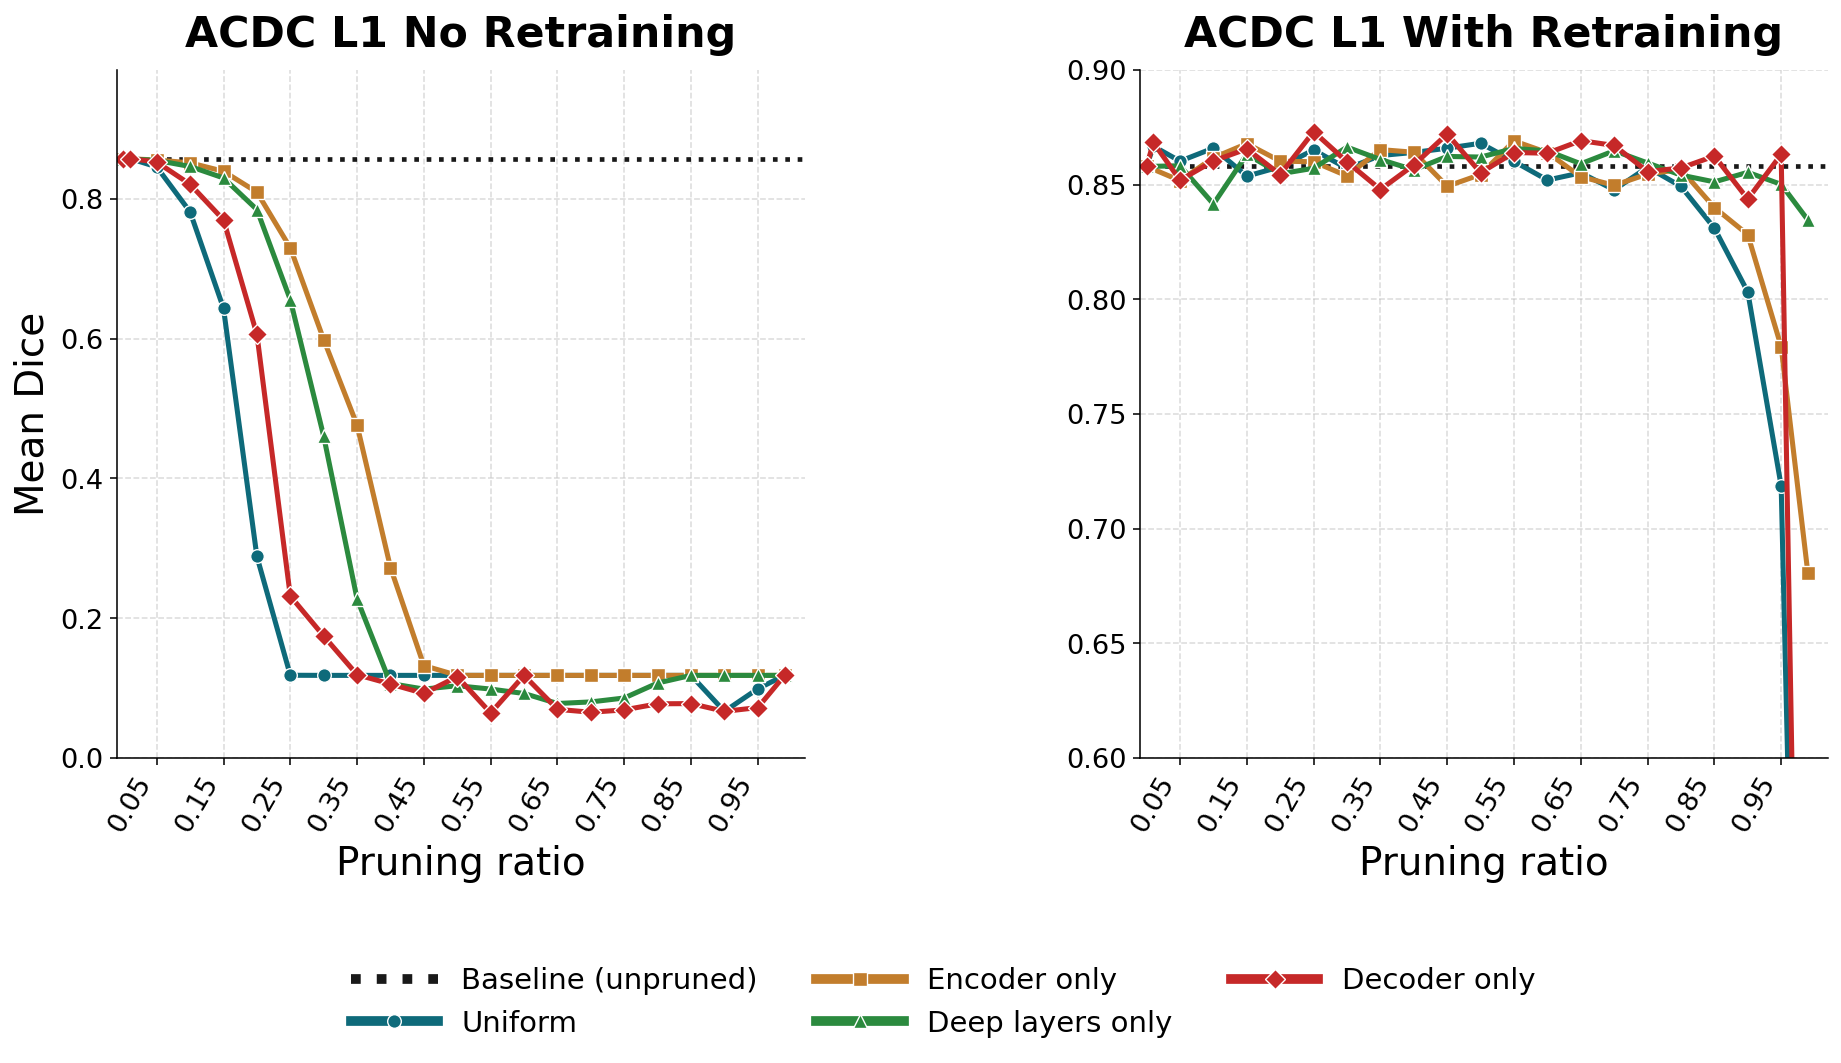

In [14]:
# ACDC L1 only: Dice vs pruning ratio (derived from run_name), with/without retraining
import re
import numpy as np
import matplotlib.pyplot as plt

apply_publication_style()


def _pruning_ratio_from_run_name(run_name: str) -> float:
    if run_name == "baseline":
        return 0.0
    nums = [int(x) for x in re.findall(r"\d+", str(run_name))]
    if not nums:
        return np.nan
    # L1 run names encode per-block pruning percentages; use max active percentage.
    return max(nums) / 100.0


def _prepare_area_df(df):
    d = df[["run_name", "mean_dice_fg"]].copy()
    d["pruning_ratio"] = d["run_name"].map(_pruning_ratio_from_run_name)
    d = d.dropna(subset=["pruning_ratio", "mean_dice_fg"]).copy()
    d = d.sort_values("pruning_ratio")
    d = d.drop_duplicates(subset=["pruning_ratio"], keep="first")
    return d


def _plot_acdc_l1_ratio_panel(ax, dfs_obj, title):
    group = dfs_obj["acdc"]["l1"]

    area_color = {
        "uniform": PUB_COLORS["l1"],
        "encoder": PUB_COLORS["neutral"],
        "deep": PUB_COLORS["good"],
        "decoder": PUB_COLORS["warn"],
    }
    area_label = {
        "uniform": "Uniform",
        "encoder": "Encoder only",
        "deep": "Deep layers only",
        "decoder": "Decoder only",
    }
    area_marker = {
        "uniform": "o",
        "encoder": "s",
        "deep": "^",
        "decoder": "D",
    }

    baseline = float(group.uniform.iloc[0]["mean_dice_fg"])
    ax.axhline(
        baseline,
        linestyle=":",
        linewidth=2.4,
        color="black",
        alpha=0.9,
        label="Baseline (unpruned)",
    )

    y_vals = [baseline]

    for area in ["uniform", "encoder", "deep", "decoder"]:
        df_area = _prepare_area_df(getattr(group, area))
        if df_area.empty:
            continue

        ax.plot(
            df_area["pruning_ratio"],
            df_area["mean_dice_fg"],
            linestyle="-",
            linewidth=2.6,
            marker=area_marker[area],
            markersize=7,
            markeredgecolor="white",
            markeredgewidth=0.7,
            color=area_color[area],
            label=area_label[area],
        )
        y_vals.extend(df_area["mean_dice_fg"].astype(float).tolist())

    ax.set_xlim(-0.01, 1.02)
    xticks = np.arange(0.05, 1.0, 0.10)
    ax.set_xticks(xticks)
    ax.set_xticklabels([f"{x:.2f}" for x in xticks], rotation=60, ha="right")

    y_min = min(y_vals)
    y_max = max(y_vals)
    y_span = (y_max - y_min) if y_max > y_min else 0.03
    y_pad = 0.16 * y_span
    ax.set_ylim(max(0.0, y_min - y_pad), min(1.0, y_max + y_pad))

    ax.set_title(title, fontsize=22, pad=12)
    ax.set_xlabel("Pruning ratio", fontsize=20)
    ax.set_ylabel("Mean Dice", fontsize=20)
    ax.tick_params(axis="both", labelsize=14)
    ax.set_box_aspect(1)
    despine(ax)


fig, axes = plt.subplots(1, 2, figsize=(16.8, 7.8), constrained_layout=False)

_plot_acdc_l1_ratio_panel(
    axes[0],
    dfs_untrained,
    title="ACDC L1 No Retraining",
)

_plot_acdc_l1_ratio_panel(
    axes[1],
    dfs_trained,
    title="ACDC L1 With Retraining",
)
axes[1].set_ylim(0.6, 0.9)
axes[1].set_ylabel("")

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    leg = fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.03),
        ncol=3,
        frameon=False,
        fontsize=15,
        handlelength=3.0,
    )
    for h in leg.get_lines():
        h.set_linewidth(5.0)

fig.subplots_adjust(wspace=0.28, bottom=0.25)
plt.show()


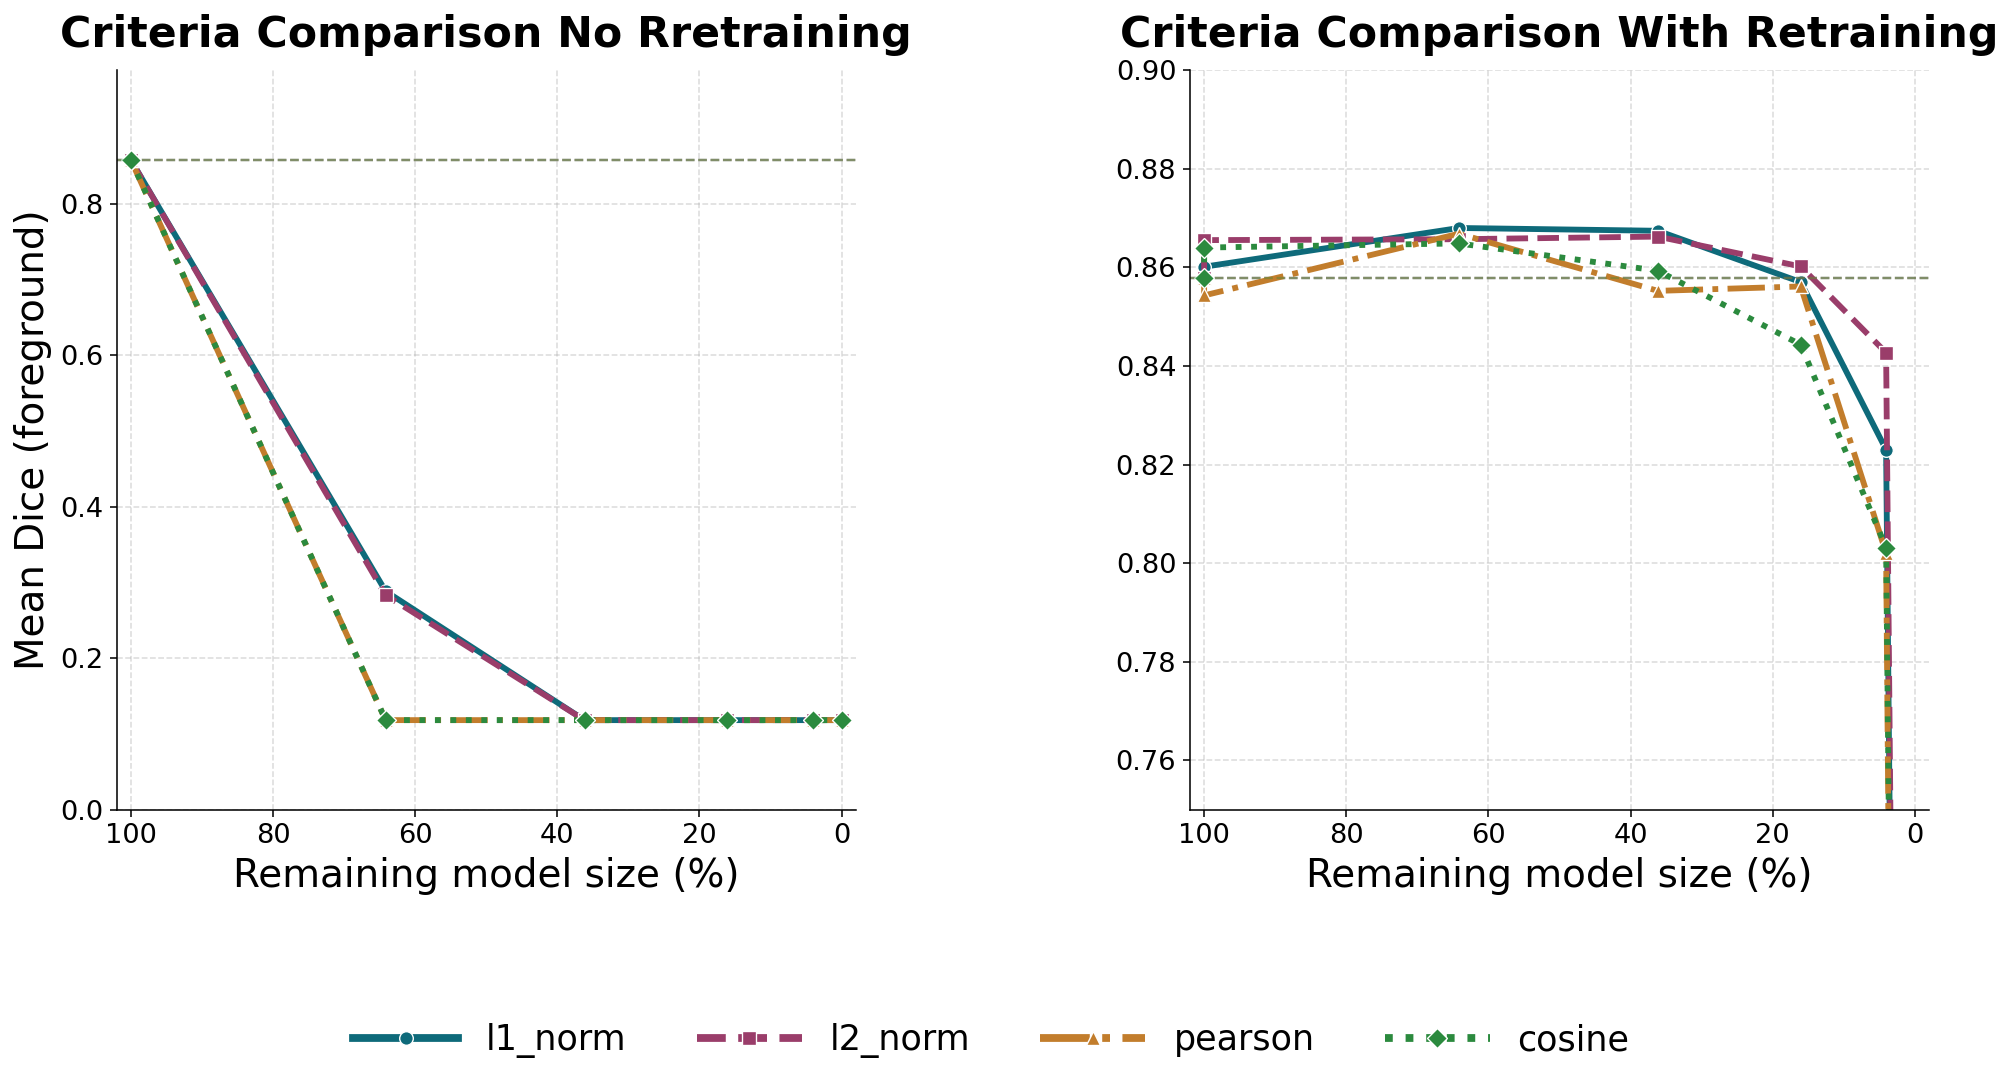

In [15]:
# Criteria comparison in 2 panels: Dice vs remaining model size (adjustable y-lims)
import matplotlib.pyplot as plt

apply_publication_style()

# -------------------------
# Adjustable y-limits
# Set to None for auto-scaling
# -------------------------
YLIM_UNTRAINED = None      # e.g. (0.0, 1.0)
YLIM_TRAINED = (0.75, 0.9)


def _plot_criteria_panel(
    ax,
    dfs_by_label,
    *,
    title,
    ylim=None,
    include_baseline_point=True,
    axis_fontsize=20,
    tick_fontsize=14,
):
    palette = [
        PUB_COLORS["l1"],
        PUB_COLORS["corr"],
        PUB_COLORS["neutral"],
        PUB_COLORS["good"],
        PUB_COLORS["warn"],
    ]
    markers = ["o", "s", "^", "D", "P", "X", "v", "*"]
    linestyles = ["-", "--", "-.", ":"]

    x_max = 0.0
    y_vals = []

    for i, (label, df) in enumerate(dfs_by_label.items()):
        if df is None or df.empty:
            continue

        if include_baseline_point:
            df_plot = df[["model_size_pct", "mean_dice_fg"]].copy()
        else:
            df_plot = df.iloc[1:][["model_size_pct", "mean_dice_fg"]].copy()

        df_plot = df_plot.sort_values("model_size_pct", ascending=False)
        if df_plot.empty:
            continue

        color = palette[i % len(palette)]
        marker = markers[i % len(markers)]
        linestyle = linestyles[i % len(linestyles)]

        ax.plot(
            df_plot["model_size_pct"],
            df_plot["mean_dice_fg"],
            marker=marker,
            linestyle=linestyle,
            linewidth=3.0,
            markersize=7,
            markeredgecolor="white",
            markeredgewidth=0.7,
            color=color,
            label=label,
        )

        baseline_dice = float(df.iloc[0]["mean_dice_fg"])
        ax.axhline(
            baseline_dice,
            linestyle="--",
            linewidth=1.2,
            color=color,
            alpha=0.35,
        )

        x_max = max(x_max, float(df["model_size_pct"].max()))
        y_vals.extend(df_plot["mean_dice_fg"].astype(float).tolist())

    x_pad = 0.02 * x_max if x_max > 0 else 1.0
    ax.set_xlim(x_max + x_pad, 0 - x_pad)

    if ylim is None:
        if y_vals:
            y_min = min(y_vals)
            y_max = max(y_vals)
            y_span = (y_max - y_min) if y_max > y_min else 0.03
            y_pad = 0.16 * y_span
            ax.set_ylim(max(0.0, y_min - y_pad), min(1.0, y_max + y_pad))
        else:
            ax.set_ylim(0.0, 1.0)
    else:
        ax.set_ylim(*ylim)

    ax.set_title(title, fontsize=22, pad=12)
    ax.set_xlabel("Remaining model size (%)", fontsize=axis_fontsize)
    ax.set_ylabel("Mean Dice (foreground)", fontsize=axis_fontsize)
    ax.tick_params(axis="both", labelsize=tick_fontsize)
    ax.set_box_aspect(1)
    despine(ax)


fig, axes = plt.subplots(1, 2, figsize=(18.0, 8.0), constrained_layout=False)

_plot_criteria_panel(
    axes[0],
    criteria_plot_dfs_untrained,
    title="Criteria Comparison No Rretraining",
    ylim=YLIM_UNTRAINED,
    include_baseline_point=True,
)

_plot_criteria_panel(
    axes[1],
    criteria_plot_dfs_trained,
    title="Criteria Comparison With Retraining",
    ylim=YLIM_TRAINED,
    include_baseline_point=True,
)
axes[1].set_ylabel("")

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    leg = fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.03),
        ncol=4,
        frameon=False,
        fontsize=18,
        handlelength=3.0,
    )
    for h in leg.get_lines():
        h.set_linewidth(4.0)

fig.subplots_adjust(wspace=0.22, bottom=0.22)
plt.show()


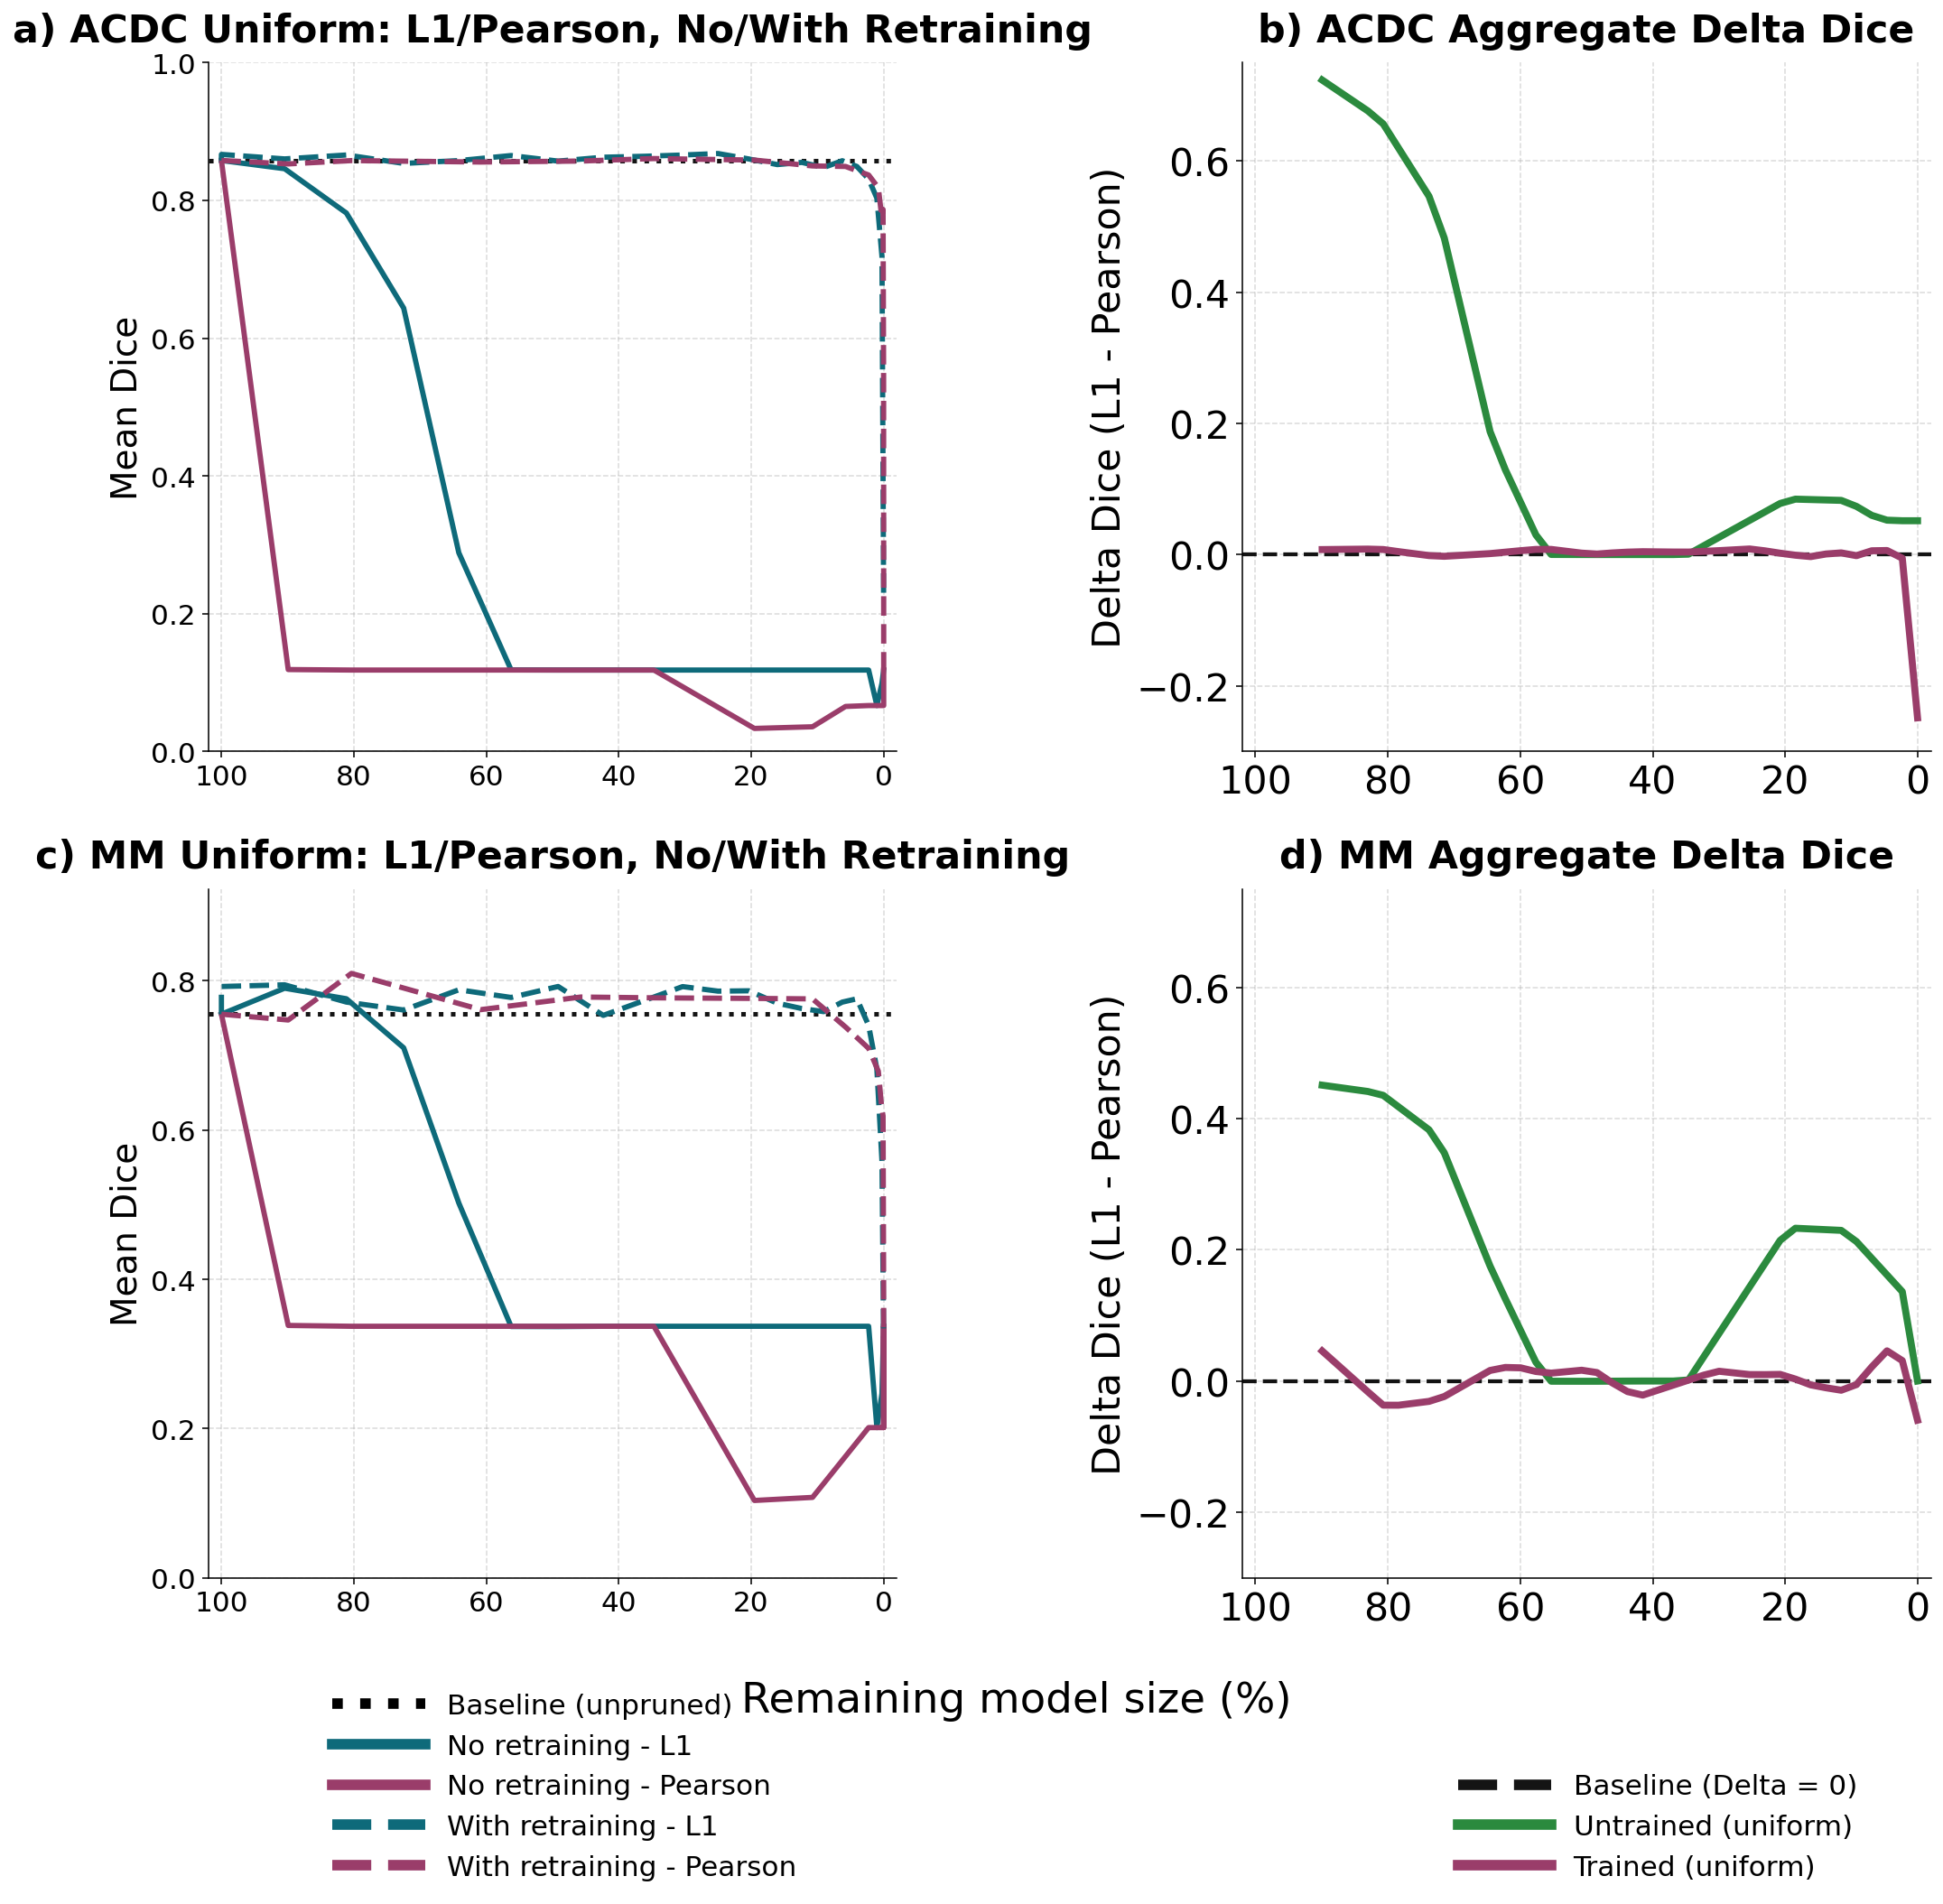

In [16]:
# Report figure: 2x2 grid (datasets x {uniform curves, aggregate delta})
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

apply_publication_style()


def _plot_uniform_l1_corr_4lines_on_ax(
    ax,
    dataset_key,
    *,
    include_baseline_point=True,
    title="",
    ylim=None,
    axis_fontsize=20,
    tick_fontsize=16,
    legend_fontsize=13,
    show_legend=False,
):
    # Curves to plot: {L1, Pearson} x {No retraining, With retraining}
    curves = [
        ("No retraining - L1", dfs_untrained[dataset_key]["l1"].uniform, PUB_COLORS["l1"], "-"),
        ("No retraining - Pearson", dfs_untrained[dataset_key]["corr"].uniform, PUB_COLORS["corr"], "-"),
        ("With retraining - L1", dfs_trained[dataset_key]["l1"].uniform, PUB_COLORS["l1"], "--"),
        ("With retraining - Pearson", dfs_trained[dataset_key]["corr"].uniform, PUB_COLORS["corr"], "--"),
    ]

    # Baseline from uniform L1 untrained (same unpruned reference convention as existing cells)
    baseline_dice = float(dfs_untrained[dataset_key]["l1"].uniform.iloc[0]["mean_dice_fg"])
    ax.axhline(
        baseline_dice,
        linestyle=":",
        linewidth=2.6,
        color="black",
        alpha=0.92,
        label="Baseline (unpruned)",
    )

    y_vals = [baseline_dice]

    for label, df, color, linestyle in curves:
        if df is None or df.empty:
            continue

        if include_baseline_point:
            df_plot = df[["model_size_pct", "mean_dice_fg"]].copy()
        else:
            df_plot = df.iloc[1:][["model_size_pct", "mean_dice_fg"]].copy()

        df_plot = df_plot.sort_values("model_size_pct", ascending=False)
        if df_plot.empty:
            continue

        ax.plot(
            df_plot["model_size_pct"],
            df_plot["mean_dice_fg"],
            linewidth=3.0,
            linestyle=linestyle,
            color=color,
            label=label,
        )
        y_vals.extend(df_plot["mean_dice_fg"].astype(float).tolist())

    ax.set_xlim(102, -2)

    if ylim is None:
        y_min = min(y_vals)
        y_max = max(y_vals)
        y_span = (y_max - y_min) if y_max > y_min else 0.03
        y_pad = 0.16 * y_span
        ax.set_ylim(max(0.0, y_min - y_pad), min(1.0, y_max + y_pad))
    else:
        ax.set_ylim(*ylim)

    ax.set_title(title, fontsize=22, pad=12)
    ax.set_xlabel("")
    ax.set_ylabel("Mean Dice", fontsize=axis_fontsize)
    ax.tick_params(axis="both", labelsize=tick_fontsize)
    ax.set_box_aspect(1)
    despine(ax)

    if show_legend:
        ax.legend(frameon=False, fontsize=legend_fontsize, loc="lower left")


fig, axes = plt.subplots(2, 2, figsize=(18.8, 16.2), constrained_layout=False)

# Row 1: ACDC
_plot_uniform_l1_corr_4lines_on_ax(
    axes[0, 0],
    "acdc",
    include_baseline_point=True,
    title="a) ACDC Uniform: L1/Pearson, No/With Retraining",
    show_legend=False,
)

_plot_aggregate_delta_on_ax(
    axes[0, 1],
    {"acdc": dfs_untrained["acdc"]},
    {"acdc": dfs_trained["acdc"]},
    include_baseline_point=False,
    n_grid=40,
    agg_stat="median",
    min_areas_required=1,
    title="b) ACDC Aggregate Delta Dice",
    show_legend=False,
)

# Row 2: MM
_plot_uniform_l1_corr_4lines_on_ax(
    axes[1, 0],
    "mm",
    include_baseline_point=True,
    title="c) MM Uniform: L1/Pearson, No/With Retraining",
    show_legend=False,
)

_plot_aggregate_delta_on_ax(
    axes[1, 1],
    {"acdc": dfs_untrained["mm"]},
    {"acdc": dfs_trained["mm"]},
    include_baseline_point=False,
    n_grid=40,
    agg_stat="median",
    min_areas_required=1,
    title="d) MM Aggregate Delta Dice",
    show_legend=False,
)

# Match delta-panel y-range across datasets
common_delta_ylim = (-0.30, 0.75)
type(axes[0, 1]).set_ylim(axes[0, 1], *common_delta_ylim)
type(axes[1, 1]).set_ylim(axes[1, 1], *common_delta_ylim)

# Left-column legend (baseline + 4 curves)
left_handles = [
    Line2D([0], [0], color="black", linestyle=":", linewidth=6.0, label="Baseline (unpruned)"),
    Line2D([0], [0], color=PUB_COLORS["l1"], linestyle="-", linewidth=6.0, label="No retraining - L1"),
    Line2D([0], [0], color=PUB_COLORS["corr"], linestyle="-", linewidth=6.0, label="No retraining - Pearson"),
    Line2D([0], [0], color=PUB_COLORS["l1"], linestyle="--", linewidth=6.0, label="With retraining - L1"),
    Line2D([0], [0], color=PUB_COLORS["corr"], linestyle="--", linewidth=6.0, label="With retraining - Pearson"),
]
fig.legend(
    handles=left_handles,
    loc="lower center",
    bbox_to_anchor=(0.30, -0.02),
    ncol=1,
    frameon=False,
    fontsize=16,
    handlelength=3.3,
)

# Right-column legend (aggregate delta)
handles_r, labels_r = axes[0, 1].get_legend_handles_labels()
if handles_r:
    leg_r = fig.legend(
        handles_r,
        labels_r,
        loc="lower center",
        bbox_to_anchor=(0.76, -0.02),
        ncol=1,
        frameon=False,
        fontsize=16,
        handlelength=3.3,
    )
    for h in leg_r.get_lines():
        h.set_linewidth(6.0)

fig.subplots_adjust(wspace=0.28, hspace=0.20, bottom=0.14)
fig.supxlabel("Remaining model size (%)", fontsize=24, x=0.49, y=0.07)
plt.show()


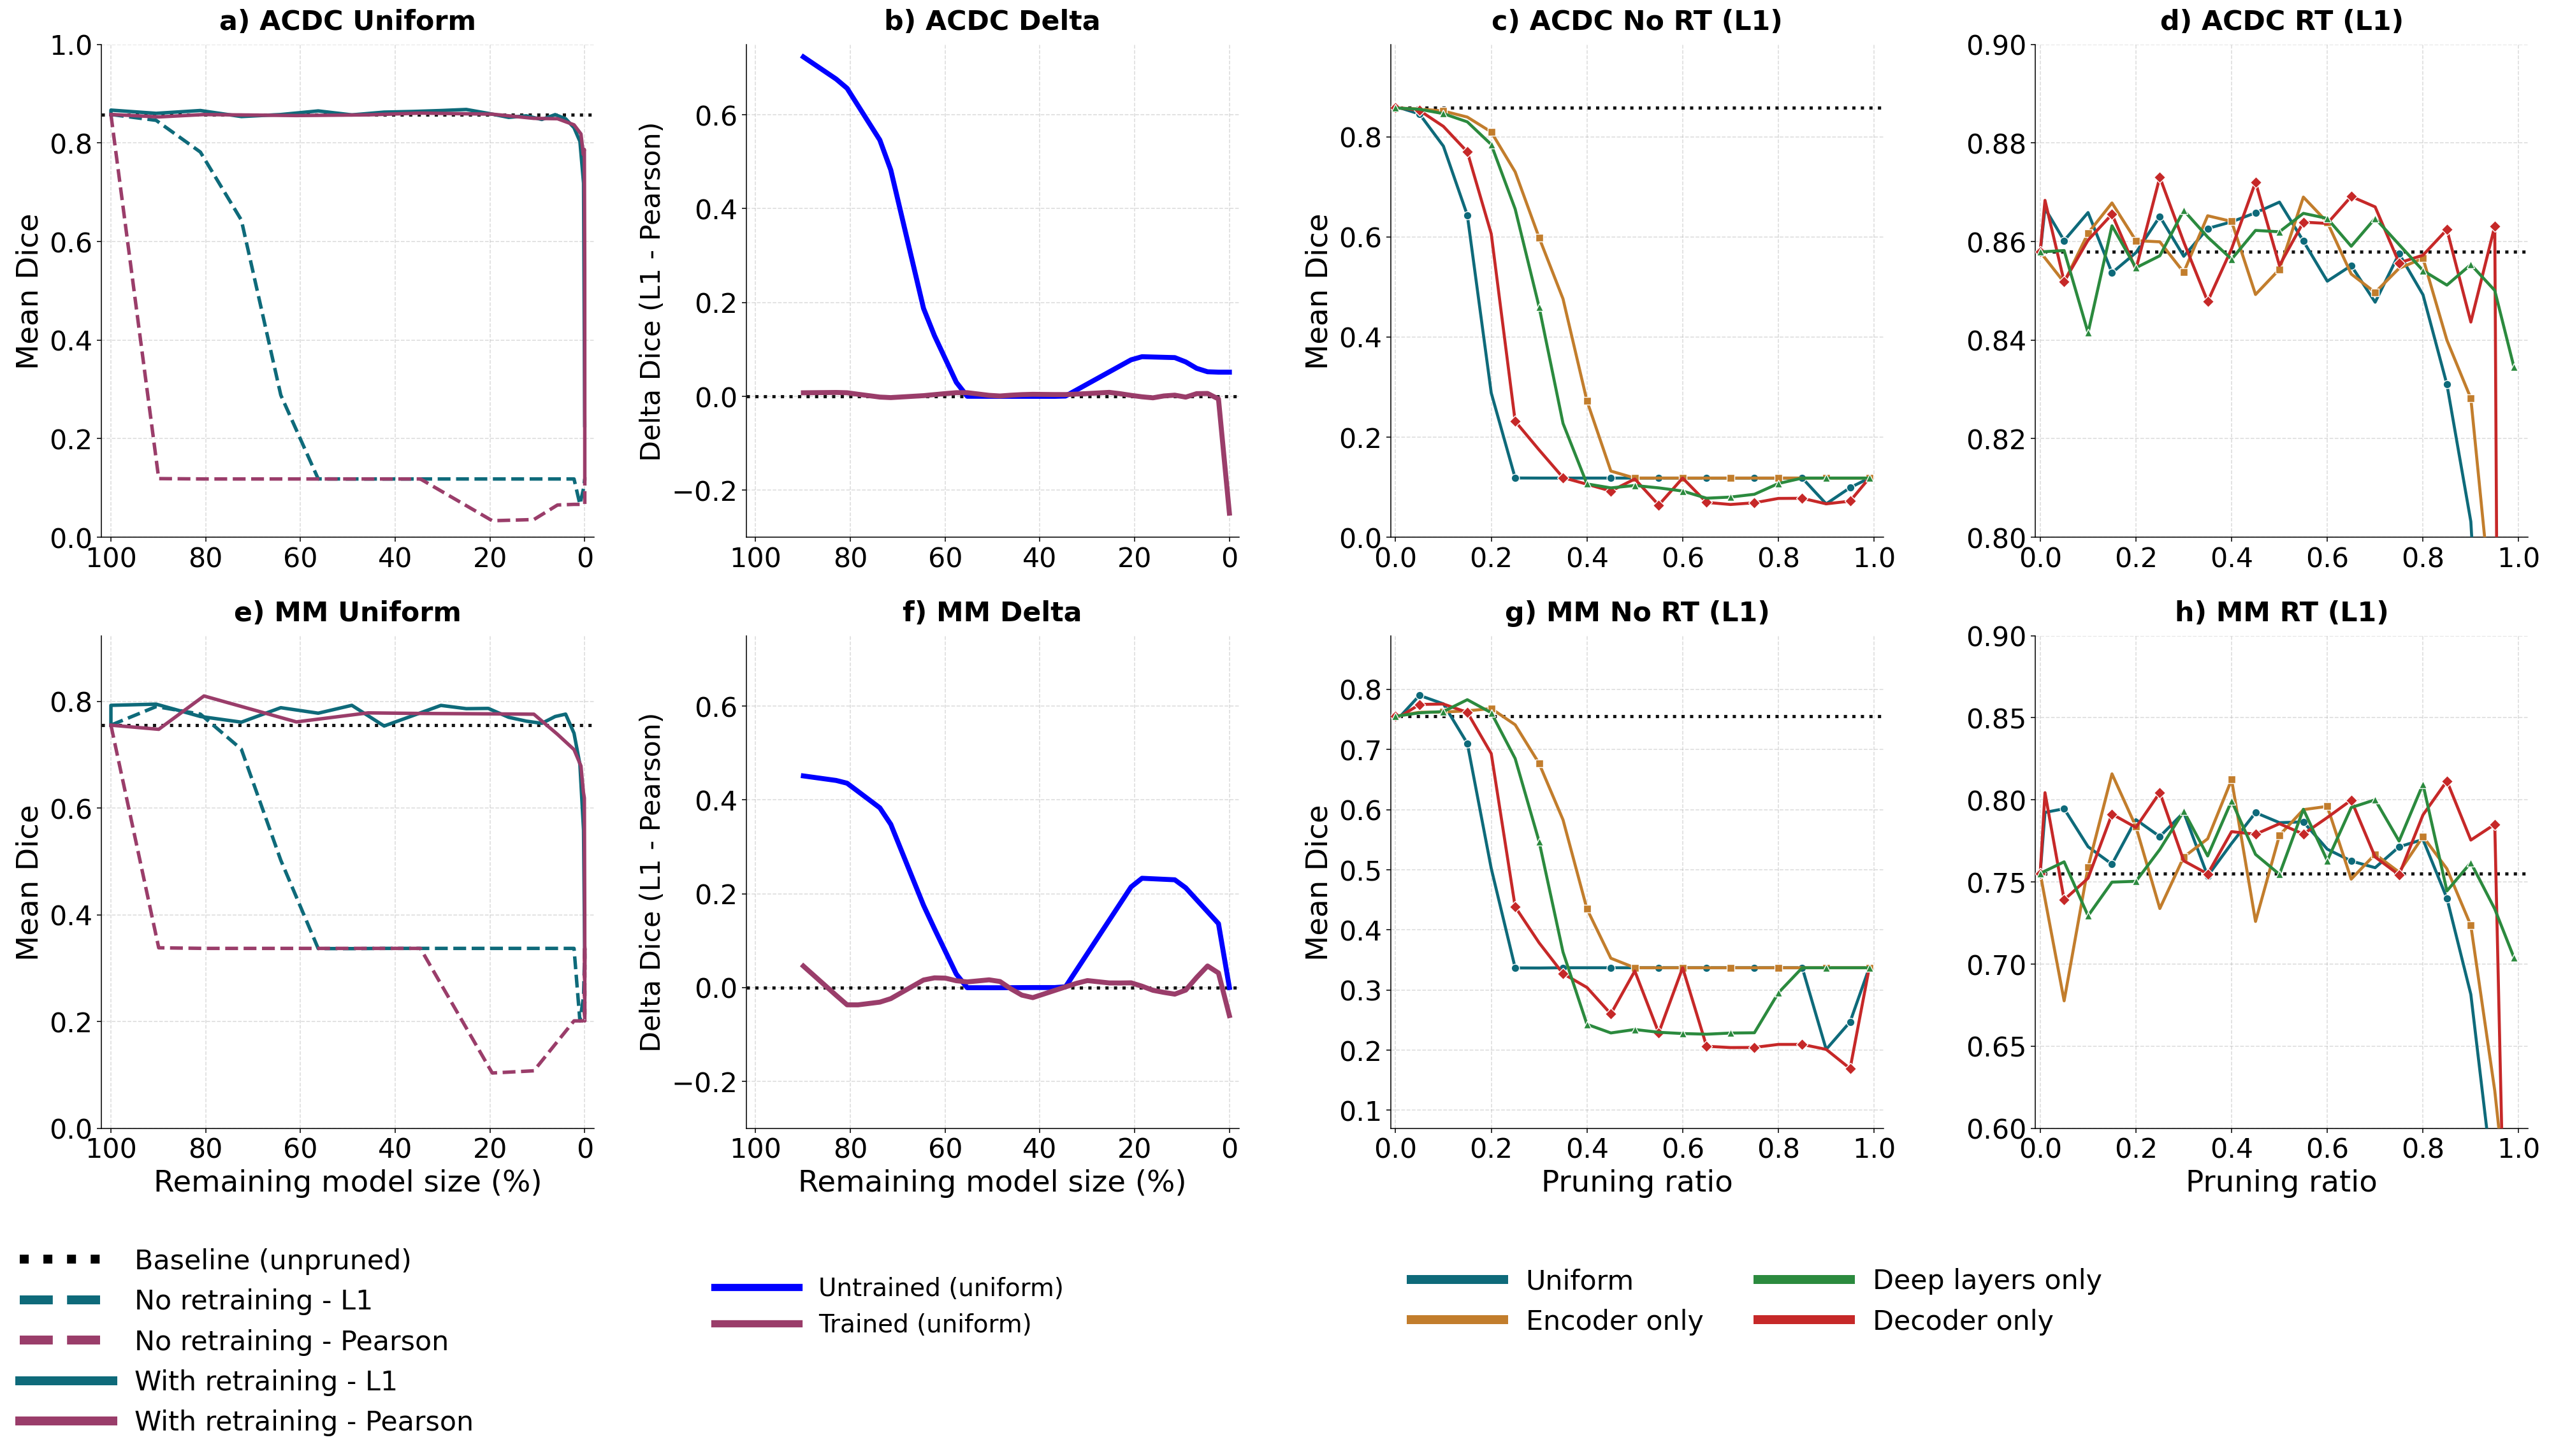

In [17]:
# Report figure: 2x4 grid (datasets x four views)
# Col1: Uniform curves by remaining model size
# Col2: Aggregate delta Dice
# Col3: No retraining, all pruning locations by pruning ratio
# Col4: With retraining, all pruning locations by pruning ratio
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

apply_publication_style()

def _l1_pruning_ratio_from_run_name(run_name: str) -> float:
    if str(run_name) == "baseline":
        return 0.0
    vals = [int(x) for x in __import__("re").findall(r"\d+", str(run_name))]
    if not vals:
        return float("nan")
    return max(vals) / 100.0



def _plot_uniform_l1_corr_4lines_on_ax(
    ax,
    dataset_key,
    *,
    include_baseline_point=True,
    title="",
    ylim=None,
    axis_fontsize=24,
    tick_fontsize=22,
):
    curves = [
        ("No retraining - L1", dfs_untrained[dataset_key]["l1"].uniform, PUB_COLORS["l1"], "--"),
        ("No retraining - Pearson", dfs_untrained[dataset_key]["corr"].uniform, PUB_COLORS["corr"], "--"),
        ("With retraining - L1", dfs_trained[dataset_key]["l1"].uniform, PUB_COLORS["l1"], "-"),
        ("With retraining - Pearson", dfs_trained[dataset_key]["corr"].uniform, PUB_COLORS["corr"], "-"),
    ]

    baseline_dice = float(dfs_untrained[dataset_key]["l1"].uniform.iloc[0]["mean_dice_fg"])
    ax.axhline(baseline_dice, linestyle=":", linewidth=2.6, color="black", alpha=0.92, label="Baseline (unpruned)")

    y_vals = [baseline_dice]
    for label, df, color, linestyle in curves:
        if df is None or df.empty:
            continue
        if include_baseline_point:
            df_plot = df[["model_size_pct", "mean_dice_fg"]].copy()
        else:
            df_plot = df.iloc[1:][["model_size_pct", "mean_dice_fg"]].copy()
        df_plot = df_plot.sort_values("model_size_pct", ascending=False)
        if df_plot.empty:
            continue

        ax.plot(df_plot["model_size_pct"], df_plot["mean_dice_fg"], linewidth=2.8, linestyle=linestyle, color=color, label=label)
        y_vals.extend(df_plot["mean_dice_fg"].astype(float).tolist())

    ax.set_xlim(102, -2)
    if ylim is None:
        y_min = min(y_vals)
        y_max = max(y_vals)
        y_span = (y_max - y_min) if y_max > y_min else 0.03
        y_pad = 0.16 * y_span
        ax.set_ylim(max(0.0, y_min - y_pad), min(1.0, y_max + y_pad))
    else:
        ax.set_ylim(*ylim)

    ax.set_title(title, fontsize=22, pad=12)
    ax.set_xlabel("Remaining model size (%)", fontsize=axis_fontsize)
    ax.set_ylabel("Mean Dice", fontsize=axis_fontsize)
    ax.tick_params(axis="both", labelsize=tick_fontsize)
    ax.set_box_aspect(1)
    despine(ax)


def _plot_methods_by_area_ratio_on_ax(
    ax,
    dfs_obj,
    dataset_key,
    *,
    include_baseline_point=True,
    title="",
    ylim=None,
    axis_fontsize=24,
    tick_fontsize=22,
):
    # L1 only (Pearson removed for ratio panels)
    group = dfs_obj[dataset_key]["l1"]

    area_color = {
        "uniform": PUB_COLORS["l1"],
        "encoder": PUB_COLORS["neutral"],
        "deep": PUB_COLORS["good"],
        "decoder": PUB_COLORS["warn"],
    }
    area_label = {
        "uniform": "Uniform",
        "encoder": "Encoder only",
        "deep": "Deep layers only",
        "decoder": "Decoder only",
    }
    area_marker = {
        "uniform": "o",
        "encoder": "s",
        "deep": "^",
        "decoder": "D",
    }

    baseline_dice = float(group.uniform.iloc[0]["mean_dice_fg"])
    ax.axhline(baseline_dice, linestyle=":", linewidth=2.6, color="black", alpha=0.92, label="Baseline (unpruned)")

    y_vals = [baseline_dice]

    for area in ["uniform", "encoder", "decoder", "deep"]:
        df = getattr(group, area)
        if df is None or df.empty:
            continue

        if include_baseline_point:
            df_plot = df[["run_name", "mean_dice_fg"]].copy()
        else:
            df_plot = df.iloc[1:][["run_name", "mean_dice_fg"]].copy()

        df_plot = df_plot.copy()
        df_plot["pruning_ratio"] = df_plot["run_name"].map(_l1_pruning_ratio_from_run_name)
        df_plot = df_plot.dropna(subset=["pruning_ratio", "mean_dice_fg"])
        df_plot = df_plot.sort_values("pruning_ratio", ascending=True)
        df_plot = df_plot.drop_duplicates(subset=["pruning_ratio"], keep="first")
        if df_plot.empty:
            continue

        z = 6 if area == "deep" else 3
        ax.plot(
            df_plot["pruning_ratio"],
            df_plot["mean_dice_fg"],
            linestyle="-",
            linewidth=2.4,
            marker=area_marker[area],
            markersize=6.5,
            markeredgecolor="white",
            markeredgewidth=0.7,
            markevery=2,
            color=area_color[area],
            label=area_label[area],
            zorder=z,
        )
        y_vals.extend(df_plot["mean_dice_fg"].astype(float).tolist())

    ax.set_xlim(-0.01, 1.02)
    xticks = np.arange(0.0, 1.01, 0.2)
    ax.set_xticks(xticks)
    ax.set_xticklabels([f"{x:.1f}" for x in xticks])

    if ylim is None:
        y_min = min(y_vals)
        y_max = max(y_vals)
        y_span = (y_max - y_min) if y_max > y_min else 0.03
        y_pad = 0.16 * y_span
        ax.set_ylim(max(0.0, y_min - y_pad), min(1.0, y_max + y_pad))
    else:
        ax.set_ylim(*ylim)

    ax.set_title(title, fontsize=22, pad=12)
    ax.set_xlabel("Pruning ratio", fontsize=axis_fontsize)
    ax.set_ylabel("Mean Dice", fontsize=axis_fontsize)
    ax.tick_params(axis="both", labelsize=tick_fontsize)
    ax.set_box_aspect(1)
    despine(ax)


fig, axes = plt.subplots(2, 4, figsize=(36.0, 16.2), constrained_layout=False)

# Row 1: ACDC
_plot_uniform_l1_corr_4lines_on_ax(
    axes[0, 0],
    "acdc",
    include_baseline_point=True,
    title="a) ACDC Uniform",
)
_plot_aggregate_delta_on_ax(
    axes[0, 1],
    {"acdc": dfs_untrained["acdc"]},
    {"acdc": dfs_trained["acdc"]},
    include_baseline_point=False,
    n_grid=40,
    agg_stat="median",
    min_areas_required=1,
    title="b) ACDC Delta",
    show_legend=False,
)
_plot_methods_by_area_ratio_on_ax(
    axes[0, 2],
    dfs_untrained,
    "acdc",
    include_baseline_point=True,
    title="c) ACDC No RT (L1)",
)
_plot_methods_by_area_ratio_on_ax(
    axes[0, 3],
    dfs_trained,
    "acdc",
    include_baseline_point=True,
    title="d) ACDC RT (L1)",
)

# Row 2: MM
_plot_uniform_l1_corr_4lines_on_ax(
    axes[1, 0],
    "mm",
    include_baseline_point=True,
    title="e) MM Uniform",
)
_plot_aggregate_delta_on_ax(
    axes[1, 1],
    {"acdc": dfs_untrained["mm"]},
    {"acdc": dfs_trained["mm"]},
    include_baseline_point=False,
    n_grid=40,
    agg_stat="median",
    min_areas_required=1,
    title="f) MM Delta",
    show_legend=False,
)
_plot_methods_by_area_ratio_on_ax(
    axes[1, 2],
    dfs_untrained,
    "mm",
    include_baseline_point=True,
    title="g) MM No RT (L1)",
)
_plot_methods_by_area_ratio_on_ax(
    axes[1, 3],
    dfs_trained,
    "mm",
    include_baseline_point=True,
    title="h) MM RT (L1)",
)

# Clean repeated y-labels in inner columns
for r in [0, 1]:
    axes[r, 1].set_ylabel("Delta Dice (L1 - Pearson)")
    axes[r, 3].set_ylabel("")
    axes[r, 1].set_xlabel("Remaining model size (%)", fontsize=24)

# Top row: no x-axis labels
for c in range(4):
    axes[0, c].set_xlabel("")

# Match delta-panel y-range across datasets
common_delta_ylim = (-0.30, 0.75)
type(axes[0, 1]).set_ylim(axes[0, 1], *common_delta_ylim)
type(axes[1, 1]).set_ylim(axes[1, 1], *common_delta_ylim)

# Aggregate column style adjustments:
# - Baseline line style matches other panels (dotted)
# - Untrained delta line changed from green to orange
for r in [0, 1]:
    for line in axes[r, 1].lines:
        lbl = line.get_label()
        if "Baseline" in lbl:
            line.set_linestyle(":")
            line.set_linewidth(2.6)
            line.set_color("black")
        elif "Untrained" in lbl:
            #line.set_color(PUB_COLORS["warn"])
            line.set_color("blue")

# Last column y-limits
axes[0, 3].set_ylim(0.8, 0.9)
axes[1, 3].set_ylim(0.6, 0.9)

# Legend A: uniform panel semantics
legend_uniform = [
    Line2D([0], [0], color="black", linestyle=":", linewidth=7.2, label="Baseline (unpruned)"),
    Line2D([0], [0], color=PUB_COLORS["l1"], linestyle="--", linewidth=7.2, label="No retraining - L1"),
    Line2D([0], [0], color=PUB_COLORS["corr"], linestyle="--", linewidth=7.2, label="No retraining - Pearson"),
    Line2D([0], [0], color=PUB_COLORS["l1"], linestyle="-", linewidth=7.2, label="With retraining - L1"),
    Line2D([0], [0], color=PUB_COLORS["corr"], linestyle="-", linewidth=7.2, label="With retraining - Pearson"),
]
fig.legend(
    handles=legend_uniform,
    loc="lower center",
    bbox_to_anchor=(0.18, -0.1),
    ncol=1,
    frameon=False,
    fontsize=22,
    handlelength=3.4,
)

# Legend B: aggregate-delta panel
handles_delta, labels_delta = axes[0, 1].get_legend_handles_labels()
if handles_delta:
    filtered = [(h, l) for h, l in zip(handles_delta, labels_delta) if "Baseline" not in l]
    if filtered:
        leg_delta = fig.legend(
            [h for h, _ in filtered],
            [l for _, l in filtered],
            loc="lower center",
            bbox_to_anchor=(0.38, -0.03),
            ncol=1,
            frameon=False,
            fontsize=20,
            handlelength=3.4,
        )
        for h in leg_delta.get_lines():
            h.set_linewidth(5.8)

# Legend C removed
legend_area = [
    Line2D([0], [0], color=PUB_COLORS["l1"], linestyle="-", linewidth=7.2, label="Uniform"),
    Line2D([0], [0], color=PUB_COLORS["neutral"], linestyle="-", linewidth=7.2, label="Encoder only"),
    Line2D([0], [0], color=PUB_COLORS["good"], linestyle="-", linewidth=7.2, label="Deep layers only"),
    Line2D([0], [0], color=PUB_COLORS["warn"], linestyle="-", linewidth=7.2, label="Decoder only"),
]
fig.legend(
    handles=legend_area,
    loc="lower center",
    bbox_to_anchor=(0.65, -0.03),
    ncol=2,
    frameon=False,
    fontsize=22,
    handlelength=3.4,
)

fig.subplots_adjust(wspace=0.16, hspace=0.20, bottom=0.13)
plt.show()


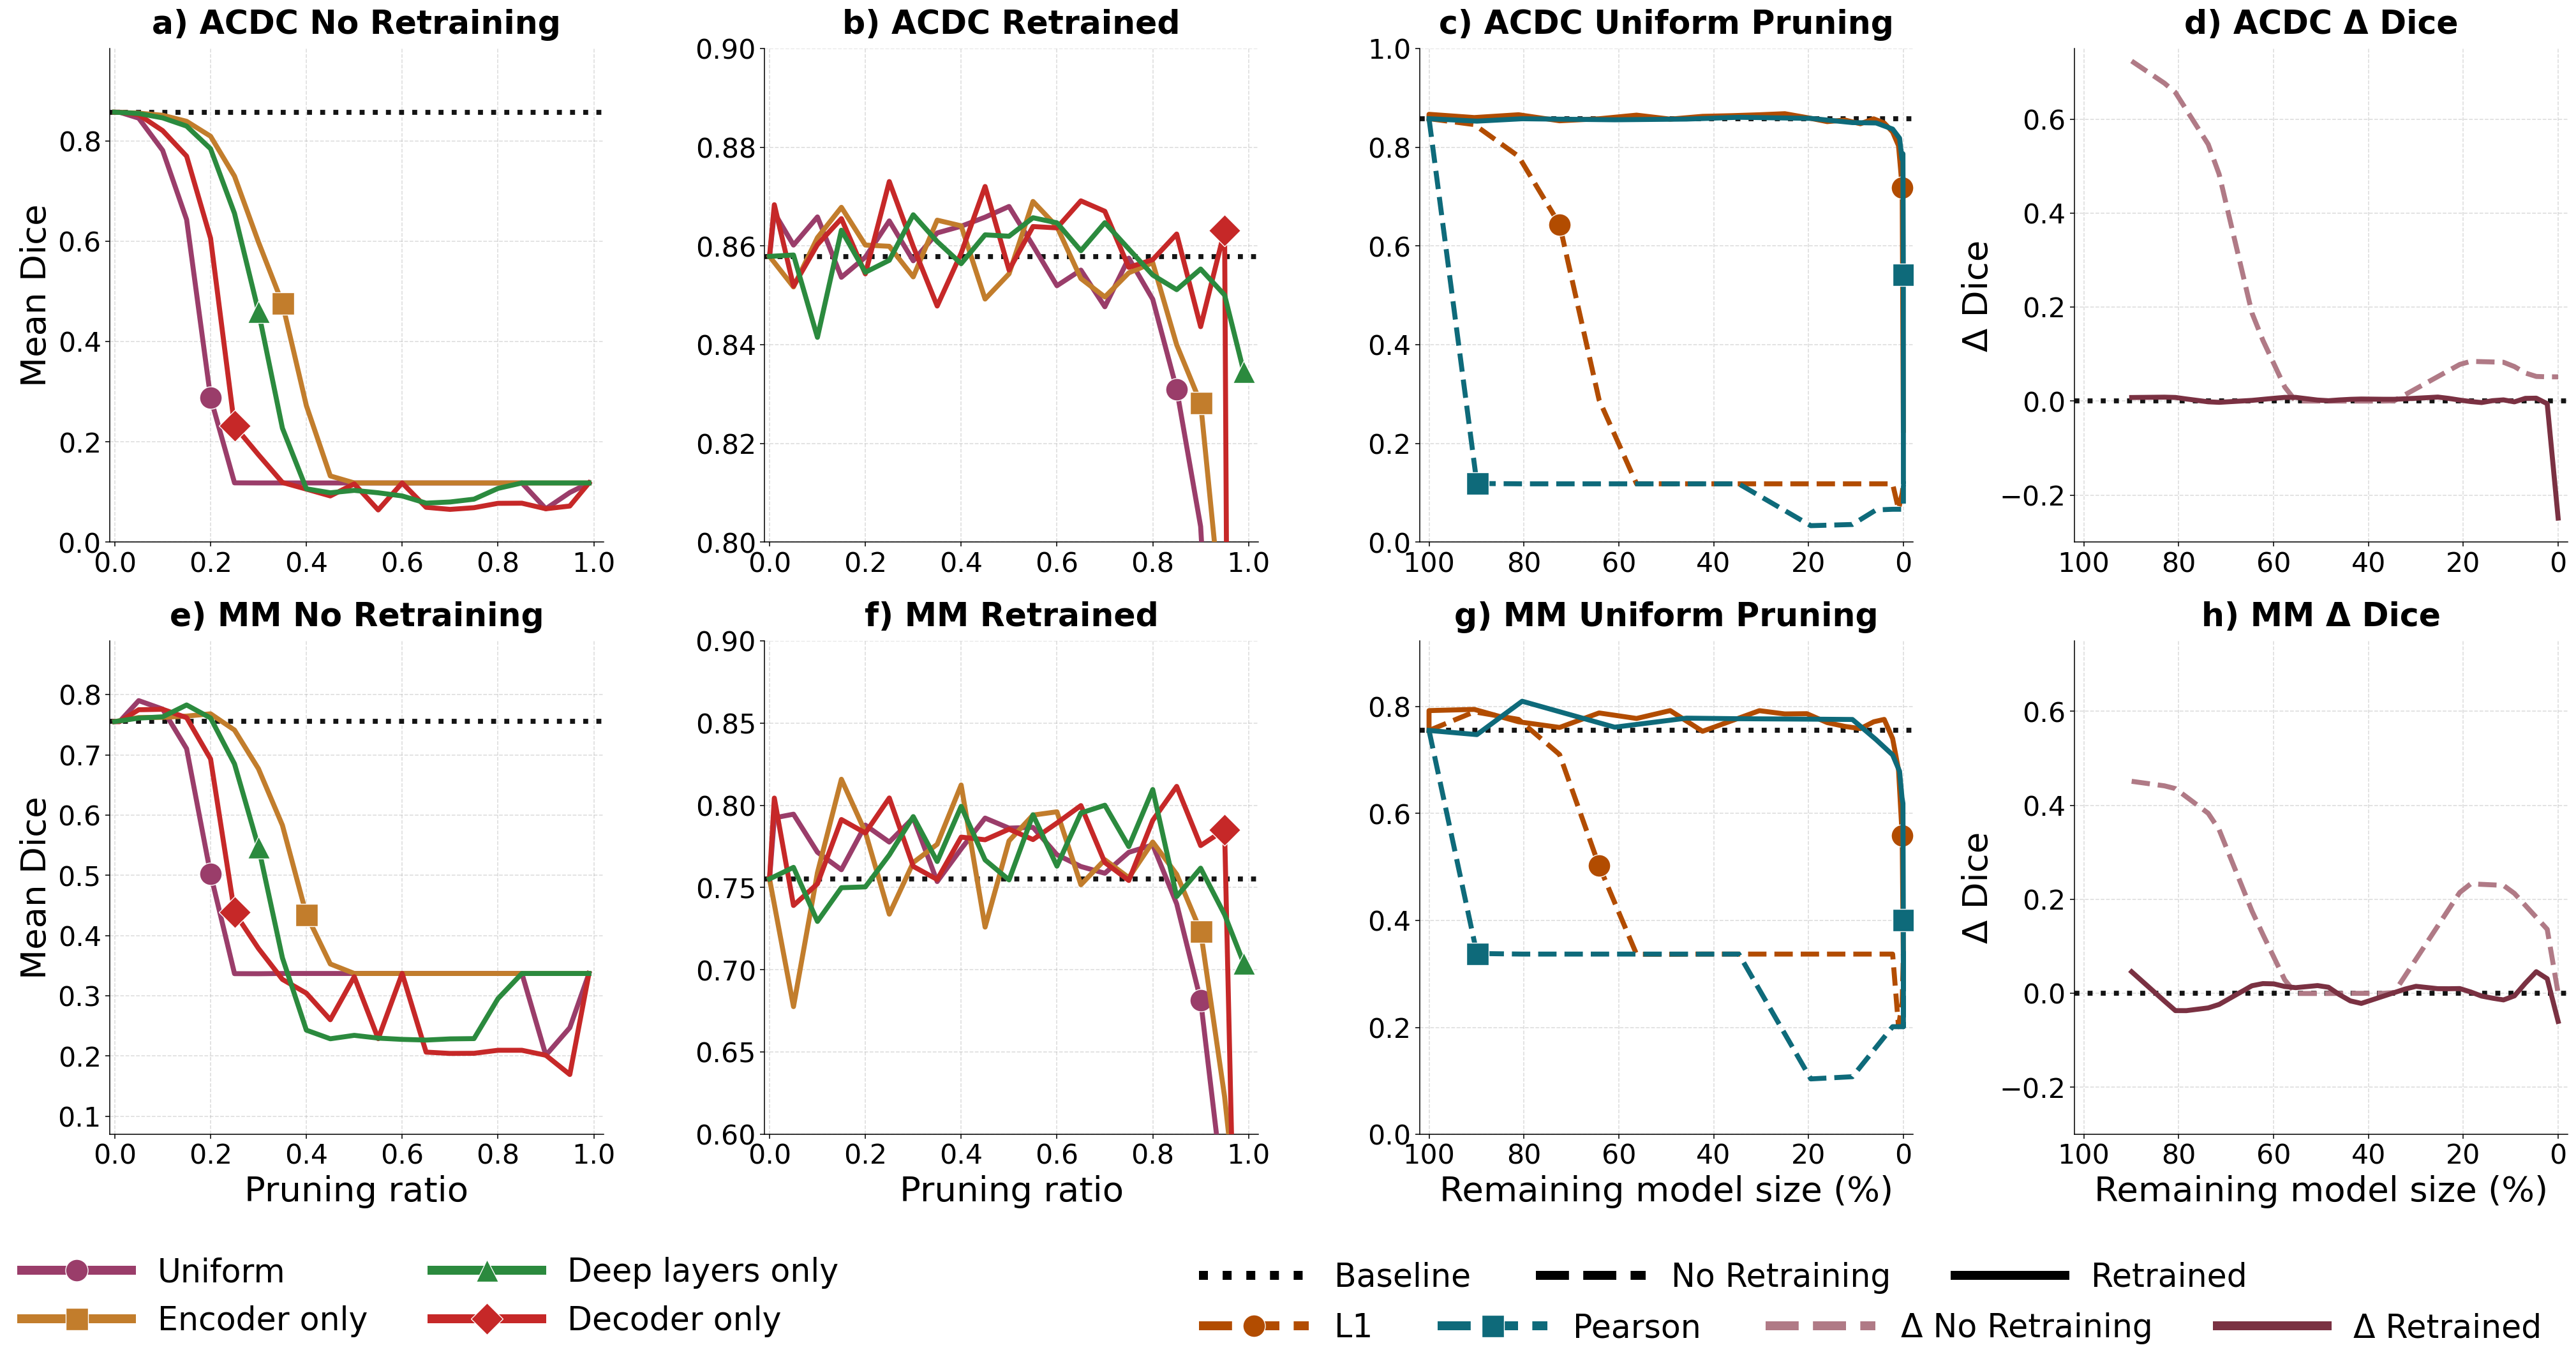

In [18]:
# Variant figure (keeps previous plot intact):
# - cols 1-2 share pruning-area colors
# - cols 3-4 use restrained grayscale method/delta colors
# - line style carries untrained vs retrained semantics where applicable
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

apply_publication_style()

LINE_W = 4.0

C_L1 = "#B24C00"
C_PEARSON = PUB_COLORS["l1"]
C_DELTA_U = "#B07A86"
C_DELTA_R = "#7A3142"


def _plot_uniform_distinct_on_ax(
    ax,
    dataset_key,
    *,
    include_baseline_point=True,
    title="",
    ylim=None,
    axis_fontsize=28,
    tick_fontsize=22,
):
    curves = [
        ("Untrained - L1", dfs_untrained[dataset_key]["l1"].uniform, C_L1, "--"),
        ("Untrained - Pearson", dfs_untrained[dataset_key]["corr"].uniform, C_PEARSON, "--"),
        ("Retrained - L1", dfs_trained[dataset_key]["l1"].uniform, C_L1, "-"),
        ("Retrained - Pearson", dfs_trained[dataset_key]["corr"].uniform, C_PEARSON, "-"),
    ]

    baseline_dice = float(dfs_untrained[dataset_key]["l1"].uniform.iloc[0]["mean_dice_fg"])
    ax.axhline(
        baseline_dice,
        linestyle=":",
        linewidth=LINE_W,
        color="black",
        alpha=0.92,
        label="Baseline (unpruned)",
    )

    y_vals = [baseline_dice]

    for label, df, color, ls in curves:
        if df is None or df.empty:
            continue

        if include_baseline_point:
            df_plot = df[["model_size_pct", "mean_dice_fg"]].copy()
        else:
            df_plot = df.iloc[1:][["model_size_pct", "mean_dice_fg"]].copy()

        df_plot = df_plot.sort_values("model_size_pct", ascending=False)
        if df_plot.empty:
            continue

        ax.plot(
            df_plot["model_size_pct"],
            df_plot["mean_dice_fg"],
            linewidth=LINE_W,
            linestyle=ls,
            color=color,
            label=label,
        )
        y_vals.extend(df_plot["mean_dice_fg"].astype(float).tolist())

    ax.set_xlim(102, -2)
    if ylim is None:
        y_min = min(y_vals)
        y_max = max(y_vals)
        y_span = (y_max - y_min) if y_max > y_min else 0.03
        y_pad = 0.16 * y_span
        ax.set_ylim(max(0.0, y_min - y_pad), min(1.0, y_max + y_pad))
    else:
        ax.set_ylim(*ylim)

    ax.set_title(title, fontsize=26, pad=12)
    ax.set_xlabel("Remaining model size (%)", fontsize=axis_fontsize)
    ax.set_ylabel("Mean Dice", fontsize=axis_fontsize)
    ax.tick_params(axis="both", labelsize=tick_fontsize)
    ax.set_box_aspect(1)
    despine(ax)


fig, axes = plt.subplots(2, 4, figsize=(36.0, 16.2), constrained_layout=False)

# Row 1: ACDC
_plot_methods_by_area_ratio_on_ax(
    axes[0, 0],
    dfs_untrained,
    "acdc",
    include_baseline_point=True,
    title="a) ACDC No Retraining",
    axis_fontsize=28,
)
_plot_methods_by_area_ratio_on_ax(
    axes[0, 1],
    dfs_trained,
    "acdc",
    include_baseline_point=True,
    title="b) ACDC Retrained",
    axis_fontsize=28,
)
_plot_uniform_distinct_on_ax(
    axes[0, 2],
    "acdc",
    include_baseline_point=True,
    title="c) ACDC Uniform Pruning",
)
_plot_aggregate_delta_on_ax(
    axes[0, 3],
    {"acdc": dfs_untrained["acdc"]},
    {"acdc": dfs_trained["acdc"]},
    include_baseline_point=False,
    n_grid=40,
    agg_stat="median",
    min_areas_required=1,
    title="d) ACDC Δ Dice",
    show_legend=False,
)

# Row 2: MM
_plot_methods_by_area_ratio_on_ax(
    axes[1, 0],
    dfs_untrained,
    "mm",
    include_baseline_point=True,
    title="e) MM No Retraining",
    axis_fontsize=28,
)
_plot_methods_by_area_ratio_on_ax(
    axes[1, 1],
    dfs_trained,
    "mm",
    include_baseline_point=True,
    title="f) MM Retrained",
    axis_fontsize=28,
)
_plot_uniform_distinct_on_ax(
    axes[1, 2],
    "mm",
    include_baseline_point=True,
    title="g) MM Uniform Pruning",
)
_plot_aggregate_delta_on_ax(
    axes[1, 3],
    {"acdc": dfs_untrained["mm"]},
    {"acdc": dfs_trained["mm"]},
    include_baseline_point=False,
    n_grid=40,
    agg_stat="median",
    min_areas_required=1,
    title="h) MM Δ Dice",
    show_legend=False,
)

# Per-panel label cleanup
for r in [0, 1]:
    axes[r, 1].set_ylabel("")
    axes[r, 3].set_ylabel("Δ Dice", fontsize=28)
    axes[r, 3].set_xlabel("Remaining model size (%)", fontsize=28)

for c in range(4):
    axes[0, c].set_xlabel("")

axes[0, 2].set_ylabel("")
axes[1, 2].set_ylabel("")

# Enforce consistent panel title size across all axes
for r in [0, 1]:
    for c in [0, 1, 2, 3]:
        axes[r, c].title.set_fontsize(26)

# Aggregate styling + unified thickness
common_delta_ylim = (-0.30, 0.75)
type(axes[0, 3]).set_ylim(axes[0, 3], *common_delta_ylim)
type(axes[1, 3]).set_ylim(axes[1, 3], *common_delta_ylim)
for r in [0, 1]:
    for line in axes[r, 3].lines:
        lbl = line.get_label()
        if "Baseline" in lbl:
            line.set_linestyle(":")
            line.set_color("black")
            line.set_linewidth(LINE_W)
        elif "Untrained" in lbl:
            line.set_color(C_DELTA_U)
            line.set_linestyle("--")
            line.set_linewidth(LINE_W)
        elif "Trained" in lbl:
            line.set_color(C_DELTA_R)
            line.set_linestyle("-")
            line.set_linewidth(LINE_W)
        else:
            line.set_linewidth(LINE_W)

# Ratio columns: keep same color mapping across col 1 and 2, unify line thickness
marker_map = {
    "Uniform": "o",
    "Encoder only": "s",
    "Deep layers only": "^",
    "Decoder only": "D",
}
uniform_marker_map = {
    "Untrained - L1": "o",
    "Untrained - Pearson": "s",
    "Retrained - L1": "o",
    "Retrained - Pearson": "s",
}
marker_target = {
    (0, 0): 0.40,
    (1, 0): 0.50,
    (0, 2): 0.50,
    (1, 2): 0.50,
}
for r in [0, 1]:
    for c in [0, 1, 2]:
        for line in axes[r, c].lines:
            if line.get_label() == "Uniform":
                line.set_color(PUB_COLORS["corr"])
            if c == 2 and line.get_label() in uniform_marker_map:
                x = np.asarray(line.get_xdata(), dtype=float)
                y = np.asarray(line.get_ydata(), dtype=float)
                idx = int(np.nanargmin(np.abs(y - marker_target[(r, c)])))
                if (r, c) == (0, 2) and line.get_label() == "Untrained - Pearson":
                    idx = min(len(x) - 1, idx + 1)
                line.set_marker(uniform_marker_map[line.get_label()])
                line.set_markevery([idx])
                line.set_markersize(18)
                line.set_markeredgecolor("white")
                line.set_markeredgewidth(0.7)
            elif line.get_label() in marker_map:
                x = np.asarray(line.get_xdata(), dtype=float)
                y = np.asarray(line.get_ydata(), dtype=float)
                if c == 1:
                    valid_idx = np.where((x >= 0.8) & (y > 0.6))[0]
                    idx_pool = valid_idx if valid_idx.size else np.where(y > 0.6)[0]
                    if idx_pool.size:
                        idx = int(idx_pool[np.nanargmax(x[idx_pool])])
                    else:
                        idx = int(np.nanargmax(x))
                    if (r, c) == (0, 1) and line.get_label() == "Uniform":
                        idx = max(0, idx - 2)
                    if (r, c) == (0, 1) and line.get_label() == "Encoder only":
                        idx = max(0, idx - 2)
                    if (r, c) == (1, 1) and line.get_label() == "Encoder only":
                        idx = max(0, idx - 1)
                else:
                    idx = int(np.nanargmin(np.abs(y - marker_target[(r, c)])))
                line.set_marker(marker_map[line.get_label()])
                line.set_markevery([idx])
                line.set_markersize(18)
                line.set_markeredgecolor("white")
                line.set_markeredgewidth(0.7)
            line.set_linewidth(LINE_W)

# Second column y-limits
axes[0, 1].set_ylim(0.8, 0.9)
axes[1, 1].set_ylim(0.6, 0.9)

# Legend 1: pruning-area colors for ratio panels
legend_area = [
    Line2D([0], [0], color=PUB_COLORS["corr"], linestyle="-", linewidth=7.2, marker="o", markersize=18, markeredgecolor="white", markeredgewidth=0.7, label="Uniform"),
    Line2D([0], [0], color=PUB_COLORS["neutral"], linestyle="-", linewidth=7.2, marker="s", markersize=18, markeredgecolor="white", markeredgewidth=0.7, label="Encoder only"),
    Line2D([0], [0], color=PUB_COLORS["good"], linestyle="-", linewidth=7.2, marker="^", markersize=18, markeredgecolor="white", markeredgewidth=0.7, label="Deep layers only"),
    Line2D([0], [0], color=PUB_COLORS["warn"], linestyle="-", linewidth=7.2, marker="D", markersize=18, markeredgecolor="white", markeredgewidth=0.7, label="Decoder only"),
]
fig.legend(
    handles=legend_area,
    loc="lower center",
    bbox_to_anchor=(0.23, -0.03),
    ncol=2,
    frameon=False,
    fontsize=26,
    handlelength=3.4,
)

# Legend 2: line-style semantics for cols 3+4
legend_style = [
    Line2D([0], [0], color="black", linestyle=":", linewidth=7.2, label="Baseline"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=7.2, label="No Retraining"),
    Line2D([0], [0], color="black", linestyle="-", linewidth=7.2, label="Retrained"),
]
fig.legend(
    handles=legend_style,
    loc="lower left",
    bbox_to_anchor=(0.46, 0.00),
    ncol=3,
    frameon=False,
    fontsize=26,
    handlelength=3.4,
)

# Legend 3: color semantics for cols 3+4
legend_color = [
    Line2D([0], [0], color=C_L1, linestyle="--", linewidth=7.2, marker="o", markersize=18, markeredgecolor="white", markeredgewidth=0.7, label="L1"),
    Line2D([0], [0], color=C_PEARSON, linestyle="--", linewidth=7.2, marker="s", markersize=18, markeredgecolor="white", markeredgewidth=0.7, label="Pearson"),
    Line2D([0], [0], color=C_DELTA_U, linestyle="--", linewidth=7.2, label="Δ No Retraining"),
    Line2D([0], [0], color=C_DELTA_R, linestyle="-", linewidth=7.2, label="Δ Retrained"),
]
fig.legend(
    handles=legend_color,
    loc="lower left",
    bbox_to_anchor=(0.46, -0.035),
    ncol=4,
    frameon=False,
    fontsize=26,
    handlelength=3.4,
)

fig.subplots_adjust(wspace=0.24, hspace=0.20, bottom=0.13)
plt.show()



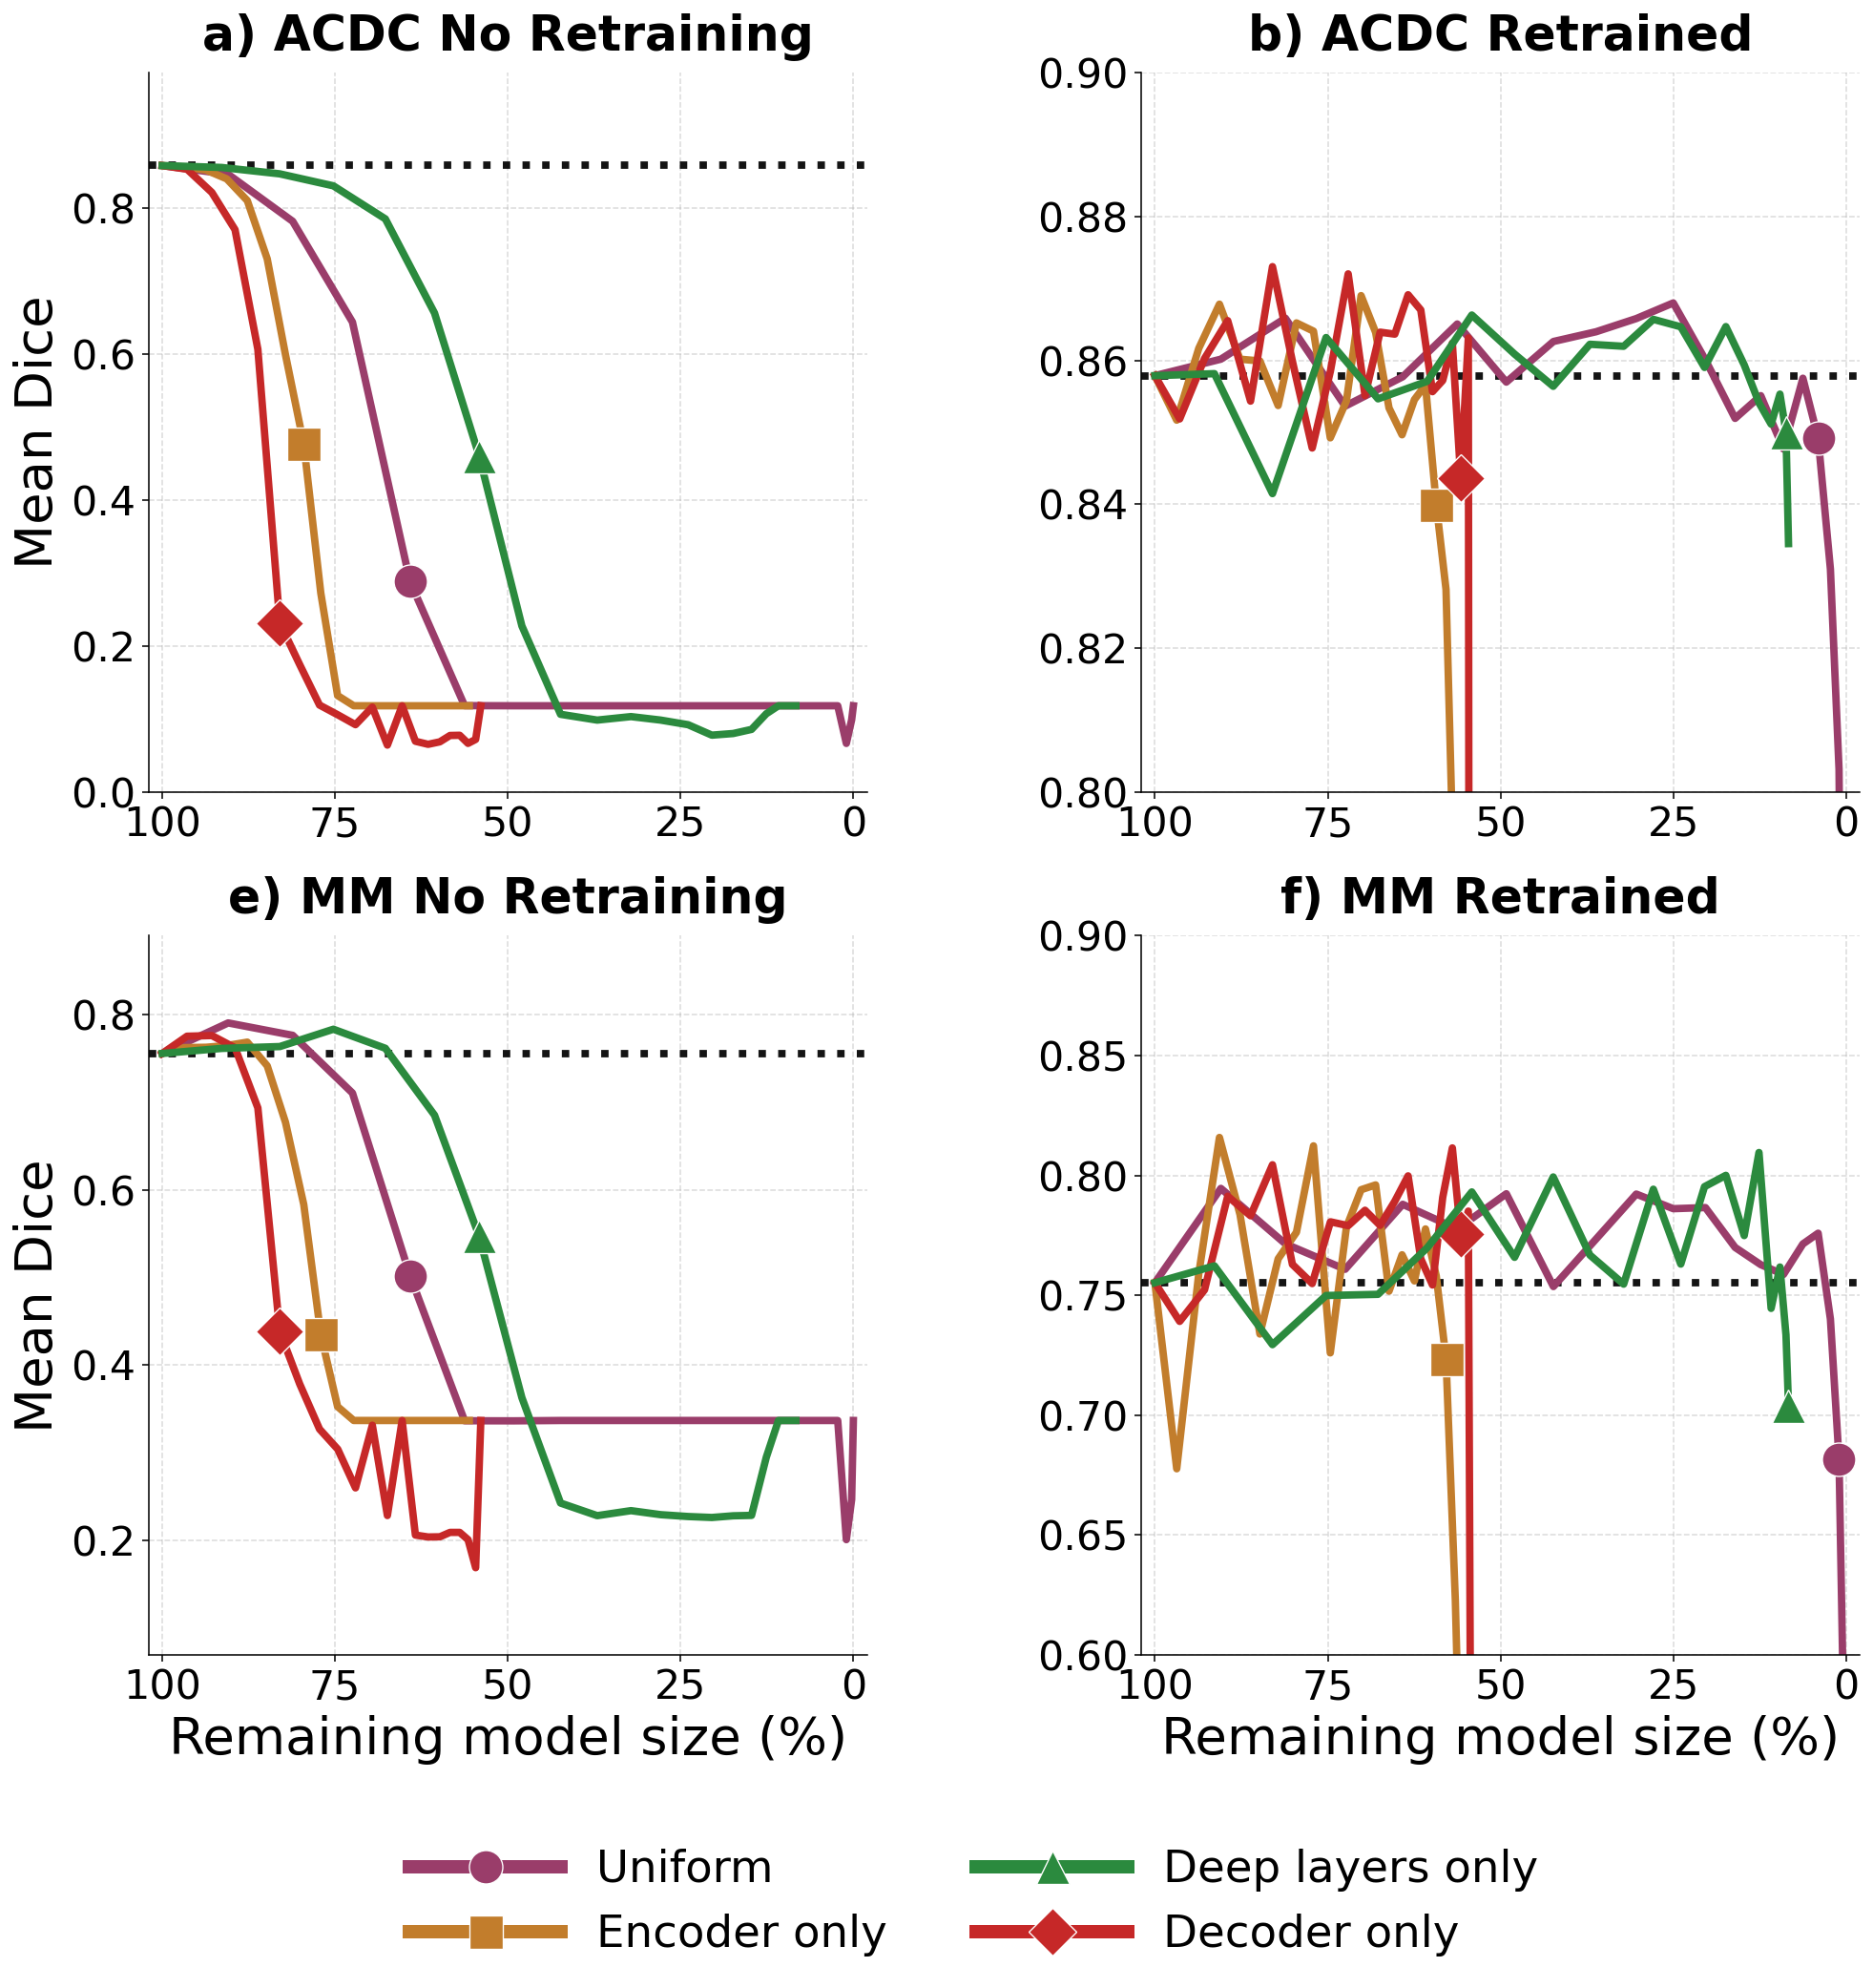

In [19]:
# Panels a, b, e, f with remaining model size on the x-axis
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

apply_publication_style()

AREA_COLORS = {
    "uniform": PUB_COLORS["corr"],
    "encoder": PUB_COLORS["neutral"],
    "deep": PUB_COLORS["good"],
    "decoder": PUB_COLORS["warn"],
}
AREA_LABELS = {
    "uniform": "Uniform",
    "encoder": "Encoder only",
    "deep": "Deep layers only",
    "decoder": "Decoder only",
}
AREA_MARKERS = {
    "uniform": "o",
    "encoder": "s",
    "deep": "^",
    "decoder": "D",
}

def _plot_l1_area_by_model_size(ax, dfs_obj, dataset_key, title, ylim=None):
    group = dfs_obj[dataset_key]["l1"]
    baseline_dice = float(group.uniform.iloc[0]["mean_dice_fg"])
    ax.axhline(baseline_dice, linestyle=":", linewidth=4.0, color="black", alpha=0.92)

    y_vals = [baseline_dice]
    for area in ["uniform", "encoder", "decoder", "deep"]:
        df = getattr(group, area)
        if df is None or df.empty:
            continue

        df_plot = df[["model_size_pct", "mean_dice_fg"]].copy()
        df_plot = df_plot.dropna(subset=["model_size_pct", "mean_dice_fg"])
        df_plot = df_plot.sort_values("model_size_pct", ascending=False)
        df_plot = df_plot.drop_duplicates(subset=["model_size_pct"], keep="first")
        if df_plot.empty:
            continue

        line, = ax.plot(
            df_plot["model_size_pct"],
            df_plot["mean_dice_fg"],
            color=AREA_COLORS[area],
            linestyle="-",
            linewidth=4.0,
            label=AREA_LABELS[area],
        )

        # One reference marker per curve, similar to the pruning-ratio panels.
        x = df_plot["model_size_pct"].to_numpy(float)
        y = df_plot["mean_dice_fg"].to_numpy(float)
        target = 0.84 if dataset_key == "acdc" and dfs_obj is dfs_trained else 0.71 if dataset_key == "mm" and dfs_obj is dfs_trained else 0.40 if dataset_key == "acdc" else 0.50
        idx = int(np.nanargmin(np.abs(y - target)))
        if dataset_key == "acdc" and dfs_obj is dfs_trained and area == "deep":
            idx = max(0, len(x) - 2)
        if dataset_key == "acdc" and dfs_obj is dfs_trained and area == "uniform":
            idx = min(len(x) - 1, idx + 2)
        if dataset_key == "mm" and dfs_obj is dfs_trained and area == "decoder":
            idx = max(0, len(x) - 3)
        line.set_marker(AREA_MARKERS[area])
        line.set_markevery([idx])
        line.set_markersize(18)
        line.set_markeredgecolor("white")
        line.set_markeredgewidth(0.7)
        y_vals.extend(y.tolist())

    ax.set_xlim(102, -2)
    if ylim is None:
        y_min = min(y_vals)
        y_max = max(y_vals)
        y_span = (y_max - y_min) if y_max > y_min else 0.03
        y_pad = 0.16 * y_span
        ax.set_ylim(max(0.0, y_min - y_pad), min(1.0, y_max + y_pad))
    else:
        ax.set_ylim(*ylim)

    ax.set_title(title, fontsize=26, pad=12)
    ax.set_xlabel("Remaining model size (%)", fontsize=28)
    ax.set_ylabel("Mean Dice", fontsize=28)
    ax.tick_params(axis="both", labelsize=22)
    ax.set_box_aspect(1)
    despine(ax)


fig, axes = plt.subplots(2, 2, figsize=(18.0, 16.0), constrained_layout=False)

_plot_l1_area_by_model_size(axes[0, 0], dfs_untrained, "acdc", "a) ACDC No Retraining")
_plot_l1_area_by_model_size(axes[0, 1], dfs_trained, "acdc", "b) ACDC Retrained", ylim=(0.80, 0.90))
_plot_l1_area_by_model_size(axes[1, 0], dfs_untrained, "mm", "e) MM No Retraining")
_plot_l1_area_by_model_size(axes[1, 1], dfs_trained, "mm", "f) MM Retrained", ylim=(0.60, 0.90))

axes[0, 1].set_ylabel("")
axes[1, 1].set_ylabel("")
axes[0, 0].set_xlabel("")
axes[0, 1].set_xlabel("")

legend_area = [
    Line2D([0], [0], color=AREA_COLORS["uniform"], linestyle="-", linewidth=7.2, marker="o", markersize=18, markeredgecolor="white", markeredgewidth=0.7, label="Uniform"),
    Line2D([0], [0], color=AREA_COLORS["encoder"], linestyle="-", linewidth=7.2, marker="s", markersize=18, markeredgecolor="white", markeredgewidth=0.7, label="Encoder only"),
    Line2D([0], [0], color=AREA_COLORS["deep"], linestyle="-", linewidth=7.2, marker="^", markersize=18, markeredgecolor="white", markeredgewidth=0.7, label="Deep layers only"),
    Line2D([0], [0], color=AREA_COLORS["decoder"], linestyle="-", linewidth=7.2, marker="D", markersize=18, markeredgecolor="white", markeredgewidth=0.7, label="Decoder only"),
]
fig.legend(
    handles=legend_area,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    frameon=False,
    fontsize=24,
    handlelength=3.4,
)

fig.subplots_adjust(wspace=0.14, hspace=0.20, bottom=0.14)
plt.show()


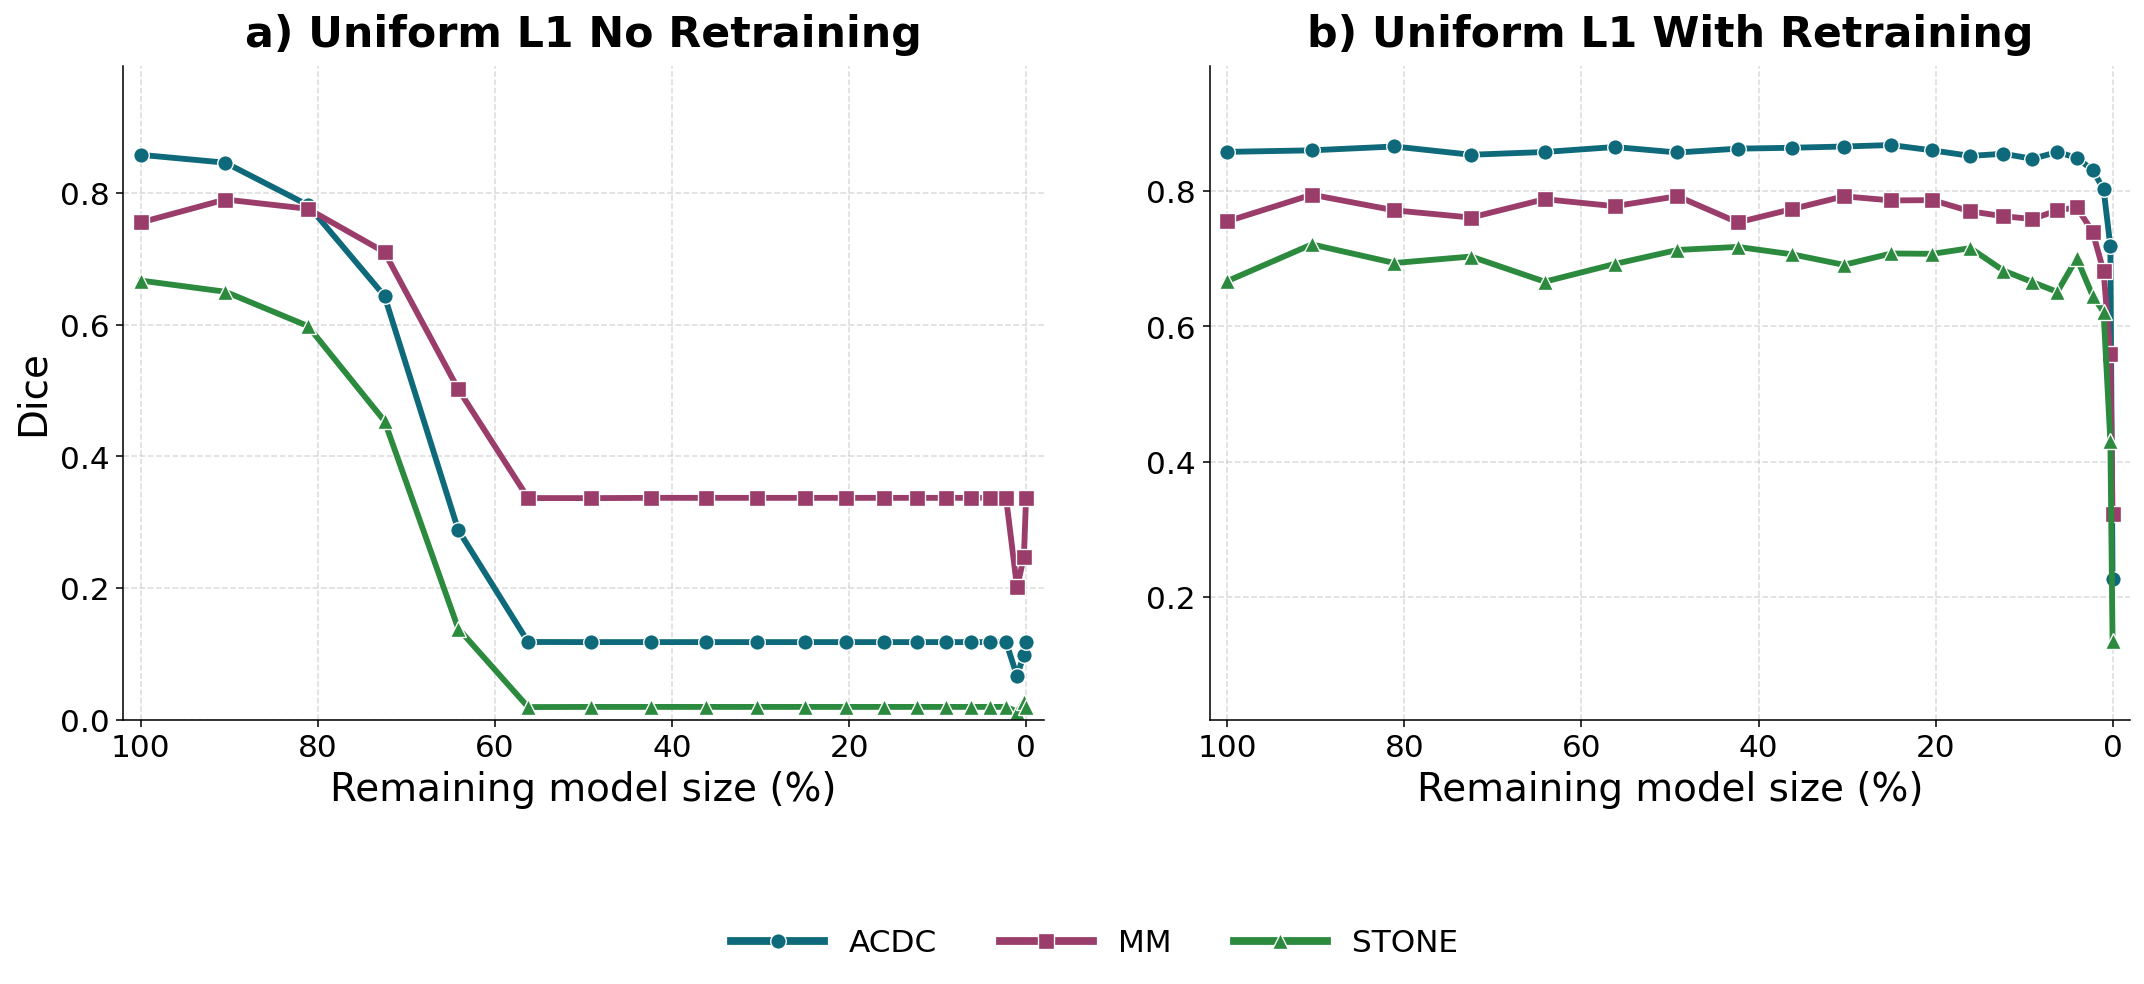

In [23]:
# STONE vs ACDC vs MM: Uniform L1 only (No retraining vs With retraining)
import matplotlib.pyplot as plt

apply_publication_style()


def _plot_uniform_l1_three_datasets(ax, *, trained=False, title="", ylim=None):
    dfs_obj = dfs_trained if trained else dfs_untrained

    series = [
        ("ACDC", dfs_obj["acdc"]["l1"].uniform, PUB_COLORS["l1"], "o"),
        ("MM", dfs_obj["mm"]["l1"].uniform, PUB_COLORS["corr"], "s"),
        ("STONE", dfs_obj["stone"]["l1"].uniform, PUB_COLORS["good"], "^"),
    ]

    y_vals = []
    for label, df, color, marker in series:
        if df is None or df.empty:
            continue

        df_plot = df.copy()
        if label == "STONE" and "run_name" in df_plot.columns:
            pruned_only = df_plot[df_plot["run_name"] != "baseline"].copy()
            if not pruned_only.empty:
                df_plot = pruned_only

        df_plot = df_plot[["model_size_pct", "mean_dice_fg"]].copy()
        df_plot = df_plot.dropna(subset=["model_size_pct", "mean_dice_fg"])
        df_plot = df_plot.sort_values("model_size_pct", ascending=False)
        df_plot = df_plot.drop_duplicates(subset=["model_size_pct"], keep="first")
        if df_plot.empty:
            continue

        # Hardcoded correction requested: for STONE retrained, force first point
        # to match first point from STONE no-retraining curve.
        if label == "STONE" and trained:
            ref_df = dfs_untrained["stone"]["l1"].uniform.copy()
            if "run_name" in ref_df.columns:
                ref_df = ref_df[ref_df["run_name"] != "baseline"].copy()
            ref_df = ref_df[["model_size_pct", "mean_dice_fg"]].dropna()
            ref_df = ref_df.sort_values("model_size_pct", ascending=False)
            ref_df = ref_df.drop_duplicates(subset=["model_size_pct"], keep="first")
            if not ref_df.empty:
                df_plot.loc[df_plot.index[0], "mean_dice_fg"] = float(ref_df.iloc[0]["mean_dice_fg"])

        ax.plot(
            df_plot["model_size_pct"],
            df_plot["mean_dice_fg"],
            color=color,
            linestyle="-",
            linewidth=3.0,
            marker=marker,
            markersize=8,
            markeredgecolor="white",
            markeredgewidth=0.7,
            label=label,
        )
        y_vals.extend(df_plot["mean_dice_fg"].astype(float).tolist())

    ax.set_xlim(102, -2)
    if ylim is None and y_vals:
        y_min, y_max = min(y_vals), max(y_vals)
        y_span = (y_max - y_min) if y_max > y_min else 0.03
        y_pad = 0.16 * y_span
        ax.set_ylim(max(0.0, y_min - y_pad), min(1.0, y_max + y_pad))
    elif ylim is not None:
        ax.set_ylim(*ylim)

    ax.set_title(title, fontsize=22, pad=10)
    ax.set_xlabel("Remaining model size (%)", fontsize=20)
    ax.set_ylabel("Dice", fontsize=20)
    ax.tick_params(axis="both", labelsize=16)
    despine(ax)


fig, axes = plt.subplots(1, 2, figsize=(18.5, 7.3), constrained_layout=False)

_plot_uniform_l1_three_datasets(
    axes[0],
    trained=False,
    title="a) Uniform L1 No Retraining",
)

_plot_uniform_l1_three_datasets(
    axes[1],
    trained=True,
    title="b) Uniform L1 With Retraining",
)
axes[1].set_ylabel("")

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    leg = fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=3,
        frameon=False,
        fontsize=16,
        handlelength=3.0,
    )
    for h in leg.get_lines():
        h.set_linewidth(4.0)

fig.subplots_adjust(wspace=0.18, bottom=0.24)
plt.show()
